In [1]:
import torch
import pandas as pd
import numpy as np
from functools import partial
import requests
import pywt
from scipy import signal
import time
from statsmodels.tsa.stattools import adfuller
import statsmodels.api as sm
import math
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection._split import _BaseKFold
from sklearn.metrics import accuracy_score
from multiprocessing import cpu_count, Pool
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

# Print out the current version of PyTorch installed
print("PyTorch version:", torch.__version__)

# This line verifies whether a GPU is accessible for computations
print("GPU available via `torch.cuda.is_available()`:", torch.cuda.is_available())

# If a GPU is detected, report the number of GPUs and identify the first GPU device by name
if torch.cuda.is_available():
    print("Number of detected GPUs:", torch.cuda.device_count())
    print("GPU 0 Name:", torch.cuda.get_device_name(0))
else:
    # Otherwise, report that no GPU is available in the current environment
    print("No GPU detected.")

PyTorch version: 2.2.2+rocm5.6
GPU available via `torch.cuda.is_available()`: True
Number of detected GPUs: 1
GPU 0 Name: AMD Radeon RX 6800 XT


In [2]:
"""
This module provides functions to retrieve historical market data from both Binance and Yahoo Finance.
It is particularly useful for conducting quantitative analysis of digital assets and traditional stocks.
The module aims to handle pagination seamlessly when fetching large datasets, ensuring that advanced
financial engineering techniques can be applied to high-fidelity time-series data.
"""

def _fetch_binance_klines_backward(symbol, interval, max_bars):
    """
    Fetches historical kline (candlestick) data from Binance by moving backward in time.
    
    Args:
        symbol (str): The trading pair to retrieve data for (e.g., "BTCUSDT").
        interval (str): The frequency of the klines (e.g., '1d', '1h').
        max_bars (int): The maximum number of data points (candlesticks) to fetch.
    
    Returns:
        pd.DataFrame: A DataFrame containing the retrieved kline data. Columns include Open, High,
                      Low, Close, and Volume, indexed by Open Time.
    """
    end_ms = int(time.time() * 1000)  # Sets the initial ending timestamp to the current time in milliseconds
    all_chunks = []
    total_fetched = 0

    # Continue fetching data until we have reached the desired max_bars
    while total_fetched < max_bars:
        batch_size = min(1000, max_bars - total_fetched)
        params = {
            "symbol": symbol,
            "interval": interval,
            "limit": batch_size,
            "endTime": end_ms
        }
        url = "https://api.binance.com/api/v3/klines"
        resp = requests.get(url, params=params)
        resp.raise_for_status()  # Raises HTTPError if the response code was unsuccessful
        data = resp.json()

        # If no more data is available, exit the loop
        if not data:
            break

        df_temp = pd.DataFrame(data, columns=[
            'Open Time','Open','High','Low','Close','Volume',
            'Close Time','Quote Asset Volume','Trades',
            'Taker buy base','Taker buy quote','Ignore'
        ])

        # Convert numeric columns for accurate calculations
        df_temp[['Open','High','Low','Close','Volume']] = df_temp[['Open','High','Low','Close','Volume']].astype(float)
        n = len(df_temp)
        if n == 0:
            break

        # Convert timestamps into readable datetime format for further analysis
        df_temp['Open Time'] = pd.to_datetime(df_temp['Open Time'], unit='ms')
        df_temp['Close Time'] = pd.to_datetime(df_temp['Close Time'], unit='ms')
        all_chunks.append(df_temp)
        total_fetched += n

        # Calculate the earliest opening time to set the new ending timestamp for next iteration
        earliest_open = df_temp['Open Time'].iloc[0]
        new_end_ms = int(earliest_open.timestamp() * 1000) - 1

        # If the new end time is either before epoch or not earlier than the current end time, stop
        if new_end_ms < 0 or new_end_ms >= end_ms:
            break
        end_ms = new_end_ms

    # If no data was appended, return an empty DataFrame with the expected columns
    if not all_chunks:
        return pd.DataFrame(columns=['Open','High','Low','Close','Volume'])

    # Concatenate all collected data chunks, remove duplicates, and sort by chronological order
    df_all = pd.concat(all_chunks, ignore_index=True)
    df_all.drop_duplicates(subset=['Open Time'], inplace=True)
    df_all.sort_values(by='Open Time', inplace=True)

    # Retain only relevant columns, set the index to 'Open Time' for easy time-series operations
    df_all = df_all[['Open Time','Open','High','Low','Close','Volume']]
    df_all.set_index('Open Time', inplace=True)
    df_all.index.name = 'Date'
    return df_all

def _fetch_binance_klines_forward(symbol, interval, start_time, end_time, max_bars):
    """
    Fetches historical kline (candlestick) data from Binance by moving forward in time.
    
    Args:
        symbol (str): The trading pair for which data is fetched (e.g., "ETHUSDT").
        interval (str): Kline frequency (e.g., '1d', '1h').
        start_time (int): The initial starting timestamp in milliseconds.
        end_time (int): The final timestamp in milliseconds. Defaults to current time if None.
        max_bars (int): The maximum total data points (candlesticks) to obtain.
    
    Returns:
        pd.DataFrame: A chronologically indexed DataFrame containing the kline data. 
                      The columns are Open, High, Low, Close, and Volume.
    """
    if end_time is None:
        end_time = int(time.time() * 1000)
    url = "https://api.binance.com/api/v3/klines"
    all_frames = []
    total_fetched = 0
    current_start = start_time

    while True:
        batch_size = min(1000, max_bars - total_fetched)
        if batch_size <= 0:
            break
        params = {
            "symbol": symbol,
            "interval": interval,
            "limit": batch_size,
            "startTime": current_start,
            "endTime": end_time
        }
        resp = requests.get(url, params=params)
        resp.raise_for_status()
        data = resp.json()

        # Break out if Binance returns no further data
        if not data:
            break

        df_temp = pd.DataFrame(data, columns=[
            'Open Time','Open','High','Low','Close','Volume',
            'Close Time','Quote Asset Volume','Trades',
            'Taker buy base','Taker buy quote','Ignore'
        ])

        # Convert data columns to float for compatibility with financial calculations
        df_temp[['Open','High','Low','Close','Volume']] = df_temp[['Open','High','Low','Close','Volume']].astype(float)
        count_this = len(df_temp)
        if count_this == 0:
            break
        total_fetched += count_this

        # Convert timestamps for better readability and time-based analysis
        df_temp['Open Time'] = pd.to_datetime(df_temp['Open Time'], unit='ms')
        df_temp['Close Time'] = pd.to_datetime(df_temp['Close Time'], unit='ms')
        all_frames.append(df_temp)

        # Move the starting point for the next batch just beyond the last close time
        last_close_ms = int(df_temp['Close Time'].iloc[-1].timestamp() * 1000)
        current_start = last_close_ms + 1

        # Stop if we've reached or exceeded the user-specified end time
        if current_start > end_time:
            break

        # If the returned data is smaller than the requested batch size, we've likely reached the end
        if count_this < batch_size:
            break

    if not all_frames:
        return pd.DataFrame(columns=['Open','High','Low','Close','Volume'])

    # Combine all frames, remove duplicates, ensure chronological order
    df_all = pd.concat(all_frames, ignore_index=True)
    df_all.drop_duplicates(subset=['Open Time'], inplace=True)
    df_all.sort_values(by='Open Time', inplace=True)

    # Keep the main columns, set the index to 'Open Time'
    df_all = df_all[['Open Time','Open','High','Low','Close','Volume']]
    df_all.set_index('Open Time', inplace=True)
    df_all.index.name = 'Date'
    return df_all

def fetch_binance_klines_paginated(symbol, interval='1d', start_time=None, end_time=None, max_bars=10000):
    """
    Retrieves large batches of kline data from Binance by internally calling backward or forward
    fetching functions. If a start_time is given, it will fetch forward; otherwise, it will
    fetch backward from the current time.
    
    Args:
        symbol (str): The digital asset pair (e.g., "BTCUSDT").
        interval (str): The candlestick interval (e.g., '1d', '1h').
        start_time (int, optional): Start timestamp in milliseconds. Defaults to None.
        end_time (int, optional): End timestamp in milliseconds. Defaults to None.
        max_bars (int): Maximum number of data points to retrieve, capped at 10000 by default.
    
    Returns:
        pd.DataFrame: A concatenated DataFrame of all fetched klines with date-based index.
    """
    if start_time is None:
        return _fetch_binance_klines_backward(symbol, interval, max_bars)
    else:
        return _fetch_binance_klines_forward(symbol, interval, start_time, end_time, max_bars)

try:
    import yfinance as yf
except ImportError:
    yf = None

def fetch_data(symbol, interval='1d', source='binance', start_time=None, end_time=None, max_bars=10000):
    """
    Fetches historical data from either Binance or Yahoo Finance. 
    Supports single symbols or lists of symbols, enabling retrieval of multiple datasets at once.
    
    Args:
        symbol (str or list): Symbol(s) for data retrieval, e.g., 'BTCUSDT' or ['BTCUSDT','ETHUSDT'].
        interval (str): Interval for candlesticks or data frequency, e.g. '1d' or '1h'.
        source (str): Data source, either 'binance' or 'yahoo'.
        start_time (int, optional): Start timestamp in milliseconds (used for Binance).
        end_time (int, optional): End timestamp in milliseconds (used for Binance).
        max_bars (int): Maximum number of data points to fetch.
    
    Returns:
        pd.DataFrame or dict: Returns a single DataFrame if symbol is a string, or a dictionary of 
        DataFrames if multiple symbols are provided.
    """
    # If multiple symbols are passed, recursively fetch each symbol's data
    if isinstance(symbol, (list, tuple)):
        data_dict = {}
        for sym in symbol:
            data_dict[sym] = fetch_data(sym, interval=interval, source=source, start_time=start_time, end_time=end_time, max_bars=max_bars)
        return data_dict

    # Fetch data from the user-specified source
    if source == 'binance':
        df = fetch_binance_klines_paginated(symbol=symbol, interval=interval, start_time=start_time, end_time=end_time, max_bars=max_bars)
        return df
    elif source == 'yahoo':
        if yf is None:
            raise ImportError("yfinance not installed. Please install it to use Yahoo data source.")
        yahoo_symbol = symbol

        # For crypto pairs, Yahoo often uses the '-USD' suffix for pricing data
        if symbol.endswith('USDT'):
            yahoo_symbol = symbol.replace('USDT', '-USD')

        # If frequency is intraday, limit historical period to avoid API limitations
        if any(interval.endswith(x) for x in ['m','h']):
            period = "60d"
        else:
            period = "max"

        df = yf.download(tickers=yahoo_symbol, period=period, interval=interval)
        if df.empty:
            raise ValueError(f"No data returned from Yahoo for {yahoo_symbol}, interval={interval}")

        # Standardize columns and use Date as the index for consistency
        df = df.rename(columns={'Open': 'Open','High': 'High','Low': 'Low','Close': 'Close','Volume': 'Volume'})
        df.index.name = 'Date'
        df = df[['Open','High','Low','Close','Volume']]
        return df
    else:
        raise ValueError("source must be 'binance' or 'yahoo'.")


In [3]:
# -----------------------------------------------------------------------------------
# Cell 2.5 // Dukascopy data fetcher (Tick-level) -- FIXED to use `from datetime import datetime, timedelta`
# -----------------------------------------------------------------------------------
import calendar
from datetime import datetime, timedelta
import requests
import struct
import pandas as pd
import numpy as np

def _dukascopy_instrument_map(symbol):
    """
    Maps a user-friendly symbol (e.g. 'US30', 'US100', 'XAUUSD') to
    Dukascopy's instrument name used in their data endpoints.
    
    For example:
      - 'US30' => 'US30.IDX/USD'
      - 'US100' => 'NAS100.IDX/USD'
      - 'US500' => 'US500.IDX/USD'
      - 'XAUUSD' => 'XAUUSD' (or 'GOLD', etc.)
    
    Adjust or add more mappings as needed.
    """
    symbol_upper = symbol.upper()
    if symbol_upper in ['US30', 'DJI', 'DOW']:
        return 'US30.IDX/USD'
    elif symbol_upper in ['US100', 'NAS100']:
        return 'NAS100.IDX/USD'
    elif symbol_upper in ['US500', 'SPX500', 'SP500']:
        return 'US500.IDX/USD'
    elif symbol_upper in ['GOLD', 'XAUUSD']:
        return 'XAUUSD'
    else:
        # fallback: assume user passed the correct Dukascopy instrument name
        return symbol

def _download_dukascopy_hour(instrument, year, month, day, hour):
    """
    Download raw compressed file for one hour of tick data from Dukascopy servers
    and return as bytes. If not found or error, return None.
    """
    # Construct the Dukascopy path. The server stores data in a hierarchical structure:
    #   https://datafeed.dukascopy.com/datafeed/<instrument>/<YYYY>/<MM>/<DD>/<HH>h_ticks.bi5
    # For example:
    #   instrument = "US30.IDX%2FUSD"
    #   year=2023, month=3, day=1, hour=0 => 
    #        https://datafeed.dukascopy.com/datafeed/US30.IDX%2FUSD/2023/02/01/0h_ticks.bi5
    # Note: month in the URL is zero-based (0=January,...,11=December)
    # instrument must be URL-encoded where special chars become e.g. `%2F`.
    
    # Zero-based month in path
    mm_in_path = month - 1  
    # Dukascopy uses instrument with slash replaced by '%2F'
    inst_encoded = instrument.replace('/', '%2F')
    url = (
        f"https://datafeed.dukascopy.com/datafeed/{inst_encoded}/"
        f"{year}/{mm_in_path:02d}/{day:02d}/{hour}h_ticks.bi5"
    )
    try:
        resp = requests.get(url, timeout=30)
        if resp.status_code == 200 and resp.content:
            return resp.content
    except:
        pass
    return None

def _parse_bi5_to_dataframe(raw_bytes, date_dt, hour):
    """
    Given raw .bi5 (LZMA-compressed binary) tick file for one hour,
    decode & parse into a DataFrame of tick data. Each row is a tick:
       [timestamp, ask, bid, ask_vol, bid_vol].
    Return an empty DataFrame if raw_bytes is None or parsing fails.
    """
    # The .bi5 file is *compressed* with lzma. We'll need to decompress first:
    import lzma
    try:
        decompressed = lzma.decompress(raw_bytes)
    except:
        return pd.DataFrame()

    # Each tick record is 20 bytes, consisting of 5 integers (4 bytes each):
    #   - relative ms of that hour
    #   - ask price (int)
    #   - bid price (int)
    #   - ask volume (int)
    #   - bid volume (int)
    # The ask/bid price is typically scaled by 10^5 or 10^3 depending on the instrument,
    # so we might adjust below. Volume likewise has some scaling.
    
    block_size = 20
    n_records = len(decompressed) // block_size
    if n_records == 0:
        return pd.DataFrame()

    # We'll read them as 5 × int32 (big-endian).
    ticks = []
    for i in range(n_records):
        chunk = decompressed[i*block_size : (i+1)*block_size]
        ms, askp, bidp, askv, bidv = struct.unpack(">iiiii", chunk)

        # date_dt is the day, plus the hour, plus ms offset:
        dt = date_dt + timedelta(hours=hour, milliseconds=ms)
        ticks.append((dt, askp, bidp, askv, bidv))

    columns = ['timestamp', 'ask_int', 'bid_int', 'ask_vol', 'bid_vol']
    df = pd.DataFrame(ticks, columns=columns)
    df.set_index('timestamp', inplace=True)
    # Adjust scaling. For indices like US30, US500, scaling might be 10^2 or 10^1; 
    # for Forex might be 10^5, etc. Here we just do 1e-2 as a placeholder.
    df['ask'] = df['ask_int'] * 1e-2
    df['bid'] = df['bid_int'] * 1e-2

    return df[['ask','bid','ask_vol','bid_vol']].sort_index()

def fetch_dukascopy_ticks(symbol, start_dt, end_dt, max_ticks=1_000_000):
    """
    Fetch up to 'max_ticks' of tick data from Dukascopy servers, 
    for a given symbol (like 'US30', 'US500', 'XAUUSD', etc.)
    and a date range [start_dt, end_dt].
    
    Returns a DataFrame of tick data with columns [ask, bid, ask_vol, bid_vol].
    The index is the exact timestamp for each tick.
    
    Args:
      symbol (str): e.g. "US30", "US500", "XAUUSD"
      start_dt (datetime): Starting date/time
      end_dt (datetime): End date/time
      max_ticks (int): Stop if we exceed this many ticks.
    """
    # Map user symbol to Dukascopy's naming convention
    dukas_symbol = _dukascopy_instrument_map(symbol)
    
    # Prepare a list or collector for final results
    all_data = []
    total_ticks = 0

    # We'll iterate day by day, hour by hour, from start_dt to end_dt
    current_dt = start_dt
    while current_dt <= end_dt:
        # For each hour of the day
        for hour in range(24):
            dt_hour = datetime(current_dt.year, current_dt.month, current_dt.day, hour)
            if dt_hour > end_dt:
                break
            
            # Download & parse
            raw_bytes = _download_dukascopy_hour(
                dukas_symbol,
                dt_hour.year,
                dt_hour.month,
                dt_hour.day,
                hour
            )
            if raw_bytes is None:
                continue
            
            df_hour = _parse_bi5_to_dataframe(
                raw_bytes, 
                dt_hour.replace(minute=0, second=0, microsecond=0),
                hour
            )
            if len(df_hour) == 0:
                continue
            
            all_data.append(df_hour)
            total_ticks += len(df_hour)sont
            if total_ticks >= max_ticks:
                break
        # move to next day
        current_dt += timedelta(days=1)
        if total_ticks >= max_ticks:
            break

    if not all_data:
        return pd.DataFrame(columns=['ask','bid','ask_vol','bid_vol'])

    df_full = pd.concat(all_data).sort_index()
    df_full = df_full[~df_full.index.duplicated()]  # remove any possible duplicates
    
    # Trim to the user-supplied date range
    df_full = df_full.loc[(df_full.index >= start_dt) & (df_full.index <= end_dt)]
    
    # If we over-fetched above max_ticks, slice the top rows
    if len(df_full) > max_ticks:
        df_full = df_full.iloc[:max_ticks]
    
    return df_full

def fetch_data_dukascopy(symbol, interval='tick', start_dt=None, end_dt=None, max_bars=1_000_000):
    """
    A convenience wrapper for Dukascopy tick data, 
    so you can call:  fetch_data('US30', interval='tick', source='dukascopy', ...)
    
    In principle, 'interval' can be 'tick' only, as we haven't implemented 
    aggregated bars. If you need bar data, you'll have to resample ticks yourself.
    """
    if interval != 'tick':
        raise ValueError("For Dukascopy, only 'tick' is currently supported. Provide 'interval=\\'tick\\'.")
    if start_dt is None or end_dt is None:
        raise ValueError("Must provide start_dt and end_dt for Dukascopy tick data.")
    
    return fetch_dukascopy_ticks(symbol, start_dt, end_dt, max_ticks=max_bars)


In [4]:
def cusum_filter(gRaw, h):
    """
    Applies a CUSUM filter to a time series in order to detect points at which the cumulative 
    sum of price changes surpasses a specified threshold in either the upward or downward direction. 
    This is useful in financial engineering for isolating significant shifts or potential regime 
    changes in asset price data.
    
    Parameters:
    ----------
    gRaw : pd.Series
        A Pandas Series representing asset price data (e.g., close prices).
    h : float
        The threshold that triggers an event once the cumulative sum of changes 
        in either direction (positive or negative) exceeds this value.
    
    Returns:
    -------
    pd.DataFrame
        A DataFrame of 'event' rows where the CUSUM process resets after crossing the threshold. 
        The index is the timestamp at which the event occurred, with an associated 'close' price column.
    """
    sPos = 0.0  # Tracks the cumulative sum of positive price changes
    sNeg = 0.0  # Tracks the cumulative sum of negative price changes
    event_list = []
    
    # Compute the first difference of the series to observe incremental price changes
    diff = gRaw.diff()
    
    # Iterate over all timestamps starting from the second entry, since diff[0] is NaN
    for t in diff.index[1:]:
        sPos = max(0, sPos + diff.loc[t])  # Accumulate upward changes, reset if negative
        sNeg = min(0, sNeg + diff.loc[t])  # Accumulate downward changes, reset if positive
        
        # If the negative sum drops below -h, it's a downward threshold breach event
        if sNeg < -h:
            event_list.append({
                'timestamp': t,
                'close': gRaw.loc[t],
            })
            sNeg = 0  # Reset the negative sum tracker after logging the event
        
        # If the positive sum exceeds h, it's an upward threshold breach event
        elif sPos > h:
            event_list.append({
                'timestamp': t,
                'close': gRaw.loc[t],
            })
            sPos = 0  # Reset the positive sum tracker after logging the event
    
    # Build a DataFrame of events from the recorded list and remove duplicates
    events_df = pd.DataFrame(event_list).drop_duplicates(subset='timestamp')
    events_df.set_index('timestamp', inplace=True)
    return events_df


In [5]:
def get_imbalance_bars(
    prices,
    volumes,
    timestamps,
    metric='volume',
    alpha=0.9,
    init_t=100.0,
    init_p=0.5,
    init_vplus=100.0,
    init_vminus=100.0
):
    """
    Constructs imbalance bars from a stream of price and volume data, aiming to capture 
    market microstructure dynamics more effectively than standard time- or volume-based bars.
    The imbalance bar algorithm adjusts the bar boundaries once the cumulative signed 'imbalance'
    exceeds a dynamically updated threshold, which is influenced by exponential moving averages 
    of trade frequency, the proportion of buyer-initiated trades, and average trade sizes.
    
    Parameters
    ----------
    prices : array-like
        Sequential price values, typically representing trades or quote midpoints.
    volumes : array-like
        Corresponding volumes for each price observation.
    timestamps : array-like
        Timestamps (or any sequential identifiers) for each observation in the same order as prices.
    metric : {'tick', 'volume', 'dollar'}, optional
        Determines how imbalance is measured:
          - 'tick': Each trade contributes an imbalance of +/-1 based on direction.
          - 'volume': Each trade contributes an imbalance of +/- volume traded.
          - 'dollar': Each trade contributes an imbalance of +/- (price * volume).
    alpha : float, optional
        Smoothing factor for the exponential moving averages used in threshold updates.
    init_t : float, optional
        Initial estimate for the average number of ticks per bar.
    init_p : float, optional
        Initial estimate for the fraction of buyer-initiated trades.
    init_vplus : float, optional
        Initial estimate of the average buyer-initiated trade size.
    init_vminus : float, optional
        Initial estimate of the average seller-initiated trade size.
    
    Returns
    -------
    pd.DataFrame
        A DataFrame containing each generated bar with columns for:
        'start_time', 'end_time', 'open', 'high', 'low', 'close', 'volume', 'ticks', 'vwap',
        'abs_imbalance', and 'threshold_used'.
    
    Notes
    -----
    Imbalance bars aim to regulate the flow of new bars based on market pressure rather than 
    simply time or cumulative volume. Large swings in buyer or seller activity prompt a new 
    bar to start, potentially improving responsiveness to market shifts in high-frequency data.
    """
    # Convert input lists/arrays to numpy arrays for efficient numeric computation
    prices = np.array(prices, dtype=float)
    volumes = np.array(volumes, dtype=float)
    timestamps = np.array(timestamps)

    # Initialize an array to track trade direction: +1 if price goes up, -1 if price goes down
    signs = np.zeros_like(prices, dtype=int)
    signs[0] = 1
    for i in range(1, len(prices)):
        if prices[i] > prices[i - 1]:
            signs[i] = 1
        elif prices[i] < prices[i - 1]:
            signs[i] = -1
        else:
            # If prices haven't moved, assign the same sign as the previous observation
            signs[i] = signs[i - 1]

    # Set up initial exponential moving average values for threshold calculation
    ewa_t = init_t       # Tracks average ticks per bar
    ewa_p = init_p       # Tracks average fraction of buyer-initiated trades
    ewa_vplus = init_vplus   # Tracks average buyer-initiated trade size
    ewa_vminus = init_vminus # Tracks average seller-initiated trade size

    def compute_threshold():
        # e0theta is a rough measure of expected signed volume over a bar
        e0theta = ewa_t * (ewa_p * ewa_vplus - (1 - ewa_p) * ewa_vminus)
        # factor adjusts threshold based on trade imbalance skew
        factor = max(2 * ewa_p - 1, 1e-8)
        return e0theta * factor

    # Calculate the initial threshold
    threshold_current = compute_threshold()

    # Prepare variables to accumulate data within each bar
    bars = []
    cum_imbalance = 0.0
    cum_vol = 0.0
    cum_val = 0.0
    bar_start_idx = 0

    # Counters to help update moving averages after each bar
    buy_count = 0
    sell_count = 0
    buy_volume = 0.0
    sell_volume = 0.0

    # Iterate through all trades or observations
    for i, (p, v, s, tstamp) in enumerate(zip(prices, volumes, signs, timestamps)):
        
        # Determine how we're measuring the magnitude of each signed trade
        if metric == 'tick':
            vt = 1.0
        elif metric == 'volume':3
            vt = v
        elif metric == 'dollar':
            vt = p * v
        else:
            raise ValueError("metric must be 'tick','volume','dollar'")

        # Update cumulative imbalance, volume, and dollar value
        cum_imbalance += s * vt
        cum_vol += v
        cum_val += p * v

        # Update counters for buyer and seller volume/trade counts
        if s == 1:
            buy_count += 1
            buy_volume += vt
        else:
            sell_count += 1
            sell_volume += vt

        # Check if the current imbalance magnitude exceeds the threshold
        if abs(cum_imbalance) >= threshold_current:
            # Determine the price statistics for the bar we just completed
            bar_prices = prices[bar_start_idx : i + 1]
            bar_times = timestamps[bar_start_idx : i + 1]
            open_price = bar_prices[0]
            high_price = bar_prices.max()
            low_price = bar_prices.min()
            close_price = bar_prices[-1]
            
            # Compute the VWAP for the bar (Volume-Weighted Average Price)
            vwap_price = (cum_val / cum_vol) if cum_vol else close_price

            # Store the new bar data
            bars.append({
                'start_time': bar_times[0],
                'end_time': bar_times[-1],
                'open': open_price,
                'high': high_price,
                'low': low_price,
                'close': close_price,
                'volume': cum_vol,
                'ticks': (i - bar_start_idx + 1),
                'vwap': vwap_price,
                'abs_imbalance': abs(cum_imbalance),
                'threshold_used': threshold_current
            })

            # Update the EMA estimates for threshold calculation in future bars
            T_k = i - bar_start_idx + 1
            p_bar = buy_count / T_k if T_k > 0 else 0.5
            avg_vplus = buy_volume / buy_count if buy_count > 0 else 0.0
            avg_vminus = sell_volume / sell_count if sell_count > 0 else 0.0

            # Exponential update of average ticks, buy proportion, and average volumes
            ewa_t = alpha * ewa_t + (1 - alpha) * T_k
            ewa_p = alpha * ewa_p + (1 - alpha) * p_bar
            ewa_vplus = alpha * ewa_vplus + (1 - alpha) * avg_vplus
            ewa_vminus = alpha * ewa_vminus + (1 - alpha) * avg_vminus

            # Compute the new threshold and reset accumulations for the next bar
            threshold_current = compute_threshold()
            cum_imbalance = 0.0
            cum_vol = 0.0
            cum_val = 0.0
            bar_start_idx = i + 1
            buy_count = 0
            sell_count = 0
            buy_volume = 0.0
            sell_volume = 0.0

    # Convert the collected bar information into a convenient DataFrame
    bars_df = pd.DataFrame(bars)
    return bars_df


In [6]:
def get_run_bars(
    prices,
    volumes,
    timestamps,
    metric='tick',
    alpha=0.9,
    init_t=100.0,
    init_p=0.5,
    init_vplus=100.0,
    init_vminus=100.0
):
    """
    Constructs run bars by tracking the accumulation of either buy-initiated or sell-initiated
    'runs'. Once the dominant run (buy or sell) surpasses a dynamically updated threshold, a new
    bar is formed. The threshold itself is recursively updated via exponential moving averages
    capturing recent run length, buy-sell trade imbalance, and typical trade sizes.
    
    Parameters
    ----------
    prices : array-like
        A sequence of prices (e.g., the trade prices or mid quotes).
    volumes : array-like
        Corresponding volumes for each price entry.
    timestamps : array-like
        The time-based or sequential identifiers for each data point.
    metric : {'tick', 'volume', 'dollar'}
        Determines how the run size is accumulated:
          - 'tick': Assigns a run increment of 1 per trade.
          - 'volume': Uses the trade volume as the run increment.
          - 'dollar': Multiplies price by volume to measure dollar flow.
    alpha : float
        Smoothing factor controlling the rate at which EMAs for threshold parameters are updated.
    init_t : float
        Initial guess for the average number of observations (ticks) per bar.
    init_p : float
        Initial estimate of the proportion of buy-initiated trades.
    init_vplus : float
        Initial expected size of a buy-initiated trade.
    init_vminus : float
        Initial expected size of a sell-initiated trade.
    
    Returns
    -------
    pd.DataFrame
        A DataFrame where each row represents a run bar, capturing:
        start_time, end_time, open, high, low, close, volume, ticks, vwap, run_stat, 
        and threshold_used.
    
    Notes
    -----
    This approach captures directional market pressure more explicitly than conventional 
    time-based bars, often making it a beneficial alternative in high-frequency or 
    algorithmic trading contexts.
    """
    # Convert the raw inputs into numpy arrays to ensure efficient numerical operations
    prices = np.array(prices, dtype=float)
    volumes = np.array(volumes, dtype=float)
    timestamps = np.array(timestamps)
    
    # Allocate an array to record trade direction signs (+1 for an uptick, -1 for a downtick)
    signs = np.zeros_like(prices, dtype=int)
    signs[0] = 1  # The very first trade is defaulted as a 'buy'
    
    # Loop through each price update to classify buy or sell direction
    for i in range(1, len(prices)):
        if prices[i] > prices[i - 1]:
            signs[i] = 1
        elif prices[i] < prices[i - 1]:
            signs[i] = -1
        else:
            # If no price change, carry forward the prior sign
            signs[i] = signs[i - 1]
    
    # Initialize exponential moving averages for threshold updates
    ewa_t = init_t
    ewa_p = init_p
    ewa_vplus = init_vplus
    ewa_vminus = init_vminus
    
    def compute_threshold():
        # Derive a threshold from the max of buy and sell runs, scaled by average ticks
        buy_part = ewa_p * ewa_vplus
        sell_part = (1 - ewa_p) * ewa_vminus
        e0theta = ewa_t * max(buy_part, sell_part)
        return e0theta

    bars = []      # To collect each run bar's data
    buy_run = 0.0  # Tracks the cumulative buy-run since the last bar
    sell_run = 0.0 # Tracks the cumulative sell-run since the last bar
    cum_vol = 0.0  # Accumulates volumes during bar formation
    cum_val = 0.0  # Accumulates price*volume to compute VWAP
    bar_start_idx = 0
    
    # Variables to help re-estimate run-length distribution, buy proportion, and trade sizes
    buy_count = 0
    buy_sum = 0.0
    sell_count = 0
    sell_sum = 0.0
    
    # Compute the first threshold for forming a new bar
    threshold_current = compute_threshold()
    
    # Step through each observation to see if it triggers a new run bar
    for i, (price, vol, sgn, tstamp) in enumerate(zip(prices, volumes, signs, timestamps)):
        
        # Decide the 'metric' used to increment run length
        if metric == 'tick':
            vt = 1.0
        elif metric == 'volume':
            vt = vol
        elif metric == 'dollar':
            vt = price * vol
        else:
            raise ValueError("metric must be 'tick','volume','dollar'")
        
        # Update buy or sell runs based on the sign
        if sgn == 1:
            buy_run += vt
            buy_count += 1
            buy_sum += vt
        else:
            sell_run += vt
            sell_count += 1
            sell_sum += vt
        
        # Cumulative statistics for this bar (volume and dollar value)
        cum_vol += vol
        cum_val += price * vol
        
        # Assess if the current run has exceeded the threshold
        run_stat = max(buy_run, sell_run)
        if run_stat >= threshold_current:
            # Identify all price data belonging to the completed bar
            bar_prices = prices[bar_start_idx : i + 1]
            bar_times = timestamps[bar_start_idx : i + 1]
            open_price = bar_prices[0]
            high_price = bar_prices.max()
            low_price = bar_prices.min()
            close_price = bar_prices[-1]
            
            # Compute VWAP for the bar (if volume is not zero)
            vwap_price = (cum_val / cum_vol) if cum_vol else close_price
            
            # The number of ticks included in this bar
            T_k = (i - bar_start_idx + 1)
            
            # Store run bar information
            bars.append({
                'start_time': bar_times[0],
                'end_time': bar_times[-1],
                'open': open_price,
                'high': high_price,
                'low': low_price,
                'close': close_price,
                'volume': cum_vol,
                'ticks': T_k,
                'vwap': vwap_price,
                'run_stat': run_stat,
                'threshold_used': threshold_current
            })
            
            # Update exponential moving averages based on this bar's characteristics
            frac_buy = (buy_count / T_k) if T_k > 0 else 0.5
            avg_vplus = (buy_sum / buy_count) if buy_count > 0 else 0.0
            avg_vminus = (sell_sum / sell_count) if sell_count > 0 else 0.0
            
            ewa_t = alpha * ewa_t + (1 - alpha) * T_k
            ewa_p = alpha * ewa_p + (1 - alpha) * frac_buy
            ewa_vplus = alpha * ewa_vplus + (1 - alpha) * avg_vplus
            ewa_vminus = alpha * ewa_vminus + (1 - alpha) * avg_vminus
            
            # Prepare for the next bar by resetting runs and counters
            threshold_current = compute_threshold()
            buy_run = 0.0
            sell_run = 0.0
            cum_vol = 0.0
            cum_val = 0.0
            buy_count = 0
            buy_sum = 0.0
            sell_count = 0
            sell_sum = 0.0
            bar_start_idx = i + 1
    
    bars_df = pd.DataFrame(bars)
    return bars_df


In [7]:
def getWeights_FFD(d, thres=1e-5):
    """
    Calculates the coefficients for a fractional differentiation filter with a fixed 
    (or 'fractional') differencing order 'd'. The process halts once the newest weight 
    (coefficient) drops below a defined threshold in magnitude, ensuring numerical stability.
    
    Parameters
    ----------
    d : float
        The order of differentiation. Values between 0 and 1 are common in practice 
        for creating stationary but retain memory effects in time series.
    thres : float, optional
        A threshold that determines when to stop adding coefficients if their 
        absolute value falls below this limit. Default is 1e-5.
    
    Returns
    -------
    np.ndarray
        A NumPy array of filter coefficients (weights) arranged from oldest to newest.
    """
    w = [1.0]
    k = 1
    while True:
        w_k = -w[-1] * (d - (k - 1)) / k
        if abs(w_k) < thres:
            break
        w.append(w_k)
        k += 1
    # Reverse so the earliest weights appear at index 0
    w = np.array(w[::-1], dtype='float64')
    return w

def fracDiff_FFD(X, d, thres=1e-5):
    """
    Performs fractional differentiation (fixed-width) on one or more time series using
    the weights computed by getWeights_FFD. This method aims to preserve as much memory 
    of the original series as possible while still attempting to achieve stationarity.
    
    Parameters
    ----------
    X : pd.Series or pd.DataFrame
        The time series data to be fractionally differentiated. If a DataFrame is 
        supplied, each column is treated as a separate time series.
    d : float
        The fractional differencing order. Smaller values (0 < d < 1) allow partial 
        differencing without eliminating all long-memory effects.
    thres : float, optional
        A threshold for omitting very small weights. Default is 1e-5.
    
    Returns
    -------
    pd.DataFrame
        A DataFrame containing the fractionally differentiated series (one column per 
        original input series).
    """
    # Convert Series to DataFrame if needed, ensuring consistent handling of columns
    if isinstance(X, pd.Series):
        X = X.to_frame()
    
    # Obtain the fractional differencing coefficients
    w = getWeights_FFD(d, thres=thres)
    width = len(w)# Assign the calculated uniqueness weights to each event. This helps ensure that events 
    # Create an output DataFrame matching the input's index/columns
    out_df = pd.DataFrame(index=X.index, columns=X.columns, dtype='float64')
    
    # Apply fractional differencing column by column
    for col in X.columns:
        # Forward-fill to handle any initial NaNs, then drop remaining NaNs
        series_filled = X[col].fillna(method='ffill').dropna()
        
        # Convolve the fractional differentiation weights with the price data
        for i in range(width - 1, len(series_filled)):
            loc = series_filled.index[i]
            window_vals = series_filled.iloc[i - width + 1 : i + 1]
            out_df.at[loc, col] = np.dot(w, window_vals)
    
    return out_df


In [8]:
def find_optimal_d(
    df,
    d_values=np.linspace(0, 1, 11),
    thres=1e-5,
    significance=0.05
):
    """
    Scans a range of fractional differencing orders 'd' to find one that 
    sufficiently stationarizes the provided time series, according to the 
    Augmented Dickey-Fuller (ADF) test. This function can serve as a starting 
    point in identifying a suitable fractional differencing parameter for 
    advanced financial time series analysis.
    
    Parameters
    ----------
    df : pd.DataFrame
        A DataFrame containing exactly one column of time series data.
    d_values : array-like, optional
        The set of fractional differencing orders to test. Defaults to 11 
        evenly spaced values between 0 and 1.
    thres : float, optional
        A threshold for the magnitude of fractional differencing coefficients 
        in fracDiff_FFD. Coefficients below this threshold are discarded to 
        reduce noise. Default is 1e-5.
    significance : float, optional
        The significance level (p-value threshold) used in the ADF test 
        for stationarity. Default is 0.05.
    
    Returns
    -------
    pd.DataFrame
        A DataFrame indexed by the tested 'd' values, displaying:
         - 'adfStat': ADF test statistic
         - 'pVal': p-value of the ADF test
         - 'lags': Number of lags used
         - 'nObs': Number of observations in the test
         - 'corr': Correlation between the original series and the fractionally 
                   differenced series
         - The row 'd_opt' under the 'adfStat' column will contain the first 
           d-value (from the sorted d_values) that passes the significance threshold, 
           or None if none do.
    
    Notes
    -----
    - Ensure the input DataFrame contains only one column of data. If multiple columns 
      are present, only one should be passed at a time for this demo function.
    - If the fractionally differenced series has fewer than 5 non-NaN observations, 
      the ADF test will be skipped, and NaN values are recorded for that trial.
    """
    if df.shape[1] != 1:
        raise ValueError("df must have exactly 1 column for this demo.")
    
    # Extract the single column name for clarity
    col = df.columns[0]
    out = []
    
    # Iterate through each candidate d-value
    for d in d_values:
        # Apply fractional differencing to the entire series
        df_fd = fracDiff_FFD(df, d, thres=thres)
        series = df_fd[col].dropna()

        # If not enough points remain for the ADF test, record NaNs
        if len(series) < 5:
            adfStat, pVal, lags, nObs = (np.nan, np.nan, np.nan, np.nan)
            corr = np.nan
        else:
            # Perform the ADF test
            adf_result = adfuller(series, maxlag=1, regression='c', autolag=None)
            adfStat, pVal, lags, nObs = adf_result[0:4]
            # Compute correlation with original (non-differenced) data over matched index
            corr = df[col].loc[series.index].corr(series)
        
        out.append((d, adfStat, pVal, lags, nObs, corr))
    
    # Build a DataFrame summarizing the test results
    results_df = pd.DataFrame(
        out,
        columns=['d','adfStat','pVal','lags','nObs','corr']
    ).set_index('d')
    
    # Find which d-values passed the significance test
    candidates = results_df.dropna(subset=['pVal'])
    passed = candidates[candidates['pVal'] < significance]
    
    # Choose the first d-value (in ascending order) meeting the significance criterion
    if not passed.empty:
        d_opt = passed.index[0]
    else:
        d_opt = None
    
    # Insert d_opt into the DataFrame (under 'adfStat' in row 'd_opt')
    results_df.loc['d_opt','adfStat'] = d_opt
    
    return results_df


In [9]:
def addVerticalBarrier(tEvents, close, numDays=1):
    """
    Places a vertical barrier 'numDays' after each event in 'tEvents'. This ensures that,
    even if no price movement triggers a stop or take-profit, the position is still closed
    after a fixed horizon.
    
    Parameters
    ----------
    tEvents : pd.DatetimeIndex
        A DatetimeIndex of the start times (events) at which we begin monitoring positions.
    close : pd.Series
        Time series of asset prices, used to locate valid timestamps for potential barriers.
    numDays : int, optional
        The number of calendar days after which the barrier is placed if no other exit event
        has occurred. Default is 1 day.
    
    Returns
    -------
    pd.Series
        A Series whose index is the same as tEvents (up to the point that we can place barriers),
        and whose values are the timestamps of the vertical barrier placement.
    """
    # Compute an index position 't1_idx' for each event, shifted by 'numDays'
    t1_idx = close.index.searchsorted(tEvents + pd.Timedelta(days=numDays))
    t1_idx = t1_idx[t1_idx < len(close)]
    
    # Align the resulting indices with 'tEvents' to get the actual barrier timestamps
    t1 = pd.Series(close.index[t1_idx], index=tEvents[:len(t1_idx)])
    return t1

In [10]:
def applySymmetricPtSlOnT1(close, events, pt):
    """
    For each event, checks whether the price hits a symmetric profit-taking or stop-loss level 
    first, or if it simply reaches the vertical barrier. If it hits a level, record that time 
    and whether it was an 'up' or 'down' touch.
    
    Parameters
    ----------
    close : pd.Series
        Time series of asset prices.
    events : pd.DataFrame
        Must include columns 't1' and 'trgt'. 't1' is the anticipated barrier time, 
        and 'trgt' is the volatility-based threshold used to scale the take-profit/stop-loss.
    pt : float
        A factor that defines the distance of the profit-taking and stop-loss levels in 
        multiples of 'trgt'.
    
    Returns
    -------
    pd.DataFrame
        Same index as 'events', containing the updated 't1' (time of earliest barrier touch) 
        and 'type' of barrier touched ('up' or 'down'). If no barrier is touched, the vertical 
        barrier time and a None type are recorded.
    """
    # Initialize the output DataFrame
    out = events[['t1']].copy(deep=True)
    out['type'] = None

    # Go through each event and check if the price hits an upper or lower barrier first
    for t0, row in events.iterrows():
        t1 = row['t1']
        trgt = row['trgt']

        # If no vertical barrier, use the last available timestamp
        if pd.isnull(t1):
            t1 = close.index[-1]

        # If target not valid or zero, skip
        if pd.isnull(trgt) or trgt <= 0:
            continue

        # Extract relevant price window from t0 to t1
        prices = close.loc[t0 : t1]
        if len(prices) == 0:
            continue

        # Compute returns relative to the initial price
        initial_price = close[t0]
        rets = prices / initial_price - 1.0

        # Calculate symmetrical thresholds for up and down moves
        up_barrier   = pt * trgt
        down_barrier = -pt * trgt

        # Determine if/when the price crosses each barrier
        up_touch   = rets[rets >  up_barrier].index.min()
        down_touch = rets[rets <  down_barrier].index.min()

        # Identify the earliest barrier touch if any
        candidates = []
        if pd.notnull(up_touch):
            candidates.append((up_touch, 'up'))
        if pd.notnull(down_touch):
            candidates.append((down_touch, 'down'))

        # If no barrier was touched, default to the vertical barrier time
        if len(candidates) == 0:
            out.loc[t0, 't1'] = t1
            out.loc[t0, 'type'] = None
        else:
            # Sort by timestamp to find which barrier was touched first
            candidates.sort(key=lambda x: x[0])
            earliest_time, barrier_type = candidates[0]
            out.loc[t0, 't1'] = earliest_time
            out.loc[t0, 'type'] = barrier_type

    return out

In [11]:
def getEventsDirectional(close, tEvents, pt, trgt, minRet=0, t1=None):
    """
    Gathers events with a valid volatility-based threshold 'trgt' above 'minRet', then sets
    up the vertical barrier for each. It applies a symmetrical take-profit/stop-loss to 
    identify the time and type of barrier touched (if any).
    
    Parameters
    ----------
    close : pd.Series
        Time series of asset prices.
    tEvents : pd.DatetimeIndex
        A DatetimeIndex of times at which events (like signals) happen.
    pt : float
        A factor scaling the symmetrical take-profit and stop-loss around the entry price.
    trgt : pd.Series
        Series of volatility-based thresholds (same index as close).
    minRet : float, optional
        Ignore events whose target is not strictly above this return level. Default is 0.
    t1 : pd.Series, optional
        If provided, vertical barriers are read from here. Otherwise, they will be generated.
    
    Returns
    -------
    pd.DataFrame
        Contains for each event the vertical barrier time 't1', the threshold 'trgt', and 
        the 'type' of barrier touched, if any.
    """
    # Filter valid targets that exceed 'minRet'
    trgt_ = trgt.reindex(tEvents).dropna()
    trgt_ = trgt_[trgt_ > minRet]

    # If no vertical barriers provided, create them
    if t1 is None:
        t1_ = addVerticalBarrier(tEvents, close)
    else:
        t1_ = t1.reindex(trgt_.index)

    # Build a DataFrame that combines target data with the barrier times
    events = pd.DataFrame({'t1': t1_, 'trgt': trgt_}, index=trgt_.index)

    # Apply symmetrical profit-taking/stop-loss logic
    barrierTouches = applySymmetricPtSlOnT1(close=close, events=events, pt=pt)
    events['t1'] = barrierTouches['t1']
    events['type'] = barrierTouches['type']

    return events


In [12]:
def getBinsDirectional(events, close):
    """
    After computing the exit barrier times using getEventsDirectional, this function assigns 
    each event a return and a bin label (i.e., +1 for hitting the upper barrier, -1 for 
    hitting the lower barrier, or 0 if no barrier is hit in time).
    
    Parameters
    ----------
    events : pd.DataFrame
        Must include columns ['t1','type','trgt'], typically output from getEventsDirectional.
    close : pd.Series
        The price series from which we compute the realized returns at each event's exit.
    
    Returns
    -------
    pd.DataFrame
        Contains 'ret' (realized return), 'bin' (+1, -1, or 0), 't1', 'type', and 'trgt' 
        for each event.
    """
    # Only consider events that have a defined barrier time
    events_ = events.dropna(subset=['t1'])
    if len(events_) == 0:
        return pd.DataFrame(columns=['ret','bin','t1','type','trgt'])

    # Create an index that includes both event start and event end times
    pxIndex = events_.index.union(events_['t1'].values).drop_duplicates()
    px = close.reindex(pxIndex, method='bfill')

    # Initialize output DataFrame
    out = pd.DataFrame(index=events_.index)
    # Calculate returns between event start and the assigned exit time
    out['ret'] = (px.loc[events_['t1'].values].values /
                  px.loc[events_.index].values - 1.0)
    out['bin'] = 0

    # Mark events that triggered an upper barrier vs. a lower barrier
    upIdx = events_[events_['type'] == 'up'].index
    dnIdx = events_[events_['type'] == 'down'].index
    out.loc[upIdx, 'bin'] = +1
    out.loc[dnIdx, 'bin'] = -1

    # Add auxiliary columns for additional context
    out = out.join(events_[['t1','type','trgt']], how='left')
    return out



In [13]:
def dropUnderpopulatedLabels(events, minPct=0.05):
    """
    Removes any label from the 'bin' column in 'events' that falls below a specified 
    percentage threshold minPct. This is often applied to ensure that each class 
    is sufficiently represented in a classification task, preventing biases from 
    underpopulated categories.
    
    Parameters
    ----------
    events : pd.DataFrame
        A DataFrame containing at least the 'bin' column, which stores the class 
        labels for each observation or event.
    minPct : float, optional
        The minimum fraction of samples required for a label to remain in the dataset. 
        Defaults to 0.05, meaning a label must constitute at least 5% of the data.
    
    Returns
    -------
    pd.DataFrame
        The input DataFrame, potentially with underrepresented labels removed.

    Notes
    -----
    - This function iteratively drops the rarest class until all labels exceed the 
      minPct frequency or fewer than three distinct labels remain.
    - Such filtering is particularly relevant in financial classification tasks 
      where certain scenarios (e.g., extreme market regimes) may be too sparse 
      to train a robust model without bias.
    """
    # Continuously evaluate the label distribution until the threshold is met
    while True:
        # Compute the percentage of each label in 'bin'
        df0 = events['bin'].value_counts(normalize=True)
        
        # Stop if all labels exceed minPct or if there are fewer than 3 labels left
        if df0.min() > minPct or df0.shape[0] < 3:
            break
        
        # Identify the smallest label category
        rareLabel = df0.idxmin()
        rarePct = df0.min()
        
        # Provide feedback about which label is getting dropped
        print(f"Dropping label {rareLabel}, which has only {rarePct:.2%} of samples")
        
        # Exclude observations belonging to the rarest label
        events = events[events['bin'] != rareLabel]
    
    return events


In [14]:
def get_indicator_matrix(events, bar_ix):
    """
    Constructs a binary indicator matrix that marks the time range over which each event
    is active. Specifically, if an event begins at time t0 and ends at time t1, then all 
    bars between t0 and t1 (inclusive) are marked with a '1' for that event.
    
    Parameters
    ----------
    events : pd.DataFrame
        Contains events with an index corresponding to start times (t0) and a column 't1' 
        representing each event's end time. 
    bar_ix : pd.Index
        The index of bar timestamps over which the events can be mapped (e.g., all trading 
        bars in the sample).
    
    Returns
    -------
    pd.DataFrame
        A DataFrame of zeros and ones. Rows correspond to bar_ix timestamps, and columns 
        correspond to event start times (t0). A cell value of '1' indicates that the 
        corresponding event is active during that bar, and '0' otherwise.
    
    Notes
    -----
    - This matrix is a key step for computing 'uniqueness' weights, as it highlights how 
      different events overlap in time.
    - If t1 is missing (NaN), the event is considered invalid or incomplete and is skipped.
    """
    # Initialize the indicator matrix with zeros
    indM = pd.DataFrame(data=0, index=bar_ix, columns=events.index)

    # For each event, mark '1' on the time range from t0 to t1
    for t0, row in events.iterrows():
        t1 = row['t1']
        if pd.isna(t1):
            continue  # Skip events with no known end time
        mask = (bar_ix >= t0) & (bar_ix <= t1)
        indM.loc[mask, t0] = 1

    return indM


In [15]:
def get_average_uniqueness(indM):
    """
    Computes the average 'uniqueness' of each event based on its overlap with other events.
    The concept of uniqueness is often used to weight events such that overlapping signals 
    have their weights adjusted according to how many other signals coexist in the same 
    time window.
    Untitled
    Parameters
    ----------
    indM : pd.DataFrame
        The binary indicator matrix produced by get_indicator_matrix, where rows 
        represent bars and columns represent events.
    
    Returns
    -------
    pd.Series
        Contains the average uniqueness weight for each event (column in indM). 
        Higher values indicate that an event overlaps less with others, and thus 
        is more 'unique'.
    
    Notes
    -----
    - The concurrency of a bar is the number of events active at that bar.
    - By dividing the indicator matrix by concurrency, then averaging those values 
      per event, we derive a uniqueness measure. If an event frequently overlaps 
      with others, its uniqueness weight will be lower.
    """
    # Count how many events are active on each bar
    concurrency = indM.sum(axis=1)
    concurrency = concurrency.replace(0, np.nan)  # Avoid dividing by zero

    # Divide each row of indM by the concurrency (number of active events at that bar)
    u = indM.div(concurrency, axis=0)

    # Each event's uniqueness is the mean of its row-wise contributions
    weights = u[u > 0].mean(axis=0)
    return weights

In [16]:
def get_event_weights(events, bar_ix=None):
    """
    Derives weights for each event by combining get_indicator_matrix and get_average_uniqueness.
    These weights can be used to scale the impact of events on future models or analyses,
    ensuring that heavily overlapping signals do not get overcounted.
    
    Parameters
    ----------
    events : pd.DataFrame
        Must include at least an index for event start times and a 't1' column for end times.
    bar_ix : pd.Index, optional
        The bar timestamps. If not provided, a suitable index is automatically created by 
        merging event start times and end times.
    
    Returns
    -------
    pd.Series
        A Series indexed by event start times (the same index as events), where each value 
        is the average uniqueness weight.
    
    Notes
    -----
    - By weighting events according to how much they overlap, one can mitigate the risk of 
      double-counting similar or correlated signals.
    - If bar_ix is omitted, this function attempts to build a consistent bar index by 
      combining events.index and events['t1'].
    """
    # If not provided, build a bar index from event start/end times
    if bar_ix is None:
        bar_ix = pd.Index(sorted(events.index.union(events['t1'].dropna())))

    # Construct the indicator matrix and compute uniqueness weights
    indM = get_indicator_matrix(events, bar_ix)
    weights = get_average_uniqueness(indM)
    return weights

In [17]:
def compute_ma_diff(close, short_window=5, long_window=20, colname='ma_diff'):
    """
    Computes the difference between two rolling moving averages of a price series.
    
    Parameters
    ----------
    close : pd.Series
        The time series of closing prices (or any price data) to analyze.
    short_window : int, optional
        The window size for the shorter-term moving average. Default is 5.
    long_window : int, optional
        The window size for the longer-term moving average. Default is 20.
    colname : str, optional
        The name to assign to the resulting Series. Default is 'ma_diff'.

    Returns
    -------
    pd.Series
        A time series representing the difference between the short and long 
        rolling moving averages over the specified windows.
    
    Notes
    -----
    This metric can help highlight momentum shifts or mean reversion signals 
    and is especially useful in simple trading rule setups. When the short 
    moving average is higher than the long one, the difference is positive, 
    often interpreted as a bullish signal.
    """
    # Calculate the short-term moving average
    short_ma = close.rolling(window=short_window).mean()
    # Calculate the long-term moving average
    long_ma = close.rolling(window=long_window).mean()
    
    # Compute and label the difference
    diff_vals = short_ma - long_ma
    diff_vals.name = colname
    return diff_vals

def add_ma_diff(events, close, short_window=5, long_window=20, colname='ma_diff'):
    """
    Attaches a new column to the 'events' DataFrame that tracks the difference
    between two rolling moving averages of the provided 'close' series.
    
    Parameters
    ----------
    events : pd.DataFrame
        DataFrame for storing event-related features, typically indexed by event times.
    close : pd.Series
        The price series from which to compute rolling moving averages.
    short_window : int, optional
        Window size for the shorter-term moving average. Default is 5.
    long_window : int, optional
        Window size for the longer-term moving average. Default is 20.
    colname : str, optional
        The column name under which to store the moving average difference. 
        Default is 'ma_diff'.
    
    Returns
    -------
    pd.DataFrame
        The original 'events' DataFrame with an added column for the moving 
        average difference, aligned to the index of 'events'.
    
    Notes
    -----
    This function is convenient if you want to keep track of momentum signals
    in the same DataFrame as your events, enabling easier feature engineering
    and model training in downstream applications.
    """
    # Calculate the difference between the short and long moving averages
    diff_series = compute_ma_diff(
        close,
        short_window=short_window,
        long_window=long_window,
        colname=colname
    )
    # Add the computed difference series to the events DataFrame
    events[colname] = diff_series.reindex(events.index)
    return events


In [18]:
def compute_stochastic_oscillator(high, low, close, period=14, colname='stoch_k'):
    """
    Calculates the Stochastic Oscillator (often denoted as %K) over a specified look-back 
    'period' using the highest high, lowest low, and current close price within that window. 
    This indicator provides insight into whether prices have moved closer to their 
    recent extremes, helping to identify potential overbought or oversold conditions.
    
    Parameters
    ----------
    high : pd.Series
        A time series of the highest prices observed in each period (e.g., daily high).
    low : pd.Series
        A time series of the lowest prices observed in each period (e.g., daily low).
    close : pd.Series
        A time series of closing prices.
    period : int, optional
        The look-back window length used to determine the highest high and lowest low. 
        Default is 14.
    colname : str, optional
        The name assigned to the output Series. Default is 'stoch_k'.
    
    Returns
    -------
    pd.Series
        A time series indexed like the input 'close', containing the Stochastic Oscillator 
        values. Any indices not computable (due to insufficient history) are left as NaN.
    
    Notes
    -----
    - If 'true_high' equals 'true_low' (e.g., in a flat market), the Stochastic Oscillator 
      is set to 50.0 by convention, reflecting a neutral state.
    - The Stochastic Oscillator is commonly paired with a smoothed version (%D) or 
      additional logic for crossover signals, facilitating entries or exits in 
      trading strategies.
    """
    # Merge the input series into a single DataFrame for easier window-based operations
    df_ = pd.DataFrame({'high': high, 'low': low, 'close': close}).dropna()
    
    # Initialize the resulting series with floating NaN values
    stoch_vals = pd.Series(index=close.index, dtype=float, name=colname)
    
    # If insufficient data, return the empty series
    if len(df_) < period:
        return stoch_vals
    
    # Iterate over each point beyond the initial window, computing the Stochastic Oscillator
    for i in range(period - 1, len(df_)):
        idx_t = df_.index[i]
        window_slice = df_.iloc[i - period + 1 : i + 1]
        true_low = window_slice['low'].min()
        true_high = window_slice['high'].max()
        curr_close = df_.at[idx_t, 'close']
        
        # Compute %K, avoiding division by zero if there's no price range
        if true_high != true_low:
            stoch_k = 100.0 * (curr_close - true_low) / (true_high - true_low)
        else:
            stoch_k = 50.0
        
        stoch_vals.loc[idx_t] = stoch_k
    
    return stoch_vals

def add_stochastic_oscillator(events, high, low, close, period=14, colname='stoch_k'):
    """
    Integrates the Stochastic Oscillator into an existing 'events' DataFrame by aligning 
    it with the index of 'events'. This allows simultaneous tracking of key technical 
    indicators alongside event-related data points.
    
    Parameters
    ----------
    events : pd.DataFrame
        A DataFrame intended to store feature columns or signals for each event. It is 
        indexed by the timestamps at which events are recorded.
    high : pd.Series
        High price observations over time (e.g., daily highs).
    low : pd.Series
        Low price observations over time (e.g., daily lows).
    close : pd.Series
        Close price observations over time.
    period : int, optional
        Look-back window length used for the Stochastic Oscillator calculation. Default is 14.
    colname : str, optional
        Column name for the Stochastic Oscillator series added to 'events'. Defaults to 'stoch_k'.
    
    Returns
    -------
    pd.DataFrame
        A DataFrame mirroring 'events' but augmented with a new column containing the 
        Stochastic Oscillator values.
    
    Notes
    -----
    - This function is particularly useful in a broader feature engineering pipeline, 
      allowing the Stochastic Oscillator signal to be evaluated for patterns in tandem 
      with other event-driven analytics.
    """
    stoch_series = compute_stochastic_oscillator(
        high, 
        low, 
        close, 
        period=period, 
        colname=colname
    )
    # Align the computed indicator with the event index
    events[colname] = stoch_series.reindex(events.index)
    return events


In [19]:
def compute_williams_r(close, period=14, colname='williams_r'):
    """
    Computes the Williams %R indicator over a specified 'period'. This momentum oscillator
    ranges from 0 to -100, measuring overbought/oversold conditions by contrasting the 
    current price against recent highs and lows.
    
    Parameters
    ----------
    close : pd.Series
        The price series, typically representing closing prices.
    period : int, optional
        The look-back window for calculating recent highs and lows. Default is 14.
    colname : str, optional
        Name of the resulting Williams %R series. Default is 'williams_r'.
    
    Returns
    -------
    pd.Series
        A Williams %R time series indexed identically to 'close'. Values are NaN where 
        insufficient historical data exists (i.e., the first 'period - 1' observations).
    
    Notes
    -----
    - When Williams %R is between -20 and 0, it often signifies that an asset is overbought, 
      while between -80 and -100 may indicate an oversold condition.
    - Be mindful that momentum indicators can produce false signals in volatile or 
      non-trending markets, so consider combining with other technical or fundamental factors.
    """
    N = len(close)
    w_r_vals = pd.Series(data=np.nan, index=close.index, name=colname)
    
    # Early exit if not enough data
    if N < period:
        return w_r_vals
    
    # Slide a window of length 'period' to compute highest highs and lowest lows
    for i in range(period - 1, N):
        idx_t = close.index[i]
        window_slice = close.iloc[i - period + 1 : i + 1]
        curr_price = close.iloc[i]
        highest_high = window_slice.max()
        lowest_low = window_slice.min()
        
        denom = highest_high - lowest_low
        if denom != 0:
            w_r = -100.0 * (highest_high - curr_price) / denom
        else:
            # If all prices in the period are identical, return a neutral value of -50
            w_r = -50.0
        
        w_r_vals.loc[idx_t] = w_r
    
    return w_r_vals

def add_williams_r(events, close, period=14, colname='williams_r'):
    """
    Appends a column containing Williams %R values to an existing 'events' DataFrame, 
    aligning with the 'events' index. This can enhance event-level analytics with 
    momentum-based insights.
    
    Parameters
    ----------
    events : pd.DataFrame
        A DataFrame indexed by event timestamps, where new technical indicators 
        can be appended as columns.
    close : pd.Series
        The corresponding closing prices over time for the asset of interest.
    period : int, optional
        The rolling window length for the Williams %R calculation. Default is 14.
    colname : str, optional
        Column name for the Williams %R indicator in the 'events' DataFrame. 
        Defaults to 'williams_r'.
    
    Returns
    -------
    pd.DataFrame
        The 'events' DataFrame augmented with a new column for Williams %R, 
        matched to the events' timestamps.
    
    Notes
    -----
    - Consider combining this indicator with others (e.g., Stochastic Oscillator or RSI) 
      to gain a more robust perspective on market conditions.
    """
    w_r_series = compute_williams_r(close, period=period, colname=colname)
    events[colname] = w_r_series.reindex(events.index)
    return events


In [20]:
def compute_cci(high, low, close, period=20, colname='cci'):
    """
    Computes the Commodity Channel Index (CCI) over a specified look-back window. 
    The CCI is a momentum-based oscillator that compares current price levels to 
    an average price level over the selected period.

    Parameters
    ----------
    high : pd.Series
        Series containing the high prices of each trading period.
    low : pd.Series
        Series containing the low prices of each trading period.
    close : pd.Series
        Series containing the closing prices of each trading period.
    period : int, optional
        The number of periods used to compute the typical price and its mean 
        absolute deviation. Default is 20, a value often used in practice.
    colname : str, optional
        The column name assigned to the resulting CCI values. Default is 'cci'.

    Returns
    -------
    pd.Series
        A time series of CCI values indexed to match the 'close' prices. 
        Observations prior to the specified rolling window are NaN.

    Notes
    -----
    The CCI typically oscillates between +100 and -100. Values above +100 may 
    point to a market that is overbought or gaining bullish momentum, whereas 
    readings below -100 can indicate oversold conditions or growing bearish 
    momentum. The factor 0.015 is a standard constant that helps scale the CCI 
    into a range around zero.
    """
    df_ = pd.DataFrame({'high': high, 'low': low, 'close': close}).dropna()
    if df_.empty:
        return pd.Series(np.nan, index=high.index, name=colname)

    # Compute the typical price for each period
    df_['typical'] = (df_['high'] + df_['low'] + df_['close']) / 3.0
    
    # Calculate the rolling mean of the typical price
    df_['tp_sma'] = df_['typical'].rolling(window=period).mean()
    
    # Calculate the mean absolute deviation of the typical price over the rolling window
    df_['tp_mad'] = df_['typical'].rolling(window=period).apply(
        lambda x: np.mean(np.abs(x - x.mean())), raw=False
    )
    
    # Compute CCI with the typical scaling factor of 0.015
    factor = 0.015
    cci_vals = (df_['typical'] - df_['tp_sma']) / (factor * df_['tp_mad'])
    cci_vals.name = colname
    
    # Reindex the result to align with the entire 'close' series
    cci_series = cci_vals.reindex(close.index)
    return cci_series

def add_cci(events, high, low, close, period=20, colname='cci'):
    """
    Appends a Commodity Channel Index (CCI) column to an 'events' DataFrame, aligning 
    values with the event timestamps. This enhances a typical event-driven dataset 
    with a momentum-based oscillator, which can aid in identifying overbought or 
    oversold conditions around the times of interest.

    Parameters
    ----------
    events : pd.DataFrame
        A DataFrame capturing events (e.g., trading signals or labeled occurrences), 
        typically indexed by timestamps.
    high : pd.Series
        Series containing the high price for each period under study.
    low : pd.Series
        Series containing the low price for each period under study.
    close : pd.Series
        Series of closing prices for the asset under consideration.
    period : int, optional
        Rolling window size for computing the typical price's mean and its mean 
        absolute deviation. Default is 20.
    colname : str, optional
        Name of the new column that will be added to the 'events' DataFrame. 
        Default is 'cci'.

    Returns
    -------
    pd.DataFrame
        An updated version of 'events' with a new column for the CCI values, 
        aligned to the original event index.
    """
    cci_series = compute_cci(high, low, close, period=period, colname=colname)
    events[colname] = cci_series.reindex(events.index)
    return events


In [21]:
def compute_trendline_slope_rolling(close, period=20, colname='slope'):
    """
    Computes the slope of a least-squares regression line over a rolling window 
    of 'period' length on the given closing price series. The slope can reveal 
    whether a short-term trend is upwards, downwards, or neutral.
    
    Parameters
    ----------
    close : pd.Series
        A time series of closing prices for which the trendline slope is calculated.
    period : int, optional
        The number of observations in the rolling window. Default is 20.
    colname : str, optional
        The name to assign to the output slope series. Default is 'slope'.
    
    Returns
    -------
    pd.Series
        A time series indexed identically to 'close', containing the slope 
        values of the rolling trendline. NaN values are assigned to the first 
        'period - 1' observations (where insufficient data exists).

    Notes
    -----
    - The slope is derived by fitting a simple linear model y = intercept + slope * x 
      over each rolling window of length 'period'.
    - A positive slope indicates an upward trend over the considered window, 
      while a negative slope suggests a downward trend.
    """
    # Remove NaNs from the original series to facilitate consecutive rolling windows
    close_ = close.dropna()
    N = len(close_)
    
    # Initialize a Series for slope values (defaulting to NaN)
    slope_vals = pd.Series(data=np.nan, index=close.index, name=colname)
    
    # If not enough data for the specified period, return the NaN-filled series
    if N < period:
        return slope_vals
    
    # Iterate through each window to compute the slope of the regression line
    for i in range(period - 1, N):
        idx_t = close_.index[i]
        window_slice = close_.iloc[i - period + 1 : i + 1]
        
        # Use a simple linear regression (polyfit of degree=1) over the index range
        x = np.arange(len(window_slice))
        y = window_slice.values
        slope, intercept = np.polyfit(x, y, 1)
        
        # Store the calculated slope at the last timestamp in this window
        slope_vals.loc[idx_t] = slope
    
    return slope_vals

def add_trendline_slope(events, close, period=20, colname='slope'):
    """
    Appends a trendline slope column to the given 'events' DataFrame by computing 
    the slope of a rolling least-squares regression line on 'close' prices. This 
    can provide a straightforward measure of local price trend around the event 
    timestamps.
    
    Parameters
    ----------
    events : pd.DataFrame
        A DataFrame indexed by event timestamps, intended to store signal or 
        feature columns. 
    close : pd.Series
        The price series from which rolling slopes are computed.
    period : int, optional
        The length of the rolling window for trend estimation. Default is 20.
    colname : str, optional
        Column name for the slope values appended to the 'events' DataFrame. 
        Default is 'slope'.
    
    Returns
    -------
    pd.DataFrame
        The original 'events' DataFrame, augmented with a new column containing 
        the rolling trendline slope, aligned with 'events.index'.
    
    Notes
    -----
    - This function allows integration of local trend information directly into 
      an event-level dataset, which can be beneficial for classification or 
      trading strategy analysis.
    """
    # Calculate the slope of a rolling linear fit over the 'close' series
    slope_series = compute_trendline_slope_rolling(close, period=period, colname=colname)
    
    # Align the computed slopes with the event timestamps
    events[colname] = slope_series.reindex(events.index)
    return eventsdef 

In [22]:
def compute_realized_vol_rolling(close, window=20, colname='realized_vol'):
    """
    Computes a rolling realized volatility measure based on the standard deviation 
    of percentage returns over a specified window. This approach provides a simple 
    approximation for how much an asset's price fluctuates in a given recent time frame.
    
    Parameters
    ----------
    close : pd.Series
        A series of closing prices used to calculate percentage returns.
    window : int, optional
        The length of the rolling window for volatility computation. Default is 20.
    colname : str, optional
        The name assigned to the resulting volatility series. Default is 'realized_vol'.
    
    Returns
    -------
    pd.Series
        A time series indexed to match 'close', containing the rolling standard 
        deviation of returns over the specified window. Early values (where 
        insufficient history exists) will be NaN.
    
    Notes# Assign the calculated uniqueness weights to each event. This helps ensure that events 
# overlapping heavily with others do not get disproportionately large influence.
event_label['weights'] = weights  

# Preview the last 50 entries to confirm that the 'weights' column is successfully added 
# and to inspect if the weights appear as expected for recent events.
event_label.tail(50)
    -----
    - Realized volatility is often multiplied by a scaling factor (e.g., sqrt of 252 
      for daily data) if an annualized measure is required.
    - Be aware that the rolling standard deviation of returns might not capture 
      rapid shocks if the window is relatively large.
    """
    # Calculate returns by taking the percentage change of prices
    ret = close.pct_change().dropna()
    # Compute rolling standard deviation of returns as a proxy for realized volatility
    rolling_std = ret.rolling(window=window, min_periods=window).std()
    rolling_std.name = colname
    
    # Align with the full index of close prices
    vol_series = rolling_std.reindex(close.index)
    return vol_series

def add_realized_vol(events, close, window=20, colname='realized_vol'):
    """
    Adds a rolling realized volatility measure to the 'events' DataFrame, aligning 
    the calculated values with the timestamps in 'events'. By storing volatility 
    alongside event records, it becomes easier to interpret whether specific events 
    occur in relatively tranquil or turbulent market conditions.
    
    Parameters
    ----------
    events : pd.DataFrame
        A DataFrame of events (e.g., signals or labeled instances), typically 
        indexed by time. The new volatility column will be added here.
    close : pd.Series
        The corresponding closing price series for the asset in question.
    window : int, optional
        The rolling window length for volatility estimation. Default is 20.
    colname : str, optional
        Name of the column to add to 'events'. Default is 'realized_vol'.
    
    Returns
    -------
    pd.DataFrame
        The original 'events' DataFrame with an added column containing 
        the rolling realized volatility.
    
    Notes
    -----
    - Integrating volatility data directly into an event-based dataset enables 
      more nuanced analysis, such as distinguishing how certain events perform 
      in high-vol vs. low-vol environments.
    """
    # Compute the rolling realized volatility
    vol_series = compute_realized_vol_rolling(
        close, 
        window=window, 
        colname=colname
    )
    # Align these values to the event timestamps
    events[colname] = vol_series.reindex(events.index)
    return events


In [23]:
def compute_vol_ratio_rolling(close, short_window=5, long_window=20, colname='vol_ratio'):
    """
    Computes a rolling ratio of short-term volatility to long-term volatility.
    For each point in time, the short-term volatility is measured by the standard
    deviation of recent returns over 'short_window' bars, and the long-term volatility
    is measured similarly over 'long_window' bars. The ratio is short_vol / long_vol.

    Parameters
    ----------
    close : pd.Series
        Time series of closing prices from which to compute percentage returns.
    short_window : int, optional
        Number of bars (e.g., days) for the short-term rolling volatility. Default is 5.
    long_window : int, optional
        Number of bars for the long-term rolling volatility. Default is 20.
    colname : str, optional
        Name of the output series that will store the computed ratio. 
        Default is 'vol_ratio'.

    Returns
    -------
    pd.Series
        A time-indexed series aligned to 'close', containing the rolling ratio 
        of short-term to long-term volatility. Early periods where insufficient 
        data is available (i.e., less than long_window bars) are NaN.

    Notes
    -----
    - Percentage returns are used (pct_change), and standard deviations are computed 
      on these returns to approximate volatility.
    - The ratio is only set if both short_vol and long_vol are non-NaN, and long_vol != 0.
    - If there is insufficient data to compute either volatility in a window, the ratio
      remains NaN for that time point.
    """
    returns = close.pct_change().dropna()
    N = len(returns)
    ratio = pd.Series(data=np.nan, index=returns.index, name=colname)
    
    # If not enough data for the long window, return all NaNs
    if N < long_window:
        return ratio.reindex(close.index)

    # Slide through each time point >= long_window
    for i in range(long_window - 1, N):
        idx_t = returns.index[i]
        
        # Slice for short-term volatility
        start_s = max(0, i - short_window + 1)
        short_slice = returns.iloc[start_s : i + 1]
        short_vol = short_slice.std() if len(short_slice) >= 2 else np.nan
        
        # Slice for long-term volatility
        start_l = i - long_window + 1
        long_slice = returns.iloc[start_l : i + 1]
        long_vol = long_slice.std() if len(long_slice) >= 2 else np.nan
        
        # Compute the ratio if valid
        if pd.notnull(short_vol) and pd.notnull(long_vol) and long_vol != 0:
            ratio_val = short_vol / long_vol
            ratio.loc[idx_t] = ratio_val
    
    # Reindex to the full 'close' index
    ratio_series = ratio.reindex(close.index)
    return ratio_series


def add_vol_ratio(events, close, short_window=5, long_window=20, colname='vol_ratio'):
    """
    Adds a short-term vs. long-term volatility ratio feature to an 'events' DataFrame
    by aligning the computed ratio to the timestamps in 'events'.

    Parameters
    ----------
    events : pd.DataFrame
        DataFrame indexed by event times, into which the volatility ratio column
        will be inserted.
    close : pd.Series
        Time series of closing prices used to compute short and long rolling volatilities.
    short_window : int, optional
        Window size for short-term volatility. Default is 5.
    long_window : int, optional
        Window size for long-term volatility. Default is 20.
    colname : str, optional
        Name for the new volatility ratio column added to 'events'. Default is 'vol_ratio'.

    Returns
    -------
    pd.DataFrame
        The original 'events' DataFrame, updated with a new column representing
        the ratio of short-term to long-term volatility at each event timestamp.

    Notes
    -----
    - Internally calls compute_vol_ratio_rolling to generate a time-indexed ratio series.
    - Some event rows may remain NaN if data for that timestamp was insufficient to 
      compute one or both volatilities.
    """
    ratio_series = compute_vol_ratio_rolling(
        close,
        short_window=short_window,
        long_window=long_window,
        colname=colname
    )
    events[colname] = ratio_series.reindex(events.index)
    return events


In [24]:
def compute_ewma_vol_rolling(close, alpha=0.94, window=30, colname='ewma_vol'):
    """
    Computes an exponentially weighted moving average (EWMA) volatility using a simple
    loop-based method over a rolling window. This approach can be interpreted as a 
    decay-based variance estimator that places more emphasis on recent price fluctuations.
    
    Arguments:
    ----------
    close : pd.Series
        Series of closing prices for the asset of interest.
    alpha : float, optional
        Decay factor for the EWMA calculation. A higher alpha means slower decay of past 
        volatility information. Default is 0.94, a commonly used parameter in RiskMetrics.
    window : int, optional
        Number of observations in each rolling window. Default is 30.
    colname : str, optional
        The name assigned to the resulting volatility series. Default is 'ewma_vol'.
    
    Returns:
    --------
    pd.Series
        A time-indexed series of the computed EWMA volatility, aligned with the input 
        'close' index. Early entries (where insufficient rolling data exists) will be NaN.
    
    Notes:
    ------
    - This method sequentially updates EWMA variance by combining prior variance estimates 
      with the most recent squared return, applying the alpha-based decay each step.
    - In practice, EWMA volatility is often annualized by multiplying by sqrt(252) if 
      dealing with daily returns. Adjust as needed for different sampling frequencies.
    """
    # Calculate simple percentage returns and remove the initial NaN
    ret = close.pct_change().dropna()
    ret_ = ret.copy()
    N = len(ret_)
    
    # Initialize an output Series with NaNs for each return entry
    out = pd.Series(data=np.nan, index=ret_.index, name=colname)
    
    # If there's insufficient data for the chosen window, return a Series of NaNs reindexed to 'close'
    if N < window:
        return out.reindex(close.index)
    
    # Loop over each rolling window to update the EWMA variance
    for i in range(window - 1, N):
        idx_t = ret_.index[i]
        window_slice = ret_.iloc[i - window + 1 : i + 1]
        
        # Start with zero variance and incorporate each return in the window
        ewma_var = 0.0
        for r in window_slice:
            ewma_var = alpha * ewma_var + (1 - alpha) * (r * r)
        
        # Convert variance estimate to standard deviation
        out.loc[idx_t] = np.sqrt(ewma_var)
    
    # Align the EWMA volatility values with the complete 'close' index
    ewma_vol_series = out.reindex(close.index)
    return ewma_vol_series

def add_ewma_vol(events, close, alpha=0.94, window=30, colname='ewma_vol'):
    """
    Integrates a computed EWMA volatility metric into an existing 'events' DataFrame, 
    aligning the values with the timestamps of each event. This helps contextualize 
    whether events occurred in higher or lower volatility regimes.
    
    Arguments:
    ----------
    events : pd.DataFrame
        DataFrame indexed by event timestamps, where new columns such as EWMA volatility
        can be appended for feature engineering or further analysis.
    close : pd.Series
        Corresponding closing prices for the asset under observation.
    alpha : float, optional
        The decay factor for the EWMA variance calculations. Default is 0.94.
    window : int, optional
        Number of data points within each rolling segment used for calculating EWMA. 
        Default is 30.
    colname : str, optional
        Name of the new column created in 'events'. Default is 'ewma_vol'.
    
    Returns:
    --------
    pd.DataFrame
        The 'events' DataFrame now containing an additional column for the EWMA volatility 
        estimates. Timestamps with no matching volatility data remain NaN.
    
    Notes:
    ------
    - This function is useful for evaluating whether certain event outcomes differ 
      during elevated or subdued volatility environments. 
    """
    # Compute the EWMA-based volatility
    ewma_vol_series = compute_ewma_vol_rolling(close, alpha=alpha, window=window, colname=colname)
    
    # Align this new volatility series with the events' index
    events[colname] = ewma_vol_series.reindex(events.index)
    return events


In [25]:
def compute_rogers_satchell_vol_rolling(df_ohlc, window=20, colname='rs_vol'):
    """
    Computes the rolling Rogers-Satchell volatility estimate over a specified window.
    This estimator is designed for the case where open, high, low, and close prices
    are known for each period and is considered less biased than a simple close-to-close
    volatility measure.

    Parameters
    ----------
    df_ohlc : pd.DataFrame
        A DataFrame containing columns 'Open', 'High', 'Low', and 'Close' with 
        price data for the asset of interest. All values should be strictly positive.
    window : int, optional
        The rolling window size for estimating mean Rogers-Satchell variance, 
        defaulting to 20 periods.
    colname : str, optional
        Assigns a name to the returned volatility series. Defaults to 'rs_vol'.

    Returns
    -------
    pd.Series
        A time-indexed series of Rogers-Satchell volatility estimates, aligned 
        with the index of df_ohlc. Observations prior to the initial window 
        will be NaN.
    
    Notes
    -----
    Rogers-Satchell volatility is intended to capture price variability 
    using the observed intraperiod range (i.e., High and Low), potentially 
    improving on simpler volatility estimators, especially when daily 
    returns exhibit strong intraday swings.
    """
    required_cols = {'Open','High','Low','Close'}
    if not required_cols.issubset(df_ohlc.columns):
        raise ValueError(f"DataFrame must have columns: {required_cols}")

    # Filter down to required columns and drop any rows with NaNs
    df_ = df_ohlc[['Open','High','Low','Close']].dropna()

    # Set up a Series to store intermediate Rogers-Satchell values
    rs_vals = pd.Series(index=df_.index, dtype=float)

    # Calculate the Rogers-Satchell measure for each row
    for idx in df_.index:
        o = df_.at[idx,'Open']
        h = df_.at[idx,'High']
        l = df_.at[idx,'Low']
        c = df_.at[idx,'Close']
        
        # Ensure valid price values (avoiding log of zero or negative)
        if min(o,h,l,c) <= 0:
            rs_vals[idx] = np.nan
            continue
        
        # Rogers-Satchell variance component for a single period
        rs_val = (np.log(h/c) * np.log(h/o) + np.log(l/c) * np.log(l/o))
        rs_vals[idx] = rs_val

    # Compute the mean of the RS variance component over the rolling window
    rs_mean = rs_vals.rolling(window=window, min_periods=window).mean()

    # Convert the variance estimate into standard deviation
    rs_vol = rs_mean.apply(lambda x: np.sqrt(x) if pd.notnull(x) else np.nan)
    rs_vol.name = colname

    # Align with the full index of df_ohlc
    rs_vol_series = rs_vol.reindex(df_ohlc.index)
    return rs_vol_series

def add_rogers_satchell_vol(events, df_ohlc, window=20, colname='rs_vol'):
    """
    Adds a column to 'events' that captures Rogers-Satchell volatility aligned 
    with each event's timestamp, helping analyze how certain events relate to 
    higher or lower volatility conditions.

    Parameters
    ----------
    events : pd.DataFrame
        A DataFrame indexed by event times, into which the new Rogers-Satchell 
        volatility values will be inserted.
    df_ohlc : pd.DataFrame
        Contains columns for 'Open', 'High', 'Low', and 'Close'. Must be able 
        to cover the same date range as the events for alignment.
    window : int, optional
        The number of observations (e.g., days) used in the rolling Rogers-Satchell 
        calculation. Default is 20.
    colname : str, optional
        The column name used in 'events' for Rogers-Satchell volatility. 
        Defaults to 'rs_vol'.

    Returns
    -------
    pd.DataFrame
        The 'events' DataFrame with a new 'rs_vol' (or user-specified name) column 
        reflecting the computed volatility, matched to each event's index.
    
    Notes
    -----
    This function is useful if you want to keep track of advanced volatility 
    measurements next to event labels or signals, thereby enabling further 
    analysis on how volatility regimes might influence your trading or 
    analytical outcomes.
    """
    rs_vol_series = compute_rogers_satchell_vol_rolling(df_ohlc, window=window, colname=colname)
    events[colname] = rs_vol_series.reindex(events.index)
    return events


In [26]:
def compute_wavelet_hf_energy_frac_rolling(series, window=100, wavelet='db4', level=2, colname='wavelet_hf_energy_frac'):
    """
    Computes a rolling wavelet-based high-frequency energy fraction, reflecting how much 
    of a signal's energy resides in the higher-frequency detail components over a specified 
    look-back window. This can be a proxy for abrupt or oscillatory market behavior.
    
    Parameters
    ----------
    series : pd.Series
        The input time series (e.g., price data) from which to extract wavelet features.
    window : int, optional
        The size of the rolling window used to segment the series before performing 
        wavelet decomposition. Default is 100.
    wavelet : str, optional
        The wavelet family/type to be used in the pywt library (e.g., 'db4'). Default is 'db4'.
    level : int, optional
        The decomposition level controlling how many frequency bands are extracted. Default is 2.
    colname : str, optional
        A name for the output time series. Default is 'wavelet_hf_energy_frac'.

    Returns
    -------
    pd.Series
        A new time series, indexed as the original, containing the fraction of energy 
        attributable to the higher-frequency (detail) components for each window. Entries 
        outside the valid window range are NaN.
    
    Notes
    -----
    - The energy fraction is computed by summing the squares of the detail coefficients 
      and dividing by the sum of squares in the original windowed data.
    - If total energy is zero (e.g., in a zero or near-zero series), the fraction is set 
      to 0.0 to avoid division by zero.
    - Wavelet decompositions can occasionally fail for very small data slices, so a 
      try-except block is used to handle any unforeseen issues in those rare edge cases.
    """
    series_ = series.dropna()
    N = len(series_)
    frac_series = pd.Series(data=np.nan, index=series.index, name=colname)
    
    # If there's insufficient data for the chosen window, simply return the NaN-filled result
    if N < window:
        return frac_series
    
    # Slide the rolling window through the series
    for i in range(window - 1, N):
        idx_t = series_.index[i]
        data_slice = series_.iloc[i - window + 1 : i + 1].values
        
        # Skip if the slice is too short to warrant a meaningful wavelet transform
        if len(data_slice) < 10:
            continue
        
        try:
            # Perform wavelet decomposition up to the specified level
            coeffs = pywt.wavedec(data_slice, wavelet, level=level)
            
            # Separate out the detail coefficients (from level=1 upward)
            detail_coeffs = coeffs[1:]
            
            # Compute the total energy in the detail coefficients
            detail_energy = sum(np.sum(c**2) for c in detail_coeffs)
            
            # Compute the total energy in the original windowed segment
            total_energy = np.sum(data_slice**2)
            
            # Calculate the fraction of energy in the high-frequency (detail) portion
            frac = detail_energy / total_energy if total_energy != 0 else 0.0
            frac_series.loc[idx_t] = frac
        except:
            # In case of any decomposition error, leave as NaN
            pass
    
    return frac_series

def add_wavelet_hf_energy_frac(events, series, window=100, wavelet='db4', level=2, colname='wavelet_hf_energy_frac'):
    """
    Integrates a wavelet-based high-frequency energy fraction into an existing 
    'events' DataFrame, aligning these feature values with the event timestamps. 
    This allows each event entry to reference local wavelet energy characteristics, 
    facilitating analyses of market microstructure or signal volatility.
    
    Parameters
    ----------
    events : pd.DataFrame
        The DataFrame in which new wavelet features should be stored, typically 
        indexed by event timestamps.
    series : pd.Series
        The time series (such as prices) from which wavelet energy fractions 
        will be computed.
    window : int, optional
        Rolling window size for segmenting the series prior to wavelet decomposition. 
        Default is 100.
    wavelet : str, optional
        Type of wavelet to use (e.g., 'db4'). Default is 'db4'.
    level : int, optional
        Decomposition level for the wavelet transform. Default is 2.
    colname : str, optional
        Column name under which the wavelet feature values are stored in 'events'. 
        Default is 'wavelet_hf_energy_frac'.
    
    Returns
    -------
    pd.DataFrame
        The original 'events' DataFrame enhanced with a column capturing the wavelet-based 
        high-frequency energy fraction at each event time.
    
    Notes
    -----
    - To ensure valid alignment, the rolling wavelet energy series is reindexed 
      to match the timestamps in 'events'. Missing values remain NaN.
    - Studying how these high-frequency energy fractions correlate with event outcomes 
      can provide insights into whether certain signals are triggered in times 
      of heightened market variability.
    """
    frac_series = compute_wavelet_hf_energy_frac_rolling(
        series, 
        window=window, 
        wavelet=wavelet, 
        level=level, 
        colname=colname
    )
    events[colname] = frac_series.reindex(events.index)
    return events


In [27]:
def compute_dominant_freq_rolling(series, window=256, colname='dominant_freq'):
    """
    Computes a rolling estimate of the dominant frequency in a time series by 
    applying Welch’s method over a specified window size. The dominant frequency 
    is identified as the frequency at which the Power Spectral Density (PSD) is 
    maximized (beyond the zeroth component).

    Parameters
    ----------
    series : pd.Series
        The input time series for which dominant frequencies are computed.
    window : int, optional
        The rolling window size over which Welch’s PSD is calculated. Default is 256.
    colname : str, optional
        The name assigned to the output Series containing dominant frequencies. 
        Default is 'dominant_freq'.

    Returns
    -------
    pd.Series
        A time series indexed like the input with the dominant frequency computed 
        for each valid window. Early entries (where a full 'window' of data is 
        unavailable) are NaN.
    
    Notes
    -----
    - Welch’s method partitions the time-series data slice into overlapping 
      segments, estimates the PSD of each segment, and then averages them 
      to reduce noise compared to a standard periodogram.
    - Because we're looking for the main periodic component in each window, 
      we ignore the DC component (i.e., the zeroth frequency at index 0) 
      when identifying the peak PSD.
    - This function can be applied to a wide variety of signals, but it’s 
      most meaningful when the data exhibits periodic or quasi-periodic behavior.
    """
    series_ = series.dropna()
    N = len(series_)
    
    # Prepare a Series with the same index to store dominant frequencies
    freq_series = pd.Series(index=series.index, dtype=float, name=colname)

    # If insufficient data to form a single window, return all NaNs
    if N < window:
        return freq_series

    # Slide the window across the series to estimate PSD for each segment
    for i in range(window - 1, N):
        idx_t = series_.index[i]
        data_slice = series_.iloc[i - window + 1 : i + 1].values
        
        # Compute PSD using Welch’s method. nperseg is limited by the slice length
        freqs, psd = signal.welch(data_slice, nperseg=min(len(data_slice), 256))
        
        # Identify the index of the largest PSD component (excluding the zero frequency)
        if len(psd) > 1:
            peak_idx = np.argmax(psd[1:]) + 1
            freq_series.loc[idx_t] = freqs[peak_idx]
        else:
            freq_series.loc[idx_t] = 0.0

    return freq_series

def add_dominant_freq(events, series, window=256, colname='dominant_freq'):
    """
    Appends a dominant frequency feature to an 'events' DataFrame by applying 
    compute_dominant_freq_rolling to the provided time series and aligning the 
    resulting data to the event timestamps.

    Parameters
    ----------
    events : pd.DataFrame
        A DataFrame indexed by event timestamps, suitable for holding time-dependent 
        features or labels.
    series : pd.Series
        The underlying time series from which dominant frequencies are derived 
        for each rolling window.
    window : int, optional
        The window length for computing Welch’s PSD in compute_dominant_freq_rolling. 
        Default is 256.
    colname : str, optional
        The name assigned to the newly added column in 'events'. Default is 'dominant_freq'.
    
    Returns
    -------
    pd.DataFrame
        The original 'events' DataFrame, augmented with a column capturing 
        the dominant frequency at each event timestamp.
    
    Notes
    -----
    - By combining PSD-based frequency features with event-driven data, one can 
      investigate whether certain events are linked to specific periodicities 
      or cycles in the underlying signal.
    - As with any frequency-based method, ensure that the sampling rate is appropriate 
      for identifying relevant frequency ranges in your data.
    """
    freq_series = compute_dominant_freq_rolling(series, window=window, colname=colname)
    events[colname] = freq_series.reindex(events.index)
    return events



In [28]:
def compute_spectral_entropy_rolling(series, window=256, colname='spectral_entropy'):
    """
    Calculates the rolling spectral entropy of a time series using Welch’s method 
    for power spectral density (PSD) estimation. Spectral entropy quantifies how 
    'spread out' the frequency content is, essentially measuring the disorder or 
    randomness of the signal within each window.
    
    Parameters
    ----------
    series : pd.Series
        The time series to be analyzed, where each rolling segment is decomposed 
        via PSD to compute its entropy.
    window : int, optional
        The length of each rolling segment, defaulting to 256. This determines 
        how many data points are included in each PSD calculation.
    colname : str, optional
        The name assigned to the output entropy series. Defaults to 'spectral_entropy'.
    
    Returns
    -------
    pd.Series
        A time series containing spectral entropy values, indexed to match the input. 
        Values before the first 'window - 1' samples are NaN, as insufficient data 
        exists for those points.

    Notes
    -----
    - The spectral entropy is computed as -∑(p * log(p)), where p is the 
      normalized PSD (energy distribution across frequencies).
    - A higher entropy suggests the signal's energy is more evenly spread among 
      different frequencies (less periodic dominance). A lower entropy implies 
      one or a few frequencies dominate, indicating more pronounced periodicities.
    - The small numerical constant (1e-12) in the log term avoids math domain errors 
      if p contains zero values.
    """
    series_ = series.dropna()
    N = len(series_)
    
    # Prepare the output Series with a matching index
    out = pd.Series(index=series.index, dtype=float, name=colname)
    
    # Return if there aren't enough data points to form the initial window
    if N < window:
        return out
    
    # Slide the rolling window over 'series_' to compute spectral entropy at each step
    for i in range(window - 1, N):
        idx_t = series_.index[i]
        data_slice = series_.iloc[i - window + 1 : i + 1].values
        
        # Use Welch's method to estimate power spectral density
        freqs, psd = signal.welch(data_slice, nperseg=min(len(data_slice), 256))
        
        # Compute normalized PSD and use it to calculate spectral entropy
        psd_sum = psd.sum()
        if psd_sum > 0:
            p_norm = psd / psd_sum
            entropy = -np.sum(p_norm * np.log(p_norm + 1e-12))
            out.loc[idx_t] = entropy
        else:
            out.loc[idx_t] = 0.0
    
    return out

def add_spectral_entropy(events, series, window=256, colname='spectral_entropy'):
    """
    Appends a column for rolling spectral entropy values to the provided 'events' DataFrame, 
    aligning them with the event timestamps. This feature can be insightful for assessing 
    whether certain signals or events occur during high-entropy (broad frequency) 
    versus low-entropy (dominant frequency) market conditions.
    
    Parameters
    ----------
    events : pd.DataFrame
        A DataFrame storing event data (e.g., signals or labels), typically indexed by 
        timestamps. This function will add a new column corresponding to the computed 
        spectral entropy.
    series : pd.Series
        The underlying time series from which the rolling spectral entropy is calculated.
    window : int, optional
        The size of the rolling window used for spectral entropy estimation. Default is 256.
    colname : str, optional
        Name for the new column containing the spectral entropy data. Default is 'spectral_entropy'.
    
    Returns
    -------
    pd.DataFrame
        The original 'events' DataFrame, extended with a column of rolling spectral entropy values, 
        aligned by timestamp.
    
    Notes
    -----
    - This approach is complementary to more traditional volatility metrics, offering a 
      frequency-domain perspective on signal complexity.
    - Events that repeatedly coincide with high-entropy segments may indicate 
      market regimes where the price series exhibits more random or 'noisy' behavior.
    """
    entropy_series = compute_spectral_entropy_rolling(series, window=window, colname=colname)
    events[colname] = entropy_series.reindex(events.index)
    return events



In [29]:
def compute_inst_freq_last(series, window=100, colname='inst_freq_last'):
    """
    Calculates the instantaneous frequency of a time series via the Hilbert Transform,
    then extracts the final instantaneous frequency value within each rolling window.
    This can help identify evolving or shifting frequency characteristics of the data 
    in near-real-time.

    Parameters
    ----------
    series : pd.Series
        The input time series for which instantaneous frequencies are to be computed.
    window : int, optional
        The number of data points in the rolling window. Default is 100.
    colname : str, optional
        The name assigned to the resulting frequency series. Default is 'inst_freq_last'.

    Returns
    -------
    pd.Series
        A time series aligned with the original 'series' index. Each point in the 
        returned series corresponds to the final (most recent) instantaneous frequency 
        value computed within the rolling window ending at that index.

    Notes
    -----
    - The Hilbert transform is used to obtain the analytic signal, from which the 
      instantaneous phase is derived. The derivative of that phase (normalized by 2π) 
      gives the instantaneous frequency.
    - Only the very last instantaneous frequency of each window is retained. For 
      an event-based or real-time system, this might provide a quick snapshot 
      of the current oscillatory behavior.
    - This approach may be sensitive to noise. Consider pre-processing or smoothing 
      the series if spurious frequency fluctuations are observed.
    """
    series_ = series.dropna()
    N = len(series_)
    
    # Prepare an output Series with NaN values
    out = pd.Series(data=np.nan, index=series.index, name=colname)
    
    # Iterate once the rolling window is large enough
    for i in range(window - 1, N):
        idx_t = series_.index[i]
        data_slice = series_.iloc[i - window + 1 : i + 1].values
        
        # Apply the Hilbert transform to get the analytic signal
        analytic_signal = signal.hilbert(data_slice)
        
        # Instantaneous phase is the angle of the analytic signal
        phase = np.unwrap(np.angle(analytic_signal))
        
        # Differentiate the phase to find instantaneous frequency, normalized by 2π
        inst_freq = np.diff(phase) / (2.0 * np.pi)
        
        # Keep only the very last instantaneous frequency in this window
        if len(inst_freq) > 0:
            out.loc[idx_t] = inst_freq[-1]
        else:
            out.loc[idx_t] = 0.0
    
    return out

def add_inst_freq_last(events, series, window=100, colname='inst_freq_last'):
    """
    Appends a column to the 'events' DataFrame reflecting the last instantaneous 
    frequency computed over a rolling window in the 'series'. The new column 
    can inform how the most recent oscillatory patterns in the data align 
    with event timings.

    Parameters
    ----------
    events : pd.DataFrame
        A DataFrame indexed by event timestamps, where additiona# Assign the calculated uniqueness weights to each event. This helps ensure that events 
# overlapping heavily with others do not get disproportionately large influence.
event_label['weights'] = weights  

# Preview the last 50 entries to confirm that the 'weights' column is successfully added 
# and to inspect if the weights appear as expected for recent events.
event_label.tail(50)l features 
        can be integrated.
    series : pd.Series
        The underlying time series from which instantaneous frequency is derived.
    window : int, optional
        The length of the rolling window for computing Hilbert-based 
        instantaneous frequency. Default is 100.
    colname : str, optional
        Column name under which to store the computed frequency values 
        in 'events'. Default is 'inst_freq_last'.

    Returns
    -------
    pd.DataFrame
        The original 'events' DataFrame with a new column containing 
        the final instantaneous frequency value for each window, aligned to 
        the events' index.

    Notes
    -----
    - By merging frequency data with an event-driven dataset, one can examine whether 
      certain patterns or triggers coincide with shifts in the signal's oscillatory 
      behavior.
    - If the time series is non-stationary or highly noisy, consider applying 
      smoothing techniques to reduce erratic frequency estimates.
    """
    freq_series = compute_inst_freq_last(series, window=window, colname=colname)
    events[colname] = freq_series.reindex(events.index)
    return events

In [30]:
def compute_zscore_ewma_robust(close, span=20, k=1.4826):
    """
    Computes a robust Z-score for a price series using exponentially weighted moving 
    averages (EWMAs). Instead of the standard deviation, it employs a rolling EWMA 
    of absolute deviations, scaled by a factor k (commonly 1.4826) to approximate 
    consistency with the standard deviation under normality assumptions.
    
    Parameters
    ----------
    close : pd.Series
        Time series of prices (e.g., closing prices), from which the robust Z-score 
        is derived.
    span : int, optional
        The span for the EWMA computations. Larger values smooth the mean and 
        deviation over a longer horizon. Default is 20.
    k : float, optional
        A constant (default 1.4826) used to scale mean absolute deviations 
        to approximate standard deviations under normality assumptions.
    
    Returns
    -------
    pd.Series
        A series of robust Z-score values aligned to the input index. Early 
        observations, where insufficient data exists, are NaN.
    
    Notes
    -----
    - By using absolute deviations and scaling by k, this approach is more 
      resistant to outliers compared to a simple EWMA-based standard deviation.
    - The returned Z-scores can help identify relatively large deviations 
      from the current smoothed trend, potentially flagging abnormal price moves.
    """
    close_ = close.dropna()

    # Compute an EWMA of the price series
    ema_close = close_.ewm(span=span, adjust=False).mean()

    # Compute absolute deviations from this EWMA
    dev = (close_ - ema_close).abs()

    # Compute an EWMA of these absolute deviations
    ema_dev = dev.ewm(span=span, adjust=False).mean()

    # Convert each price point to a robust Z-score
    z_series = (close_ - ema_close) / (k * ema_dev)
    z_series.name = 'zscore_ewma_robust'

    # Realign to the full index of 'close'
    z_series = z_series.reindex(close.index)
    return z_series

def add_zscore_ewma_robust(events, close, span=20, colname='zscore_ewma'):
    """
    Incorporates a robust EWMA-based Z-score into an existing 'events' DataFrame, 
    aligning these values to each event’s timestamp. This function helps to quickly 
    gauge how abnormally high or low the price was relative to its smoothed average 
    at the moment of each event.
    
    Parameters
    ----------
    events : pd.DataFrame
        A DataFrame of events, typically indexed by timestamps. The new column 
        will be appended to this DataFrame.
    close : pd.Series
        A price series, e.g., closing prices, from which the EWMA-based robust 
        Z-score is derived.
    span : int, optional
        Span for the EWMA calculation in compute_zscore_ewma_robust. Default is 20.
    colname : str, optional
        Name of the column added to 'events'. Default is 'zscore_ewma'.
    
    Returns
    -------
    pd.DataFrame
        The original events DataFrame with an additional column for the robust 
        EWMA Z-score aligned to each event timestamp.
    
    Notes
    -----
    - This measure is especially useful if you want to highlight events that occur 
      alongside pronounced deviations in the price from its recent trend, while 
      still limiting the influence of outliers.
    """
    z_series = compute_zscore_ewma_robust(close, span=span)
    events[colname] = z_series.reindex(events.index)
    return events

In [31]:
def _hurst_aggvar(series, min_lag=2, max_lag=20):
    """
    Estimates the Hurst exponent using an aggregation of variances method. The 
    procedure divides the time series (in its cumulative form) into segments 
    of increasing length, then computes the standard deviation of each segment, 
    averaging across segments of the same length. The slope from plotting 
    log(segment length) vs. log(average standard deviation) is the Hurst estimate.

    Parameters
    ----------
    series : pd.Series
        The time series on which to compute the Hurst exponent.
    min_lag : int, optional
        The minimum segment length. Default is 2.
    max_lag : int, optional
        The maximum segment length. Default is 20.

    Returns
    -------
    float
        The computed Hurst exponent. Returns NaN if insufficient segments 
        are available or if the regression cannot be reliably computed.

    Notes
    -----
    - If Hurst exponent is < 0.5, the time series is often considered mean-reverting.
    - If Hurst exponent is around 0.5, the time series behaves like a random walk.
    - If Hurst exponent is > 0.5, the time series is considered to have trending or 
      persistent characteristics.
    """
    x = series.values
    N = len(x)
    if N < max_lag:
        return np.nan

    # Compute the cumulative deviation from mean (R/S analysis style)
    y = np.cumsum(x - x.mean())

    # Step through segment lengths (lags), compute average std. dev. of segments
    lags = range(min_lag, max_lag + 1)
    tau = []
    for lag in lags:
        seg_vars = []
        for start in range(0, N, lag):
            end = start + lag
            if end > N:
                break
            segment = y[start:end]
            seg_vars.append(np.std(segment))
        if len(seg_vars) > 0:
            tau.append(np.mean(seg_vars))
        else:
            tau.append(np.nan)

    # Filter out any nan values in tau
    lags_ = np.array([l for l, t in zip(lags, tau) if pd.notnull(t)])
    tau_ = np.array([t for t in tau if pd.notnull(t)])

    # If not enough valid data points to fit the slope, return NaN
    if len(lags_) < 2:
        return np.nan

    # Log-log regression to find the slope => Hurst exponent
    reg = np.polyfit(np.log(lags_), np.log(tau_), 1)
    hurst = reg[0]
    return hurst

def compute_rolling_hurst_aggvar(close, window=200, min_lag=2, max_lag=20):
    """
    Calculates a rolling Hurst exponent using the aggregated variance approach 
    over a specified window, capturing local persistence or mean-reversion 
    characteristics in the price series.
    
    Parameters
    ----------
    close : pd.Series
        The price series (often closing prices) from which Hurst exponents are derived.
    window : int, optional
        Rolling window size for computing the Hurst exponent. Default is 200.
    min_lag : int, optional
        The smallest segment length for aggregated variance analysis. Default is 2.
    max_lag : int, optional
        The largest segment length. Default is 20.
    
    Returns
    -------
    pd.Series
        A time series of rolling Hurst exponent estimates, indexed like 'close'. 
        Windows with insufficient data or segments produce NaN.
    
    Notes
    -----
    - If Hurst exponent is < 0.5, the segment shows anti-persistent or mean-reverting behavior.
    - An exponent ~ 0.5 indicates a random walk.
    - If exponent is > 0.5, the segment is more trending or persistent.
    - Setting 'window' too small or 'max_lag' too large may result in many NaNs if 
      there's not enough data to form multiple segments within each window.
    """
    close_ = close.dropna()
    N = len(close_)
    
    # If there's not enough data or the window is smaller than the largest lag
    if N < window or window < max_lag:
        return pd.Series(data=np.nan, index=close.index, name='hurst_aggvar')
    
    # Prepare a Series to store results
    hurst_vals = pd.Series(data=np.nan, index=close_.index, name='hurst_aggvar')
    
    # Slide the window through the data
    for i in range(window - 1, N):
        idx_t = close_.index[i]
        slice_ = close_.iloc[i - window + 1 : i + 1]
        h_val = _hurst_aggvar(slice_, min_lag=min_lag, max_lag=max_lag)
        hurst_vals.loc[idx_t] = h_val

    # Reindex to the full index of 'close'
    hurst_vals = hurst_vals.reindex(close.index)
    return hurst_vals

def add_hurst_exponent_aggvar(events, close, window=200, colname='hurst_aggvar', min_lag=2, max_lag=20):
    """
    Appends a rolling Hurst exponent column to an 'events' DataFrame, calculated via 
    the aggregated variance approach. This allows event-level analysis of whether 
    an asset's price is trending, random-walk-like, or mean-reverting over the 
    local time window preceding each event.
    
    Parameters
    ----------
    events : pd.DataFrame
        A DataFrame indexed by event timestamps, where new features can be inserted.
    close : pd.Series
        Price series, commonly the closing prices used for Hurst exponent calculations.
    window : int, optional
        The rolling window size for computing the Hurst exponent. Default is 200.
    colname : str, optional
        The name assigned to the newly added column in 'events'. Default is 'hurst_aggvar'.
    min_lag : int, optional
        Smallest segment length in the aggregated variance method. Default is 2.
    max_lag : int, optional
        Largest segment length. Default is 20.
    
    Returns
    -------
    pd.DataFrame
        The input 'events' DataFrame with a new column representing the rolling Hurst 
        exponent aligned with event times.

    Notes
    -----
    - Merging local Hurst exponent data with event timestamps can help identify 
      if certain signals or decisions commonly occur during trending, random, 
      or mean-reverting regimes.
    """
    hurst_series = compute_rolling_hurst_aggvar(
        close, window=window, min_lag=min_lag, max_lag=max_lag
    )
    events[colname] = hurst_series.reindex(events.index)
    return events

In [32]:
def compute_rolling_vwap(df_ohlc, window=20):
    """
    Computes a rolling Volume-Weighted Average Price (VWAP) over the specified window, 
    using 'High', 'Low', and 'Close' columns (if they exist), otherwise falling back 
    to the 'Close' price alone.
    
    Parameters
    ----------
    df_ohlc : pd.DataFrame
        A DataFrame containing at least 'Close' and 'Volume' columns. If 'High' and 'Low' 
        are also present, they are used in the average price calculation: 
        (High + Low + Close) / 3.0.
    window : int, optional
        The look-back window for computing the rolling sums of (price * volume) 
        and volume. Default is 20.
    
    Returns
    -------
    pd.Series
        A time-indexed series representing the VWAP for each row in df_ohlc. Early rows 
        (where insufficient data exists for the rolling window) are NaN.
    
    Notes
    -----
    - VWAP is frequently used by traders and analysts to measure the average price 
      at which an asset traded over a certain period, weighted by volume. It's 
      particularly informative in gauging how 'fair' a price was given the 
      distribution of trading volumes.
    - If 'High' and 'Low' are available, they provide a more refined estimate 
      of an average price for each period. If absent, the calculation defaults 
      to 'Close'.
    """
    # Work on a copy and ensure needed columns are present/not NaN
    df_ = df_ohlc.copy().dropna(subset=['Close','Volume'])
    
    # Decide which price column(s) to use
    if {'High','Low','Close','Volume'}.issubset(df_.columns):
        price_col = (df_['High'] + df_['Low'] + df_['Close']) / 3.0
    else:
        price_col = df_['Close']
    
    # Compute the rolling sums of (price*volume) and volume
    weighted_price = price_col * df_['Volume']
    roll_sum_price = weighted_price.rolling(window=window, min_periods=window).sum()
    roll_sum_vol = df_['Volume'].rolling(window=window, min_periods=window).sum()
    
    # Divide summed weighted prices by summed volumes to get VWAP
    vwap_series = roll_sum_price / roll_sum_vol
    vwap_series.name = 'vwap'
    
    # Align the result to the full index of df_ohlc (including any rows not used)
    vwap_series = vwap_series.reindex(df_ohlc.index)
    return vwap_series

def add_vwap(events, df_ohlc, window=20, colname='vwap'):
    """
    Adds a rolling VWAP feature to an 'events' DataFrame by computing a rolling
    Volume-Weighted Average Price from df_ohlc. The resulting VWAP series is then 
    aligned to the timestamps of 'events'.
    
    Parameters
    ----------
    events : pd.DataFrame
        The DataFrame in which to add the VWAP column, typically indexed by event times.
    df_ohlc : pd.DataFrame
        Candlestick data (Open, High, Low, Close) along with Volume. 
        Used to compute the VWAP feature.
    window : int, optional
        The look-back window for the rolling VWAP calculation. Default is 20.
    colname : str, optional
        The name under which the newly computed VWAP values are stored in 'events'. 
        Default is 'vwap'.
    
    Returns
    -------
    pd.DataFrame
        The original 'events' DataFrame with an additional column containing the 
        rolling VWAP values corresponding to each event time.
    
    Notes
    -----
    - Aligning VWAP with event timestamps can help assess whether certain signals occur 
      above or below a volume-weighted price, which might indicate relative cost 
      or market position.
    - If the rolling window includes periods with very low or zero volume, the VWAP 
      might be skewed or NaN, so ensure that 'Volume' data is sufficiently nonzero 
      and consistent.
    """
    # Compute the rolling VWAP from OHLC data
    vwap_series = compute_rolling_vwap(df_ohlc, window=window)
    
    # Align the VWAP values to the event timestamps
    events[colname] = vwap_series.reindex(events.index)
    return events


In [33]:
def compute_atr_wilder(df_ohlc, period=14):
    """
    Calculates the Average True Range (ATR) using Welles Wilder's smoothing method.
    This approach is often used in technical analysis to gauge market volatility
    by considering high-low ranges and gaps relative to the previous close.

    Parameters
    ----------
    df_ohlc : pd.DataFrame
        Must have columns 'High', 'Low', and 'Close' at minimum. Each row represents
        a bar (e.g., daily data). Missing values in these columns will be dropped
        before calculation.
    period : int, optional
        The lookback period for the ATR calculation. Typically set to 14 in many
        technical indicators. Defaults to 14.

    Returns
    -------
    pd.Series
        A Series indexed the same as df_ohlc with the ATR values. Rows before
        enough historical data is accumulated will be NaN. The ATR is named
        'ATR_Wilder'.

    Notes
    -----
    - The True Range (TR) is the maximum of:
        1) High - Low
        2) abs(High - previous Close)
        3) abs(Low  - previous Close)
      which attempts to capture price gaps as part of volatility.
    - This function uses a recursive smoothing approach proposed by Welles Wilder,
      rather than a simple moving average of the True Range.
    - If there aren't enough rows to fill the initial period window, ATR values
      will be NaN in those early positions.
    """
    # Make a local copy and remove rows missing any core price columns
    df_ = df_ohlc.copy().dropna(subset=['High','Low','Close'])

    # Check if there's enough data to compute ATR
    if len(df_) < period + 1:
        # Return a series of NaNs if there's insufficient data
        return pd.Series(data=np.nan, index=df_ohlc.index, name='ATR_Wilder')

    # Shift the Close for each row to align with the previous bar
    df_['prev_close'] = df_['Close'].shift(1)

    # Calculate the True Range for each row
    df_['tr'] = df_.apply(
        lambda row: max(
            row['High'] - row['Low'],
            abs(row['High'] - row['prev_close']),
            abs(row['Low']  - row['prev_close'])
        ),
        axis=1
    )

    # Prepare a column for Wilder's ATR
    df_['ATR_W'] = np.nan

    # Initialize the first valid ATR with a simple mean of TR for the warm-up window
    first_idx = df_.index[period]
    df_.at[first_idx, 'ATR_W'] = df_['tr'].iloc[1 : period+1].mean()

    # Apply Welles Wilder's smoothing recursively for subsequent rows
    for i in range(period + 1, len(df_)):
        curr_idx = df_.index[i]
        prev_idx = df_.index[i - 1]
        prev_atr = df_.at[prev_idx, 'ATR_W']
        curr_tr = df_.at[curr_idx, 'tr']
        # The smoothing factor uses (period - 1) for the previous ATR portion
        df_.at[curr_idx, 'ATR_W'] = ((prev_atr * (period - 1)) + curr_tr) / period

    # Align computed ATR with the original DataFrame's index
    atr_series = df_['ATR_W'].reindex(df_ohlc.index)
    atr_series.name = 'ATR_Wilder'
    return atr_series


def add_atr_wilder(events, df_ohlc, period=14, colname='ATR_Wilder'):
    """
    Inserts a column containing the ATR (based on Welles Wilder's smoothing) into
    an existing 'events' DataFrame. This allows for assessing how volatile the
    market was at each event's timestamp.

    Parameters
    ----------
    events : pd.DataFrame
        The DataFrame of events (e.g., signals or labeled points) indexed by date or time.
    df_ohlc : pd.DataFrame
        Must include columns 'High', 'Low', 'Close', and ideally 'Open' as well,
        though only 'High','Low','Close' are crucial for this ATR calculation.
    period : int, optional
        The rolling lookback window length. Default is 14.
    colname : str, optional
        The name of the new column added to 'events'. Default is 'ATR_Wilder'.

    Returns
    -------
    pd.DataFrame
        The 'events' DataFrame, now with a column showing the ATR values at each
        event timestamp.

    Notes
    -----
    - If the 'events' index extends beyond the data in df_ohlc, the ATR column
      will have NaNs for those out-of-range dates.
    - ATR can be a useful measure of risk or market intensity around events such
      as signals or trades.
    """
    # Calculate the rolling ATR using the function above
    atr_series = compute_atr_wilder(df_ohlc, period=period)

    # Align these ATR values to the event timestamps
    events[colname] = atr_series.reindex(events.index)
    return events


In [34]:
def rolling_autocorr(close, window=20, lag=1):
    """
    Computes a rolling autocorrelation of percentage returns over a specified window,
    measuring how returns are related to their own past values at a given lag.

    Parameters
    ----------
    close : pd.Series
        The price series (often closing prices) from which returns are derived.
    window : int, optional
        The length of the rolling window used to compute autocorrelation. Default is 20.
    lag : int, optional
        The number of periods by which to shift the returns when computing correlation.
        Default is 1, typically indicating correlation with the immediately previous return.

    Returns
    -------
    pd.Series
        A time series of autocorrelation values indexed identically to 'close'.
        Early entries where insufficient data exists for the window are NaN.

    Notes
    -----
    - Correlations near +1 suggest a strong positive relationship between current
      and past returns over the chosen window.
    - Correlations near -1 indicate a strong inverse relationship.
    - A lag of 1 is often used to check for short-term momentum or mean-reversion signals,
      but other lag values may be relevant for longer patterns.
    """
    # Compute returns from price changes
    ret = close.pct_change()
    # Initialize a Series to store rolling autocorrelation values
    autocorr_vals = pd.Series(index=close.index, dtype=float)
    
    # Slide the window across the returns
    for i in range(window - 1, len(ret)):
        t0 = ret.index[i]
        slice_ = ret.iloc[i - window + 1 : i + 1]
        # Skip if slice is too short for the chosen lag
        if len(slice_) <= lag:
            continue
        # Compute correlation of slice with its lagged version
        corr_val = slice_.corr(slice_.shift(lag))
        autocorr_vals.loc[t0] = corr_val
    
    return autocorr_vals

def add_autocorr(events, close, window=20, lag=1, colname='autocorr'):
    """Objective
    Appends a rolling autocorrelation feature to an 'events' DataFrame. Specifically,
    it checks the correlation of returns with their lagged values within a chosen
    rolling window, aligning the resulting series to event timestamps.

    Parameters
    ----------
    events : pd.DataFrame
        DataFrame, typically indexed by time, in which we wish to store the autocorrelation
        feature. Each row might represent an event or labeled instance.
    close : pd.Series
        The price series from which rolling autocorrelation is derived (using returns).
    window : int, optional
        The size of the rolling window in rolling_autocorr. Default is 20.
    lag : int, optional
        The number of steps by which returns are shifted in rolling_autocorr. Default is 1.
    colname : str, optional
        The name for the new column in 'events'. Default is 'autocorr'.

    Returns
    -------
    pd.DataFrame
        The original 'events' DataFrame with an additional column, indexed by event time,
        containing the rolling autocorrelation of returns over the specified window.

    Notes
    -----
    - This feature can help identify whether recent returns exhibit short-term
      momentum or mean-reverting tendencies. For example, a positive autocorrelation
      might indicate some persistence in returns, while a negative autocorrelation
      could suggest a tendency toward oscillation.
    - If the 'events' index covers periods not in the 'close' series, those rows
      will contain NaN values for the autocorrelation.
    """
    # Calculate the rolling autocorrelation from price data
    autocorr_series = rolling_autocorr(close, window, lag)
    
    # Align these values with the event timestamps
    events[colname] = autocorr_series.reindex(events.index)
    return events


In [35]:
def train_random_forest(X, y, sample_weight=None, n_estimators=100):
    """
    Trains a Random Forest classifier given feature data, labels, and 
    optional sample weights. By default, 100 decision trees are constructed 
    to form the ensemble. Random Forests are often favored for their robustness 
    to overfitting and their ability to capture nonlinear patterns in the data.

    Parameters
    ----------
    X : array-like or pd.DataFrame
        Feature matrix of shape (n_samples, n_features). Each row corresponds 
        to a single sample, and each column represents a feature.
    y : array-like or pd.Series
        Target labels or values of length n_samples. 
        For classification tasks, these are typically discrete categories.
    sample_weight : array-like of shape (n_samples,), optional
        Individual weights for each sample. If not provided, all samples 
        are assumed to have the same weight.
    n_estimators : int, optional
        Number of decision trees to be used in the forest. 
        Higher values can improve performance at the cost of additional 
        computational time. Default is 100.

    Returns
    -------
    RandomForestClassifier
        A trained Random Forest model that can be used for prediction and 
        further analysis (e.g., feature importance).

    Notes
    -----
    - Random Forests can handle a variety of data distributions and are 
      often a strong baseline in many classification tasks.
    - If the dataset is large or if fine-grained control over performance 
      is needed, tuning hyperparameters like max_depth or min_samples_split 
      may be beneficial. 
    """
    clf = RandomForestClassifier(n_estimators=n_estimators, random_state=0)
    clf.fit(X, y, sample_weight=sample_weight)
    return clf


In [36]:
def getTrainTimes(t1, testTimes):
    """
    Adjusts a series of barrier end times to exclude any indices that fall 
    within the ranges specified by 'testTimes'. This function is commonly used 
    to prevent training samples from overlapping with testing samples, thereby 
    mitigating look-ahead bias in model validation.

    Parameters
    ----------
    t1 : pd.Series
        A series where the index typically represents event start times, and 
        the values represent corresponding event end times (vertical barriers).
    testTimes : dict or pd.Series
        A dictionary or Series indicating intervals that should be reserved 
        for testing. Each key (start) and value (end) define a time range 
        that must be excluded from the training data.

    Returns
    -------
    pd.Series
        A modified version of 't1' with entries dropped where the index or 
        the vertical barrier time fall within any of the specified test intervals.

    Notes
    -----
    - Overlapping periods can cause training data to peek into future 
      information, violating the principle of strict chronological separation 
      and invalidating certain backtesting assumptions.
    - The function checks three conditions for excluding an event:
      1) Event start index between start and end of the test interval.
      2) Event end time between start and end of the test interval.
      3) Event that starts before the test interval but ends after the test interval.
    """
    trn = t1.copy(deep=True)
    for start, end in testTimes.items():
        # Find all event indices that fall within or overlap the test interval
        df0 = trn[(start <= trn.index) & (trn.index <= end)].index
        df1 = trn[(start <= trn) & (trn <= end)].index
        df2 = trn[(trn.index <= start) & (end <= trn)].index
        trn = trn.drop(df0.union(df1).union(df2))
    return trn

def getEmbargoTimes(times, pctEmbargo=0.0):
    """
    Assigns an embargo period for a given set of event times. The embargo 
    prevents future events from encroaching on a given test window by 
    specifying how long each event's last permissible date is extended 
    into the future.

    Parameters
    ----------
    times : pd.Index or pd.Series
        Sorted time points (e.g., event start times) to which embargo times 
        will be assigned.
    pctEmbargo : float, optional
        Fraction of the total number of events used for the embargo. If 
        pctEmbargo > 0, some portion of events at the end will have an 
        extended last permissible date. Default is 0.0.

    Returns
    -------
    pd.Series
        A series indexed by the original 'times'. Each value is the last 
        permissible date for that event (i.e., the event plus its embargo 
        period).

    Notes
    -----
    - The embargo helps ensure there is no data leakage around boundary 
      points in time-series cross-validation. If an event is too close 
      to another test window, the embargo extends beyond its usual boundary.
    - If pctEmbargo is 0, each entry in the returned series will simply 
      match the corresponding entry in 'times', indicating no embargo 
      extension.
    - The last few events (determined by pctEmbargo) are assigned the 
      final date in 'times' as their embargo end, ensuring no overlap 
      at the tail of the series.
    """
    times = times.sort_values()
    if pctEmbargo <= 0:
        return pd.Series(times, index=times)
    
    step = int(times.shape[0] * pctEmbargo)
    if step < 1:
        step = 1
    
    # The intermediate 'mbrg' pairs earlier events with times that 
    # reflect the embargo shift
    mbrg = pd.Series(times[step:], index=times[:-step])
    
    # For the final 'step' events, assign the very last time as their 
    # embargo extension
    for t in times[-step:]:
        mbrg.loc[t] = times.iloc[-1]
    
    return mbrg

In [37]:
class PurgedKFold(_BaseKFold):
    """
    A cross-validation method that 'purges' training data to avoid leakage 
    from any labels or outcomes that overlap with the testing period. 
    This is especially crucial in financial time series, where labels 
    can extend into the future (e.g., if vertical barriers or event end 
    times extend beyond the initial event index). An embargo is also placed 
    at the end of each test fold, ensuring subsequent training data does 
    not immediately follow the test period, further preventing data leakage.

    Parameters
    ----------
    n_splits : int, optional
        The number of cross-validation folds. Defaults to 3.
    t1 : pd.Series
        A time-indexed Series representing label-end times for each observation. 
        These end times are used to determine the portions of data that must 
        be purged from training when they overlap with the test period.
    pctEmbargo : float, optional
        Embargo fraction applied to the tail end of the test fold. If > 0, a 
        fraction of observations following the test fold is embargoed in training, 
        preventing immediate leakage from the test set.

    Attributes
    ----------
    n_splits : int
        Number of cross-validation folds.
    t1 : pd.Series
        End times of each observation’s label horizon.
    pctEmbargo : float
        Fraction of the test fold to define an embargo period.
    
    Notes
    -----
    - This class inherits from _BaseKFold and is intended for use in temporal 
      financial datasets, where naive K-Fold may introduce look-ahead bias.
    - For each fold, the period of test data is strictly separated from 
      training data, and any training observations that end (t1) within 
      the test interval are excluded.
    - If pctEmbargo > 0, additional data points after the test interval 
      are also removed from training, proportional to the test size, 
      further reducing potential look-ahead.
    """
    def __init__(self, n_splits=3, t1=None, pctEmbargo=0.0):
        # Ensure 't1' is a valid pd.Series for event end times
        if not isinstance(t1, pd.Series):
            raise ValueError("Label-end times 't1' must be a pd.Series.")
        super(PurgedKFold, self).__init__(n_splits=n_splits, shuffle=False, random_state=None)
        self.t1 = t1.sort_index()
        self.pctEmbargo = pctEmbargo

    def split(self, X, y=None, groups=None):
        """
        Generates indices to split data into training and testing sets, 
        while purging overlapping label horizons and applying an embargo 
        period if specified.

        Parameters
        ----------
        X : pd.DataFrame or array-like
            The input features, indexed in alignment with self.t1.
        y : pd.Series or array-like, optional
            Target labels, not explicitly used in the split logic but 
            included for compatibility with scikit-learn API.
        groups : array-like, optional
            Group labels for the samples, not used here but included 
            to match the scikit-learn interface.
        
        Yields
        ------
        train_indices, test_indices : array-like of int
            Indices of the training set and the testing set for that fold, 
            ensuring no leakage from the test fold into training.
        
        Raises
        ------
        ValueError
            If X and t1 differ in length or index alignment.
        """
        # Basic checks to ensure matching lengths and indices
        if len(X) != len(self.t1):
            raise ValueError("X and t1 must have the same length.")
        if not X.index.equals(self.t1.index):
            raise ValueError("X.index and t1.index must match exactly.")

        # Convert index positions to a numeric array for easier folding
        indices = np.arange(X.shape[0])

        # Divide indices into roughly equal-sized folds
        test_starts = []
        folds = np.array_split(indices, self.n_splits)
        for fold_ix in folds:
            start_ix = fold_ix[0]
            end_ix = fold_ix[-1] + 1
            test_starts.append((start_ix, end_ix))

        # 'event_times' matches the index of t1 (and thus X)
        event_times = self.t1.index

        # Iterate over each fold to create purged and embargoed train/test splits
        for start_ix, end_ix in test_starts:
            test_indices = indices[start_ix:end_ix]
            test_times_slice = event_times[start_ix:end_ix]

            # Determine the embargo period size if pctEmbargo > 0
            if self.pctEmbargo > 0:
                step = int(len(test_times_slice) * self.pctEmbargo)
                if step < 1:
                    step = 1
                maxTestIndex = test_times_slice[-1]
                loc = np.where(event_times == maxTestIndex)[0][0]
                embargo_upper_idx = loc + step
            else:
                embargo_upper_idx = None

            # Identify the minimum and maximum label-end times in the test set
            test_t1_min = self.t1.iloc[test_indices].min()
            test_t1_max = self.t1.iloc[test_indices].max()
            testRange = pd.Series([test_t1_min, test_t1_max], index=['start','end'])
            testTimes = pd.Series({testRange['start']: testRange['end']})
            
            # Purge events that overlap with the test set
            t1_train = getTrainTimes(self.t1, testTimes=testTimes)

            # Apply the embargo period if needed
            if embargo_upper_idx is not None and (embargo_upper_idx < len(event_times)):
                embargo_max_time = event_times[embargo_upper_idx]
                last_test_time = test_times_slice[-1]
                # Drop observations from training whose start is >= embargo_max_time
                t1_train = t1_train[t1_train.index < embargo_max_time]

            # Convert the remaining train indices into array positions
            train_indices = X.index.get_indexer(t1_train.index)

            yield train_indices, test_indices


In [38]:
def trade_only_accuracy_score(y_true, y_pred, sample_weight=None):
    """
    Calculates the accuracy of predicted trade signals by ignoring 
    instances where both the true and predicted signals are zero 
    (i.e., no trade initiated).

    Parameters
    ----------
    y_true : array-like
        The true labels indicating trade direction (e.g., -1, 0, +1).
    y_pred : array-like
        The predicted labels indicating trade direction.
    sample_weight : array-like, optional
        Sample weights for each observation. If None, all observations 
        are equally weighted.

    Returns
    -------
    float
        Accuracy of trade predictions, or NaN if there are no valid trades 
        (i.e., if y_true and y_pred are both zero for all observations).

    Notes
    -----
    - By excluding observations where no trade is signaled (both true 
      and predicted are zero), we focus exclusively on the performance 
      of actual (or attempted) trades.
    - This metric can be especially relevant in algorithmic trading 
      contexts where 'no action' is common and might otherwise dilute el-end times) from the 'enhanced_events' Da
      accuracy scores for trades.
    """
    # Construct a mask to detect either real or predicted trades
    mask = (y_true != 0) | (y_pred != 0)
    n_trades = mask.sum()

    # If no trades occur, accuracy is undefined
    if n_trades == 0:
        return np.nan

    # Apply the mask to filter out zeros
    y_true_ = y_true[mask]
    y_pred_ = y_pred[mask]

    # If sample weights were provided, apply the mask to them as well
    if sample_weight is not None:
        sample_weight_ = sample_weight[mask]
    else:
        sample_weight_ = None

    # Compute the standard accuracy score on nonzero trades
    return accuracy_score(y_true_, y_pred_, sample_weight=sample_weight_)


In [39]:
def cvScoreCustom(clf, X, y, sample_weight=None, scoring_func=None, t1=None, cv=None, pctEmbargo=0.0):
    """
    Conducts a cross-validation procedure using a provided classifier and scoring function, 
    respecting label-end times (t1) and an optional embargo via PurgedKFold. This approach 
    helps mitigate look-ahead bias when working with financial or time-series data.

    Parameters
    ----------
    clf : estimator object
        The classifier (or regression model) with a scikit-learn compatible .fit()/.predict() interface.
    X : pd.DataFrame
        Feature matrix indexed by time or events, aligned with 'y' and 't1'.
    y : pd.Series
        Target variable, indexed consistently with X.
    sample_weight : pd.Series or array-like, optional
        Sample weights for each observation, aligned with X and y. Default is None 
        (uniform weighting).
    scoring_func : function, optional
        A custom scoring function accepting signature (y_true, y_pred, sample_weight) 
        and returning a single numeric score. If None, a ValueError is raised.
    t1 : pd.Series, optional
        Label-end times for each observation, used by PurgedKFold to remove training data 
        that overlaps with the test fold. Index must match X and y. If None, 
        standard K-fold splitting is used without purging.
    cv : int or PurgedKFold or other cross-validator, optional
        If an integer, it specifies the number of PurgedKFold splits. If a cross-validator 
        object with a .split() method is passed (e.g., PurgedKFold instance), it is used 
        directly. Default is None, which defaults to 3 splits with PurgedKFold if t1 is 
        provided, or standard 3-fold if t1 is None (though that scenario is not explicitly 
        handled here).
    pctEmbargo : float, optional
        Fraction of each test fold to embargo at the end (only applicable if t1 is provided 
        and PurgedKFold is used). Default is 0.0.

    Returns
    -------
    np.ndarray
        Array of scores (one per valid fold).

    Notes
    -----
    - PurgedKFold ensures that no training sample's label horizon extends into the test fold, 
      reducing look-ahead bias in time-series or event-based applications.
    - An optional embargo can also exclude additional data points after the test set 
      to prevent even subtle temporal overlap.
    - This function prints information about the size of train and test sets per fold, 
      and it skips folds that don't have enough training data.

    Examples
    --------
    >>> clf = RandomForestClassifier(n_estimators=50)
    >>> scores = cvScoreCustom(
    ...     clf, X, y,
    ...     sample_weight=weights, 
    ...     scoring_func=trade_only_accuracy_score,
    ...     t1=label_end_times,
    ...     cv=PurgedKFold(n_splits=5, t1=label_end_times, pctEmbargo=0.01)
    ... )
    >>> print("Scores per fold:", scores)
    >>> print("Mean score:", np.mean(scores))
    """
    if scoring_func is None:
        raise ValueError("Please pass a 'scoring_func' = function(y_true, y_pred, sample_weight).")
    
    # If no cross-validator object provided, default to an integer-based approach
    if cv is None:
        cv = 3

    # If cv is an integer, build a PurgedKFold with that many splits
    if isinstance(cv, int):
        if t1 is None:
            raise ValueError("t1 must be provided for PurgedKFold-based splitting with an integer 'cv'.")
        cvGen = PurgedKFold(n_splits=cv, t1=t1, pctEmbargo=pctEmbargo)
    else:
        # Otherwise, use the provided cross-validator (e.g., an existing PurgedKFold)
        cvGen = cv

    scores = []

    # Perform cross-validation
    for fold_id, (train_idx, test_idx) in enumerate(cvGen.split(X=X)):
        print(f"[cvScoreCustom] Fold {fold_id}: #train={len(train_idx)}, #test={len(test_idx)}", end="")
        if len(train_idx) <= 10:
            print(" => Skipping fold: no train data")
            continue
        print()

        # Partition data into train/test sets
        X_train = X.iloc[train_idx]
        y_train = y.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_test = y.iloc[test_idx]

        # Partition sample weights if provided
        if sample_weight is not None:
            w_train = sample_weight.iloc[train_idx]
            w_test = sample_weight.iloc[test_idx]
        else:
            w_train = None
            w_test = None

        # Fit the classifier on training data
        clf.fit(X_train, y_train, sample_weight=w_train)

        # Predict on test data
        pred = clf.predict(X_test)

        # Evaluate using the custom scoring function
        sc = scoring_func(
            y_test.values,
            pred,
            sample_weight=None if w_test is None else w_test.values
        )
        scores.append(sc)

    return np.array(scores)


In [40]:
# Fetch 600,000 bars of minute-level BTC/USDT data from Binance, 
# starting from the earliest available date
tick = fetch_data(
    symbol='BTCUSDT',
    interval='1m',
    source='binance',
    start_time=None,
    end_time=None,
    max_bars=600000
)

In [41]:
# Inspect the most recent rows to ensure data was fetched correctly
tick.tail()


,Open,High,Low,Close,Volume
Date,,,,,
2025-04-10 14:23:00,81374.52,81449.77,81368.00,81400.89,32.90633
2025-04-10 14:24:00,81400.89,81478.27,81378.66,81436.01,24.87222
2025-04-10 14:25:00,81436.01,81490.00,81384.77,81401.54,72.38392
2025-04-10 14:26:00,81401.55,81464.00,81380.20,81414.02,15.87953
2025-04-10 14:27:00,81414.03,81459.99,81414.03,81459.99,7.73448


In [42]:
# Compute the natural log of closing prices, often a step 
# toward stabilizing variance and helping stationarity
tick['log_price'] = np.log(tick['Close'])

# Use a pre-defined routine to scan a range of possible d-values 
# and determine which might lead to a stationary series
tick_d = find_optimal_d(tick[['log_price']])
tick_d

/tmp/ipykernel_33/2122683775.py:69: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_filled = X[col].fillna(method='ffill').dropna()
/tmp/ipykernel_33/2122683775.py:69: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_filled = X[col].fillna(method='ffill').dropna()
/tmp/ipykernel_33/2122683775.py:69: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_filled = X[col].fillna(method='ffill').dropna()
/tmp/ipykernel_33/2122683775.py:69: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_filled = X[col].fillna(method='ffill').dropna()
/tmp/ipykernel_33/2122683775.py:69: FutureWarning: Series.fillna with 'method' is deprecated and

,adfStat,pVal,lags,nObs,corr
d,,,,,
0.0,-1.919784,3.228119e-01,1.0,599998.0,1.000000
0.1,-3.590011,5.954898e-03,1.0,595923.0,0.999262
0.2,-7.689535,1.431487e-11,1.0,596617.0,0.996332
0.3,-16.199783,4.088667e-29,1.0,597724.0,0.990709
0.4,-32.430811,0.000000e+00,1.0,598541.0,0.979788
0.5,-61.616627,0.000000e+00,1.0,599072.0,0.955970
0.6,-111.355739,0.000000e+00,1.0,599409.0,0.900646
0.7,-189.934935,0.000000e+00,1.0,599627.0,0.782367
0.8,-300.857880,0.000000e+00,1.0,599771.0,0.581235


In [43]:
# pick a d = 0.2 and apply the fractional differencing to the log price
# The function returns a tuple,fractionally differenced series
ffd_prices = fracDiff_FFD(tick['log_price'],0.2)

# Review the tail of the fractionally differenced price series
ffd_prices.tail()

/tmp/ipykernel_33/2122683775.py:69: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_filled = X[col].fillna(method='ffill').dropna()


,log_price
Date,
2025-04-10 14:23:00,1.914208
2025-04-10 14:24:00,1.914397
2025-04-10 14:25:00,1.913748
2025-04-10 14:26:00,1.913853
2025-04-10 14:27:00,1.914325


In [44]:
# Apply a CUSUM filter with a threshold of 0.01 to the log price series
events = cusum_filter(tick['log_price'], 0.01)

# Inspect the final few detected events, each marking a threshold breach
events.tail()


,close
timestamp,
2025-04-10 06:10:00,11.318664
2025-04-10 07:33:00,11.308358
2025-04-10 12:30:00,11.319098
2025-04-10 12:50:00,11.308045
2025-04-10 13:37:00,11.301686


In [45]:
# Align the fractionally differenced log price to the event timestamps
events['price'] = ffd_prices['log_price'].reindex(events.index)

# Check the final rows of the updated 'events' DataFrame
events.tail()

,close,price
timestamp,,
2025-04-10 06:10:00,11.318664,1.918680
2025-04-10 07:33:00,11.308358,1.911569
2025-04-10 12:30:00,11.319098,1.921634
2025-04-10 12:50:00,11.308045,1.911248
2025-04-10 13:37:00,11.301686,1.906024


In [46]:
# Drop the 'close' column from the 'events' DataFrame
events.drop(columns=['close'], inplace=True)

# Remove rows with any missing values to keep our dataset consistent
events.dropna(inplace=True)

# Inspect the tail to confirm the changes
events.tail()


,price
timestamp,
2025-04-10 06:10:00,1.918680
2025-04-10 07:33:00,1.911569
2025-04-10 12:30:00,1.921634
2025-04-10 12:50:00,1.911248
2025-04-10 13:37:00,1.906024


In [47]:
# Assign a uniform target of 0.01 for every timestamp in the tick data
trgt = pd.Series(0.01, index=tick.index)

# Derive directional events by specifying:
# - 'tick["Close"]': price series to be monitored
# - 'events.index': times at which we begin monitoring
# - pt=1: symmetrical profit-taking and stop-loss factor around the target
# - 'trgt=trgt': the uniform target we just created
event = getEventsDirectional(
    close=tick['Close'],
    tEvents=events.index,
    pt=1,
    trgt=trgt,
    minRet=0,
    t1=None
)

# Convert these events into labels using symmetrical boundaries
# This function checks if the price hits the up or down barrier first
# or only reaches the vertical barrier
event_label = getBinsDirectional(event, tick['Close'])

# Check the final labeled events
event_label.tail()

,ret,bin,t1,type,trgt
timestamp,,,,,
2025-04-10 06:10:00,-0.010253,-1,2025-04-10 07:33:00,down,0.01
2025-04-10 07:33:00,0.010798,1,2025-04-10 12:30:00,up,0.01
2025-04-10 12:30:00,-0.010992,-1,2025-04-10 12:50:00,down,0.01
2025-04-10 12:50:00,-0.000178,0,2025-04-10 14:27:00,None,0.01
2025-04-10 13:37:00,0.006201,0,2025-04-10 14:27:00,None,0.01


In [48]:
print(event_label['bin'].value_counts(normalize=True))

bin
 1    0.496571
-1    0.483058
 0    0.020371
Name: proportion, dtype: float64


In [49]:
# Here, we compute the uniqueness-based weights for each event using 'get_event_weights'.
# These weights serve to reduce the influence of events that overlap heavily with others
# in time, thereby preventing double-counting or distorted model training.
weights = get_event_weights(event_label)

# Display the resulting weights to confirm they were successfully calculated
# and to inspect the distribution across our event set.
weights

timestamp
2024-02-21 07:06:00    0.666667
2024-02-21 09:41:00    0.363636
2024-02-21 11:56:00    0.388889
2024-02-21 12:38:00    0.333333
2024-02-21 14:26:00    0.333333
                         ...   
2025-04-10 06:10:00    0.416667
2025-04-10 07:33:00    0.333333
2025-04-10 12:30:00    0.333333
2025-04-10 12:50:00    0.416667
2025-04-10 13:37:00    0.444444
Length: 4958, dtype: float64

In [50]:
# Assign the calculated uniqueness weights to each event. This helps ensure that events 
# overlapping heavily with others do not get disproportionately large influence.
event_label['weights'] = weights  

# Preview the last entries to confirm that the 'weights' column is successfully added 
# and to inspect if the weights appear as expected for recent events.
event_label.tail()

,ret,bin,t1,type,trgt,weights
timestamp,,,,,,
2025-04-10 06:10:00,-0.010253,-1,2025-04-10 07:33:00,down,0.01,0.416667
2025-04-10 07:33:00,0.010798,1,2025-04-10 12:30:00,up,0.01,0.333333
2025-04-10 12:30:00,-0.010992,-1,2025-04-10 12:50:00,down,0.01,0.333333
2025-04-10 12:50:00,-0.000178,0,2025-04-10 14:27:00,None,0.01,0.416667
2025-04-10 13:37:00,0.006201,0,2025-04-10 14:27:00,None,0.01,0.444444


In [51]:
# Align the fractionally differenced price from 'events' with the 'event_label' DataFrame
# by matching their indices. This ensures that each labeled event also carries the
# corresponding fractionally differenced price for further analysis or modeling.
event_label['price'] = events['price'].reindex(event_label.index)

# Examine the tail to verify the successful alignment of the 'price' column
event_label.tail()


,ret,bin,t1,type,trgt,weights,price
timestamp,,,,,,,
2025-04-10 06:10:00,-0.010253,-1,2025-04-10 07:33:00,down,0.01,0.416667,1.918680
2025-04-10 07:33:00,0.010798,1,2025-04-10 12:30:00,up,0.01,0.333333,1.911569
2025-04-10 12:30:00,-0.010992,-1,2025-04-10 12:50:00,down,0.01,0.333333,1.921634
2025-04-10 12:50:00,-0.000178,0,2025-04-10 14:27:00,None,0.01,0.416667,1.911248
2025-04-10 13:37:00,0.006201,0,2025-04-10 14:27:00,None,0.01,0.444444,1.906024


In [52]:
# Integrate the fractionally differenced price series into the main 'tick' DataFrame
# so that both raw and fractionally differenced data are readily accessible for analysis.••••••••••••••
tick['ffd_price'] = ffd_prices

# Inspect the final rows to confirm that the 'ffd_price' column was successfully added.
tick.tail()


,Open,High,Low,Close,Volume,log_price,ffd_price
Date,,,,,,,
2025-04-10 14:23:00,81374.52,81449.77,81368.00,81400.89,32.90633,11.307141,1.914208
2025-04-10 14:24:00,81400.89,81478.27,81378.66,81436.01,24.87222,11.307573,1.914397
2025-04-10 14:25:00,81436.01,81490.00,81384.77,81401.54,72.38392,11.307149,1.913748
2025-04-10 14:26:00,81401.55,81464.00,81380.20,81414.02,15.87953,11.307303,1.913853
2025-04-10 14:27:00,81414.03,81459.99,81414.03,81459.99,7.73448,11.307867,1.914325


In [53]:

def _doWork(func, idxChunk, **kargs):
    """
    Helper function that calls the user-specified 'func' on a subset of indices.
    This is dispatched as a separate parallel task for each chunk.
    """
    return func(idxChunk, **kargs)

def mpPandasObj(func, pdObj, numThreads=None, mpBatches=1, **kargs):
    """
    Executes a user-defined function 'func' in parallel on split portions of a
    Pandas object index. This approach leverages Python's multiprocessing to 
    accelerate tasks that can be decomposed by index ranges.

    Parameters
    ----------
    func : callable
        The function to be applied in parallel. Must accept an index (or list of 
        indices) and any additional keyword arguments. It should return a 
        Pandas object (e.g., a DataFrame or Series).
    pdObj : tuple
        A tuple containing:
         - axis : int or str (unused here, but included for possible extension)
         - theIndex : pd.Index or array-like which will be subdivided among processes
    numThreads : int, optional
        Number of worker processes. Defaults to all available CPU cores.
    mpBatches : int, optional
        A multiplier that increases the total number of index chunks (i.e., 
        more batches than threads). This can help balance workloads if parts 
        of the data are more time-consuming than others. Default is 1.
    **kargs : dict
        Additional keyword arguments passed on to 'func'.

    Returns
    -------
    pd.DataFrame or pd.Series
        The concatenated result from applying 'func' to each index chunk. 
        The final output is re-sorted by index to ensure proper ordering.

    Notes
    -----
    - This parallelization pattern is particularly useful when 'func' can be 
      cleanly partitioned by subsets of the data index, such as calculations 
      on distinct time segments.
    - If 'func' involves extensive memory or I/O operations, monitor resource usage 
      to ensure an appropriate number of threads is selected.
    """
    if numThreads is None:
        numThreads = cpu_count()  # Use all available CPU cores by default
    
    axis, theIndex = pdObj

    # Determine the boundaries for splitting the index into chunks
    parts = np.linspace(0, len(theIndex), numThreads * mpBatches + 1).astype(int)
    jobs = []
    for i in range(1, len(parts)):
        jobIdx = theIndex[parts[i-1]:parts[i]]
        jobs.append(jobIdx)

    # Initialize a multiprocessing Pool with the chosen number of threads
    pool = Pool(processes=numThreads)
    
    # Submit tasks for each index chunk
    results = []
    for jobIdxRange in jobs:
        r = pool.apply_async(_doWork, args=(func, jobIdxRange), kwds=kargs)
        results.append(r)

    # Close the pool to new tasks and wait for completion
    pool.close()
    pool.join()

    # Retrieve the results and concatenate into a single Pandas object
    out = [r.get() for r in results]
    out = pd.concat(out).sort_index()

    return out


In [54]:
def build_all_features_chunk(chunkIdx, events=None, tick=None, maxWindow=256):
    """
    Constructs a subset of events with various technical and wavelet-based features,
    focusing only on a specific chunk of event indices (chunkIdx). The function
    uses a rolling window approach to ensure any required look-back data from 'tick'
    is included, while adding multiple indicators to the corresponding events in 'subEvents'.
    
    Parameters
    ----------
    chunkIdx : array-like
        A set of event indices (timestamps) that define the 'chunk' of data
        for which features will be constructed.
    events : pd.DataFrame, optional
        The full DataFrame containing event timestamps. This function extracts
        rows based on chunkIdx to form a subset for feature engineering.
    tick : pd.DataFrame, optional
        The tick-level (or bar-level) DataFrame containing price, volume, 
        and other time-series data used for computing features.
    maxWindow : int, optional
        The largest look-back window needed for feature calculations. This ensures
        we retrieve sufficient past data from 'tick' for each event in chunkIdx.
        Defaults to 256.
    
    Returns
    -------
    pd.DataFrame
        A subset of 'events' (restricted to 'chunkIdx'), augmented with the newly
        computed feature columns. If chunkIdx is empty or does not match any
        valid positions in 'tick', returns an empty DataFrame.

    Notes
    -----
    - This function must be used with caution when chunkIdx is large or when 
      computational costs of feature calculations (e.g., wavelet transforms) 
      are high.
    - Each add_* function appends a new column to 'subEvents' by computing
      the respective indicator on the subset of 'tick' data that aligns
      with the chunk’s time span.
    - The final returned DataFrame preserves the original event indices but
      now includes a variety of indicators (MA difference, CCI, volatility
      measures, wavelet transformations, etc.) which can be used for downstream
      modeling.
    """

    # If the chunk is empty, return an empty DataFrame immediately
    if len(chunkIdx) == 0:
        return events.iloc[0:0].copy()  # Return an empty slice with the same structure

    # Identify earliest and latest event timestamps in the chunk
    chunkIdxSorted = chunkIdx.sort_values()
    earliestEvent = chunkIdxSorted[0]
    latestEvent = chunkIdxSorted[-1]

    # Determine where the earliest event lands in the 'tick' index
    earliestPos = tick.index.searchsorted(earliestEvent, side='left')
    if earliestPos >= len(tick):
        # If earliest event is beyond the end of 'tick', no data available
        return events.iloc[0:0].copy()
    earliestPos = min(earliestPos, len(tick) - 1)

    # Extend backwards by up to 'maxWindow' bars to ensure sufficient history
    startPos = max(0, earliestPos - maxWindow)

    # Determine where the latest event lands in the 'tick' index
    latestPos = tick.index.searchsorted(latestEvent, side='right') - 1
    if latestPos < 0:
        # If the latest event is before the start of 'tick', no data available
        return events.iloc[0:0].copy()
    latestPos = max(0, min(latestPos, len(tick) - 1))

    # Construct the subset of 'tick' data needed for these events
    subTick = tick.iloc[startPos : latestPos+1].copy()

    # Filter 'events' down to the chunk's indices
    subEvents = events.loc[chunkIdx].copy()

    # Add various features to subEvents by referencing subTick
    subEvents = add_ma_diff(
        events=subEvents,
        close=subTick['Close'],
        short_window=5,
        long_window=20,
        colname='ma_diff'
    )
    subEvents = add_cci(
        events=subEvents,
        high=subTick['High'],
        low=subTick['Low'],
        close=subTick['Close'],
        period=20,
        colname='cci'
    )
    df_ohlc = subTick[['Open','High','Low','Close','Volume']]
    subEvents = add_rogers_satchell_vol(
        events=subEvents,
        df_ohlc=df_ohlc,
        window=20,
        colname='rs_vol'
    )
    subEvents = add_vol_ratio(
        events=subEvents,
        close=subTick['Close'],
        short_window=5,
        long_window=20,
        colname='vol_ratio'
    )
    subEvents = add_ewma_vol(
        events=subEvents,
        close=subTick['Close'],
        alpha=0.94,
        window=30,
        colname='ewma_vol'
    )
    subEvents = add_vwap(
        events=subEvents,
        df_ohlc=df_ohlc,
        window=20,
        colname='vwap'
    )
    subEvents = add_zscore_ewma_robust(
        events=subEvents,
        close=subTick['ffd_price'],
        span=20,
        colname='zscore_ewma'
    )
    subEvents = add_autocorr(
        events=subEvents,
        close=subTick['ffd_price'],
        window=20,
        lag=1,
        colname='autocorr'
    )
    subEvents = add_hurst_exponent_aggvar(
        events=subEvents,
        close=subTick['ffd_price'],
        window=200,
        colname='hurst_aggvar',
        min_lag=2,
        max_lag=20
    )
    subEvents = add_wavelet_hf_energy_frac(
        events=subEvents,
        series=subTick['ffd_price'],
        window=100,
        wavelet='db4',
        level=2,
        colname='wavelet_hf_energy_frac'
    )
    subEvents = add_spectral_entropy(
        events=subEvents,
        series=subTick['ffd_price'],
        window=256,
        colname='spectral_entropy'
    )

    return subEvents


In [55]:
def mp_build_all_features(events, tick, maxWindow=256, numThreads=None):
    """
    Distributes the task of feature engineering across multiple processes using 
    mpPandasObj, enabling parallel construction of technical, wavelet-based, and 
    statistical features for a large set of event timestamps.
    
    Parameters
    ----------
    events : pd.DataFrame
        A DataFrame of event timestamps (or indices) to be enriched with features. 
        The index of this DataFrame is used to partition the work among processes.
    tick : pd.DataFrame
        A DataFrame containing time-series data (e.g., price, volume, fractionally 
        differenced price, etc.) needed to compute the features. Must include 
        columns required by the feature functions called inside build_all_features_chunk.
    maxWindow : int, optional
        The maximum look-back window size used by build_all_features_chunk for 
        retrieving sufficient historical data. Defaults to 256.
    numThreads : int, optional
        The number of parallel worker processes. If None, the number of CPU cores 
        is used by default. Adjust based on available system resources 
        and workload size.
    
    Returns
    -------
    pd.DataFrame
        A DataFrame containing the input 'events' (indexed by the same timestamps), 
        augmented with newly computed features. The data is collected from all 
        parallel processes, then concatenated and sorted by index.
    
    Notes
    -----
    - This function uses mpPandasObj to split event indices among multiple processes, 
      each calling build_all_features_chunk to compute the specified features 
      in parallel.
    - Because time-series features often require overlapping historical data, 
      be mindful of potential memory usage and overhead when selecting numThreads 
      and maxWindow.
    """
    from functools import partial
    
    # Partially apply the build_all_features_chunk function with the required arguments
    workerFunc = partial(
        build_all_features_chunk, 
        events=events, 
        tick=tick, 
        maxWindow=maxWindow
    )
    
    # Leverage mpPandasObj to apply workerFunc to subsets of the event index in parallel
    out = mpPandasObj(
        func=workerFunc,
        pdObj=('index', events.index),
        numThreads=numThreads,
        mpBatches=1  # Number of index chunks per thread; increase if workload balancing is needed
    )
    
    return out


In [56]:
# Determine the number of available CPU cores on the system. 
# This value can be used to specify how many parallel processes should be spawned 
# for computationally intensive tasks.
numThreads = cpu_count()

# Display the detected number of CPU cores
numThreads


16

In [57]:
import time

start = time.time()  # record start time


enhanced_events = mp_build_all_features(event_label, tick)

end = time.time()  # record end time
elapsed = end - start
print(f"Time taken: {elapsed:.4f} seconds")

# Then display the last rows
enhanced_events.tail()


/opt/conda/envs/py_3.10/lib/python3.10/site-packages/numpy/lib/function_base.py:2889: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/opt/conda/envs/py_3.10/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/opt/conda/envs/py_3.10/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


Time taken: 1035.5586 seconds


,ret,bin,t1,type,trgt,weights,price,ma_diff,cci,rs_vol,vol_ratio,ewma_vol,vwap,zscore_ewma,autocorr,hurst_aggvar,wavelet_hf_energy_frac,spectral_entropy
timestamp,,,,,,,,,,,,,,,,,,
2025-04-10 06:10:00,-0.010253,-1,2025-04-10 07:33:00,down,0.01,0.416667,1.918680,99.7995,156.230824,0.000478,0.711579,0.000706,82176.202885,1.319167,-0.504639,1.020669,3.386113e-08,2.028472
2025-04-10 07:33:00,0.010798,1,2025-04-10 12:30:00,up,0.01,0.333333,1.911569,-311.5060,-170.864948,0.000451,1.370272,0.000691,81821.886785,-1.163832,0.004753,0.959287,4.007587e-08,2.093276
2025-04-10 12:30:00,-0.010992,-1,2025-04-10 12:50:00,down,0.01,0.333333,1.921634,197.4410,398.441817,0.000985,1.474067,0.001362,82018.484687,3.206644,0.409950,0.968360,1.695595e-07,2.582347
2025-04-10 12:50:00,-0.000178,0,2025-04-10 14:27:00,None,0.01,0.416667,1.911248,-246.1860,-183.213959,0.001399,0.767767,0.001183,81959.770111,-1.491519,-0.158640,0.965067,1.275624e-07,2.745511
2025-04-10 13:37:00,0.006201,0,2025-04-10 14:27:00,None,0.01,0.444444,1.906024,-304.4385,-226.038935,0.001103,1.535551,0.002198,81417.528530,-2.571250,-0.606528,0.894324,3.976792e-07,3.419557


In [58]:
enhanced_events.describe()

,ret,bin,t1,trgt,weights,price,ma_diff,cci,rs_vol,vol_ratio,ewma_vol,vwap,zscore_ewma,autocorr,hurst_aggvar,wavelet_hf_energy_frac,spectral_entropy
count,4958.000000,4958.000000,4958,4958.00,4958.000000,4958.000000,4958.000000,4958.000000,4958.000000,4958.000000,4958.000000,4958.000000,4958.000000,4958.000000,4956.000000,4.957000e+03,4956.000000
mean,0.000108,0.013514,2024-09-13 19:32:29.854779904,0.01,0.407202,1.893516,-11.931696,-0.720389,0.001036,1.063364,0.001231,74880.620025,0.003229,-0.137294,0.989396,2.912944e-07,2.543510
min,-0.046146,-1.000000,2024-02-21 09:58:00,0.01,0.177778,1.776883,-2676.451500,-576.608823,0.000043,0.080573,0.000195,50008.673574,-5.276233,-0.778294,0.824575,4.390795e-09,0.917884
25%,-0.010582,-1.000000,2024-05-08 20:25:30,0.01,0.339286,1.865676,-164.649500,-177.679272,0.000510,0.788155,0.000674,62510.719873,-1.431440,-0.302929,0.966622,6.378268e-08,2.175609
50%,0.004922,0.000000,2024-09-09 03:04:30,0.01,0.416667,1.883637,-5.213250,29.716821,0.000784,1.047457,0.000972,68246.219731,0.633285,-0.147109,0.994338,1.338612e-07,2.569377
75%,0.010512,1.000000,2025-01-10 15:07:15,0.01,0.500000,1.927368,153.720375,171.078811,0.001240,1.331574,0.001446,89009.536415,1.374965,0.011745,1.016995,2.796504e-07,2.926238
max,0.026058,1.000000,2025-04-10 14:27:00,0.01,1.000000,1.991130,2501.823000,603.565362,0.009963,2.134777,0.010345,108746.972181,5.135449,0.800804,1.071652,9.781987e-06,3.946192
std,0.010984,0.989770,NaN,0.00,0.081675,0.035448,283.303945,198.077840,0.000927,0.374292,0.000961,15489.781882,1.613098,0.235113,0.037424,5.783741e-07,0.522159


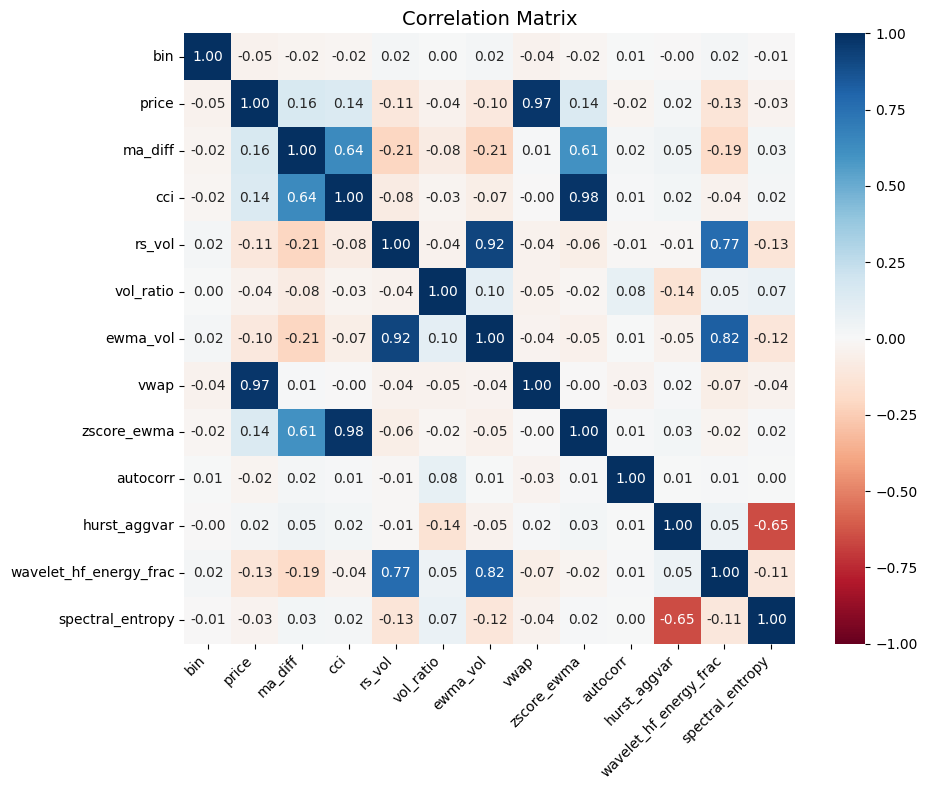

In [59]:
"""
This code block extracts a subset of columns from 'enhanced_events' to form a new DataFrame 
(feature_df), computes its correlation matrix, and visualizes that matrix using a heatmap.
We remove columns like 'ret', 'type', 'trgt', 'weights', and 't1', which may not be relevant 
for correlation analysis.

Finally, we plot the correlation matrix using matplotlib and seaborn. The color scale is 
centered at zero to visually distinguish positive and negative correlations.

Steps:
1. Create a feature DataFrame by dropping non-feature columns.
2. Compute the correlation matrix of remaining features.
3. Generate a heatmap visualization with annotated correlation coefficients.
   - 'RdBu' colormap highlights negative (blue) vs. positive (red) correlations.
   - 'square=True' ensures each cell in the heatmap is square-shaped.
   - 'annot=True' displays the numeric correlation value in each cell.
"""

# Extract only relevant feature columns for correlation analysis
feature_df = enhanced_events.drop(
    columns=['ret','type', 'trgt', 'weights', 't1'],
    errors='ignore'
).copy()

# Compute the correlation matrix across all feature columns
corr_matrix = feature_df.corr()

# Set up a figure with fixed size
plt.figure(figsize=(10, 8))

# Create a heatmap of the correlation matrix
sns.heatmap(
    corr_matrix,
    annot=True,       # Show correlation values in the cells
    fmt=".2f",        # Format values to two decimal places
    cmap="RdBu",      # Colormap ranging from red (positive) to blue (negative)
    center=0,         # Zero is placed at the midpoint of the color scale
    vmax=1, vmin=-1,  # Correlation ranges from -1 to +1
    square=True       # Make each cell square
)

# Rotate x-axis tick labels for better readability
plt.xticks(rotation=45, ha='right')
# Keep y-axis labels horizontal
plt.yticks(rotation=0)

# Title and layout adjustments
plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()


In [60]:
feature_df.tail()

,bin,price,ma_diff,cci,rs_vol,vol_ratio,ewma_vol,vwap,zscore_ewma,autocorr,hurst_aggvar,wavelet_hf_energy_frac,spectral_entropy
timestamp,,,,,,,,,,,,,
2025-04-10 06:10:00,-1,1.918680,99.7995,156.230824,0.000478,0.711579,0.000706,82176.202885,1.319167,-0.504639,1.020669,3.386113e-08,2.028472
2025-04-10 07:33:00,1,1.911569,-311.5060,-170.864948,0.000451,1.370272,0.000691,81821.886785,-1.163832,0.004753,0.959287,4.007587e-08,2.093276
2025-04-10 12:30:00,-1,1.921634,197.4410,398.441817,0.000985,1.474067,0.001362,82018.484687,3.206644,0.409950,0.968360,1.695595e-07,2.582347
2025-04-10 12:50:00,0,1.911248,-246.1860,-183.213959,0.001399,0.767767,0.001183,81959.770111,-1.491519,-0.158640,0.965067,1.275624e-07,2.745511
2025-04-10 13:37:00,0,1.906024,-304.4385,-226.038935,0.001103,1.535551,0.002198,81417.528530,-2.571250,-0.606528,0.894324,3.976792e-07,3.419557


In [61]:
# Separate the features (X) and labels (y) from our processed DataFrame. 
# 1. Remove the 'bin' column (and ignore any errors if it's missing) to form X. 
#    The 'bin' column typically holds the classification labels (+1, -1, or 0).
# 2. Extract the 'bin' column itself as y.
# 3. Also, copy over the 't1' column (label-end times) from the 'enhanced_events' DataFrame 
#    for use in PurgedKFold or other time-based validation strategies.
X = feature_df.drop(columns=['bin','price'], errors='ignore').copy()
y = feature_df['bin']
t1 = enhanced_events['t1'].copy()

In [62]:
X.shape

(4958, 11)

In [63]:
X.tail()

,ma_diff,cci,rs_vol,vol_ratio,ewma_vol,vwap,zscore_ewma,autocorr,hurst_aggvar,wavelet_hf_energy_frac,spectral_entropy
timestamp,,,,,,,,,,,
2025-04-10 06:10:00,99.7995,156.230824,0.000478,0.711579,0.000706,82176.202885,1.319167,-0.504639,1.020669,3.386113e-08,2.028472
2025-04-10 07:33:00,-311.5060,-170.864948,0.000451,1.370272,0.000691,81821.886785,-1.163832,0.004753,0.959287,4.007587e-08,2.093276
2025-04-10 12:30:00,197.4410,398.441817,0.000985,1.474067,0.001362,82018.484687,3.206644,0.409950,0.968360,1.695595e-07,2.582347
2025-04-10 12:50:00,-246.1860,-183.213959,0.001399,0.767767,0.001183,81959.770111,-1.491519,-0.158640,0.965067,1.275624e-07,2.745511
2025-04-10 13:37:00,-304.4385,-226.038935,0.001103,1.535551,0.002198,81417.528530,-2.571250,-0.606528,0.894324,3.976792e-07,3.419557


In [64]:
y.shape

(4958,)

In [65]:
y.tail()

timestamp
2025-04-10 06:10:00   -1
2025-04-10 07:33:00    1
2025-04-10 12:30:00   -1
2025-04-10 12:50:00    0
2025-04-10 13:37:00    0
Name: bin, dtype: int64

In [66]:
t1.shape

(4958,)

In [67]:
t1.tail()

timestamp
2025-04-10 06:10:00   2025-04-10 07:33:00
2025-04-10 07:33:00   2025-04-10 12:30:00
2025-04-10 12:30:00   2025-04-10 12:50:00
2025-04-10 12:50:00   2025-04-10 14:27:00
2025-04-10 13:37:00   2025-04-10 14:27:00
Name: t1, dtype: datetime64[ns]

In [68]:
# Training a Random Forest on our features using Purged K-Fold CV with an embargo.
# This setup helps prevent look-ahead bias and leakage by ensuring test data is isolated 
# from nearby training samples.

clf = RandomForestClassifier(n_estimators=100, random_state=0)

# Running 15-fold cross-validation using a custom scoring function that only evaluates 
# predictions on actual trade signals (non-zero labels). This avoids inflating performance 
# on 'no-trade' cases, which are often the majority class.

# We pass `t1` to account for label end-times during fold splits (required by PurgedKFold),
# and we apply sample weights to down-weigh overlapping events. A small embargo is used 
# to further reduce leakage between training and test sets.
scores_custom = cvScoreCustom(
    clf=clf,
    X=X,
    y=y,
    sample_weight=weights,
    scoring_func=trade_only_accuracy_score,  
    t1=t1,
    cv=15,               
    pctEmbargo=0.01
)

# Outputting the trade-only accuracy across all folds — this gives a more honest read
# on how well the model is picking up actual signal-based trades.
print("Trade-only scores per fold:", scores_custom)
if len(scores_custom) > 0:
    print("Mean:", scores_custom.mean(), "Std:", scores_custom.std())
else:
    print("No valid folds had training data.")


[cvScoreCustom] Fold 0: #train=0, #test=331 => Skipping fold: no train data
[cvScoreCustom] Fold 1: #train=328, #test=331
[cvScoreCustom] Fold 2: #train=660, #test=331
[cvScoreCustom] Fold 3: #train=991, #test=331
[cvScoreCustom] Fold 4: #train=1324, #test=331
[cvScoreCustom] Fold 5: #train=1655, #test=331
[cvScoreCustom] Fold 6: #train=1984, #test=331
[cvScoreCustom] Fold 7: #train=2317, #test=331
[cvScoreCustom] Fold 8: #train=2649, #test=330
[cvScoreCustom] Fold 9: #train=2979, #test=330
[cvScoreCustom] Fold 10: #train=3308, #test=330
[cvScoreCustom] Fold 11: #train=3638, #test=330
[cvScoreCustom] Fold 12: #train=3969, #test=330
[cvScoreCustom] Fold 13: #train=4298, #test=330
[cvScoreCustom] Fold 14: #train=4627, #test=330
Trade-only scores per fold: [0.49510525 0.50907147 0.49836073 0.46655527 0.53554223 0.50512256
 0.50016298 0.44030616 0.48336644 0.43299956 0.51289595 0.50585384
 0.55067181 0.46713484]
Mean: 0.4930820787148328 Std: 0.031650333916609985


In [69]:
def brown_durbin_evans_cusum(series, min_size=30):
    """
    Implements the Brown-Durbin-Evans CUSUM test, which tracks the recursive 
    estimation of a linear model's coefficients and evaluates whether any structural 
    breaks might have occurred. The function computes a running CUSUM statistic 
    (and associated boundaries) that can be used to detect parameter instability 
    over time.

    Parameters
    ----------
    series : pd.Series
        A univariate time series (e.g., prices or returns) for which we want
        to detect potential structural changes. Missing values are dropped
        before proceeding.
    min_size : int, optional
        The minimum number of initial observations (sample size) needed to 
        initialize the OLS recursion. Must be large enough to estimate the 
        regression parameters (default is 30).

    Returns
    -------
    pd.DataFrame
        Contains three columns indexed to the original time series:
         - 'cusum_stat': The cumulative sum of scaled residuals.
         - 'critical_line_pos': Upper boundary line typically used for 
           detecting significant upward deviations.
         - 'critical_line_neg': Lower boundary line for downward deviations.
        Rows with insufficient data (series shorter than min_size) return an 
        empty DataFrame.

    Notes
    -----
    - The procedure first estimates a simple OLS model of the form y_t = β0 + β1 * t 
      using 'min_size' initial points, then updates the regression coefficients 
      recursively for each new data point.
    - Residuals are scaled by the running estimate of the standard error, 
      and a cumulative sum of these scaled residuals forms the CUSUM statistic. 
      The boundaries are chosen following the Brown-Durbin-Evans approach, 
      where a typical cutoff is ~0.948 * sqrt(t).
    - If the statistic moves beyond these boundaries, it often signals a 
      structural break or parameter shift.

    Reference
    ---------
    Brown, R., Durbin, J., & Evans, J. (1975). Techniques for Testing the 
    Constancy of Regression Relationships over Time. Journal of the Royal 
    Statistical Society, Series B, 37(2), 149-163.
    """

    # Drop missing data to ensure a continuous array can be formed
    xraw = series.dropna()
    n = len(xraw)

    # If there isn't enough data to initialize the regression, return empty results
    if n < min_size:
        return pd.DataFrame(
            index=series.index, 
            columns=['cusum_stat','critical_line_pos','critical_line_neg']
        )

    # Build regressor: X includes a constant and a trend component (time index)
    t_arr = np.arange(n, dtype=float)
    X_full = np.column_stack((np.ones(n), t_arr))
    y_full = xraw.values
    w = np.full(n, np.nan, dtype=float)

    # Fit the initial model using the first 'min_size' observations
    X_init = X_full[:min_size]
    y_init = y_full[:min_size]
    XtX_inv = np.linalg.inv(X_init.T @ X_init)  # (X'X)^(-1) for the initial window
    beta_init = XtX_inv @ X_init.T @ y_init     # OLS solution for the initial segment
    resid_init = y_init - X_init @ beta_init    # Residuals on the initial segment

    # Estimate of the residual standard deviation in the initial segment
    resid_std = resid_init.std(ddof=2)
    w[:min_size] = resid_init / resid_std

    # Initialize recursion parameters
    beta_k = beta_init
    C_k = XtX_inv
    SSE = np.sum(resid_init**2)  # Sum of squared errors
    dof = min_size - 2           # Degrees of freedom (for a two-parameter model)

    # Recursively update OLS parameters for each new observation after min_size
    for i in range(min_size, n):
        x_i = X_full[i:i+1]           # Next row of design matrix
        y_i = y_full[i]               # Next observation
        y_hat_i = x_i @ beta_k        # Predicted value
        e_i = y_i - y_hat_i[0]        # Residual at time i
        SSE += e_i**2
        dof += 1
        sigma_hat = np.sqrt(SSE / dof)  # Updated estimate of residual std
        w[i] = e_i / sigma_hat

        # Perform rank-1 update on (X'X)^(-1)
        x_i_T = x_i.T
        denom = 1.0 + x_i @ C_k @ x_i_T
        if denom[0,0] != 0:
            gain = (C_k @ x_i_T) / denom[0,0]
            beta_k = beta_k + gain[:,0] * e_i  # Recursive parameter update
            C_k = C_k - gain @ (x_i @ C_k)     # Covariance matrix update

    # Compute the CUSUM by summing scaled residuals cumulatively
    cusum = np.nancumsum(w)

    # Brown-Durbin-Evans boundary ~ 0.948 * sqrt(t)
    boundary = 0.948 * np.sqrt(np.arange(1, n+1))
    cpos = boundary
    cneg = -boundary

    # Assemble results into a DataFrame
    out = pd.DataFrame(
        {
            'cusum_stat': cusum,
            'critical_line_pos': cpos,
            'critical_line_neg': cneg
        },
        index=xraw.index
    )

    # Reindex to match the full original time series
    out = out.reindex(series.index)

    return out


In [70]:
def sadf_test(series, min_length=30, max_lags=2):
    """
    Performs a Sup Augmented Dickey-Fuller (SADF) test on a univariate time series,
    iteratively computing the ADF statistic across all possible sub-windows ending
    at each observation from a minimal length onward. The maximum (i.e., "sup") of 
    these local ADF statistics is then recorded for each endpoint.
    
    Parameters
    ----------
    series : pd.Series
        The time series to be analyzed for explosive or unit-root behavior. 
        Missing values are removed before processing.
    min_length : int, optional
        The minimum rolling window size (in data points) for which the ADF test 
        can be calculated. Defaults to 30.
    max_lags : int, optional
        The maximum number of lags considered in the ADF regression. Defaults to 2.
    
    Returns
    -------
    pd.Series
        A time-indexed series containing the SADF statistic at each valid endpoint.
        Early observations where insufficient data exist will hold NaN values.

    Notes
    -----
    - The SADF procedure was introduced to detect periodically collapsing speculative 
      bubbles by repeatedly applying the standard ADF on expanding sub-samples. 
      For each endpoint i, all possible start points are considered, and the 
      maximum ADF statistic over these sub-windows is saved.
    - In practice, the SADF statistic can be further interpreted or compared 
      against critical values / bootstrap procedures to assess the likelihood 
      of explosive dynamics or bubble regimes.
    - This implementation restricts the sub-windows to a minimum length specified 
      by 'min_length'. Fewer than 'min_length' data points renders the test invalid 
      for that endpoint, and the result remains NaN.

    References
    ----------
    - Phillips, P. C. B., Shi, S., & Yu, J. (2015). Testing for multiple bubbles:
      Historical episodes of exuberance and collapse in the S&P 500.
      International Economic Review, 56(4), 1043-1078. 
    """
    # Drop any missing values to avoid issues with the ADF test
    s = series.dropna()
    N = len(s)

    # Prepare an output series to store SADF values
    out = pd.Series(np.nan, index=s.index)

    # If there's insufficient data to start computing ADF windows, return immediately
    if N < min_length:
        return out

    # Retrieve the time index for slicing
    idx = s.index

    # Iterate through each endpoint from 'min_length' to the end of the series
    for i in range(min_length, N):
        t_now = idx[i]
        local_stats = []

        # For each endpoint i, consider all possible starts that lead to 
        # at least 'min_length' data points in the sub-window
        for start_i in range(0, i - min_length + 1):
            window_slice = s.iloc[start_i : i + 1]
            if len(window_slice) < min_length:
                continue
            
            # Perform the ADF test on the current sub-window
            try:
                res = adfuller(window_slice, maxlag=max_lags, autolag=None, regression='c')
                local_stats.append(res[0])  # ADF test statistic is at index 0
            except:
                # If the ADF test fails for any reason, skip
                pass

        # Record the maximum ADF statistic found among all sub-windows ending at i
        if len(local_stats) > 0:
            out.loc[t_now] = max(local_stats)

    return out


In [71]:
def plugin_entropy(series, window=100):
    """
    Computes the "plugin" estimate of Shannon entropy for a rolling window over a discrete series.
    This method treats the observations in each window as categorical values, then calculates 
    the entropy based on the empirical probabilities (value_counts / total_count).
    
    Parameters
    ----------
    series : pd.Series
        The time series or discrete data for which to estimate entropy.
    window : int, optional
        The length of the rolling window. Defaults to 100.
    
    Returns
    -------
    pd.Series
        A time-indexed series containing the entropy value for each valid window endpoint.
        Early entries, where a full window can't be formed, remain NaN.
    
    Notes
    -----
    - The plugin estimate (or maximum likelihood estimate) of entropy is computed as:
          H = -∑(p_i * log2(p_i))
      where p_i is the empirical probability of each unique value in the window.
    - If the window slice does not contain enough unique elements or if it’s smaller 
      than the requested window size, a NaN is returned for that point.
    - Adding a small constant (1e-12) inside the log term avoids taking the log of zero 
      and the resulting NaN or infinite values.
    - This function is more meaningful when the data is discrete or has been binned 
      to produce categories. For continuous data, you might need a different 
      approach (e.g., kernel density estimation of probabilities).
    """
    # Remove any NaNs to ensure consistent counting
    s = series.dropna()
    
    # Prepare an output series, aligned to the input index
    out = pd.Series(index=series.index, dtype=float, name='plugin_entropy')
    
    # If there isn’t enough data to form the initial window, return all NaNs
    if len(s) < window:
        return out
    
    # Slide a rolling window across the series
    for i in range(window - 1, len(s)):
        idx_t = s.index[i]
        window_slice = s.iloc[i - window + 1 : i + 1]
        
        # Calculate the empirical distribution of values
        counts = window_slice.value_counts()
        probs = counts / counts.sum()
        
        # Estimate Shannon entropy using base-2 logarithm
        H = -np.sum(probs * np.log2(probs + 1e-12))
        
        # Store the result at the current index
        out.loc[idx_t] = H
    
    return out


In [72]:
def lempel_ziv_complexity(series, window=100):
    """
    Estimates a rolling Lempel-Ziv complexity measure of a sequence by treating 
    the values in each window as characters in a string. This function is better 
    suited for data that is already discretized or cast to an appropriate symbolic 
    representation.

    Parameters
    ----------
    series : pd.Series
        The input time series, whose values are converted to strings. Missing 
        values are dropped. Ensure the data is discrete or transform it into 
        a symbolic form before calling this function for meaningful results.
    window : int, optional
        The length of the rolling window. For each window, the concatenated 
        substring is used to compute complexity. Default is 100.
    
    ReturnsMethodology/Plan
    -------
    pd.Series
        A time-indexed series where each value corresponds to the normalized 
        Lempel-Ziv complexity in the current window. Early indices, where 
        there are insufficient data points for a full window, contain NaNs.
    
    Notes
    -----
    - Lempel-Ziv complexity is computed here by building a dictionary of 
      newly encountered substrings as we scan through the window slice.
    - The returned value for each window is the size of this dictionary, 
      divided by the window length, serving as a rough measure of how 
      'complex' or 'non-repetitive' the sequence is.
    - If the series is not discrete, you may want to bin or otherwise 
      discretize the data first. Continuous or high-cardinality data 
      may lead to large dictionaries and complexity values.
    """
    # Drop missing and convert to string
    s = series.dropna().astype(str)
    out = pd.Series(index=series.index, dtype=float, name='lz_complexity')
    N = len(s)
    
    # Return NaNs if we don't have enough data to form the initial window
    if N < window:
        return out

    def lz_dict_size(msg):
        """
        Computes the Lempel-Ziv dictionary size by tracking newly encountered 
        substrings. This is a basic approach: for each position, it searches 
        backward to find a substring not yet in the dictionary.
        """
        i = 0
        n = len(msg)
        library = []

        while i < n:
            new_seg = None
            # Check progressively shorter substrings in reverse order
            for j in range(n, i, -1):
                candidate = msg[i:j]
                if candidate not in library:
                    new_seg = candidate
            # If all candidates were in the dictionary, fall back 
            # to a minimal segment
            if new_seg is None:
                new_seg = msg[i:i+1]
            library.append(new_seg)
            i += len(new_seg)

        return len(library)

    # Slide the rolling window
    for i in range(window - 1, N):
        idx_t = s.index[i]
        # Concatenate all characters in the current window
        slice_str = "".join(s.iloc[i - window + 1 : i + 1].values)
        
        # Compute LZ dictionary size for this substring
        csize = lz_dict_size(slice_str)
        
        # Normalize complexity by window length
        out.loc[idx_t] = csize / float(window)

    return out


In [73]:
def corwin_schultz_spread(df_ohlc, window=2, colname='CS_spread'):
    """
    Computes an approximation of the bid-ask spread based on the Corwin-Schultz estimator 
    for each rolling window of size 'window'. This approach uses the highest and lowest 
    intraperiod prices to deduce spread characteristics, operating under certain microstructure 
    assumptions.

    Parameters
    ----------
    df_ohlc : pd.DataFrame
        A DataFrame containing 'High' and 'Low' columns (e.g., from daily, hourly, or any 
        regularized bar data). Missing or invalid rows should be handled prior to calling 
        this function for consistent results.Methodology/Plan
    window : int, optional
        The rolling window size over which the price range information is aggregated. 
        Defaults to 2, matching the original Corwin-Schultz paper’s suggestion for daily data.
    colname : str, optional
        The name of the returned Series, set to 'CS_spread' by default.

    Returns
    -------
    pd.Series
        A time-indexed Series of the approximate spread values, labeled by 'colname'. 
        Entries are aligned to the same index as df_ohlc, though the first 'window - 1' 
        observations will be NaN due to rolling window constraints.

    Notes
    -----
    - The Corwin-Schultz spread estimator is derived from the log-range (high/low) of 
      consecutive periods and involves specific assumptions about market microstructure 
      and price continuity. This method can offer insight into how transaction costs 
      or bid-ask spreads evolve over time without relying on limit order book data.
    - Conceptually, 'gamma' captures the squared log-range, while 'beta' aggregates 
      these squared ranges over the defined window. The final spread approximation is 
      the square root of this rolling sum.
    - It is advisable to confirm that the frequency and data quality (e.g., intraday 
      vs. daily bars) align with the assumptions behind Corwin-Schultz before interpreting 
      results.
    """
    # Extract the High and Low columns from the provided DataFrame
    h = df_ohlc['High']
    l = df_ohlc['Low']

    # Compute the squared log-range for each row
    gamma = (np.log(h / l)) ** 2

    # Sum these gamma values over the specified rolling window to produce beta
    beta = gamma.rolling(window=window, min_periods=window).sum()

    # Final spread approximation is the square root of beta
    cs_approx = np.sqrt(beta)
    cs_approx.name = colname

    return cs_approx


def add_corwin_schultz_spread(events, df_ohlc, window=2, colname='CS_spread'):
    """
    Inserts the Corwin-Schultz bid-ask spread estimate into an existing 'events' DataFrame, 
    aligning the values to the timestamps in 'events'. This allows subsequent research 
    to leverage cost-related features in an event-driven analysis.

    Parameters
    ----------
    events : pd.DataFrame
        A DataFrame of events, typically indexed by timestamps at which certain signals 
        or observations occur.
    df_ohlc : pd.DataFrame
        Candlestick data (Open, High, Low, Close) from which the High/Low columns 
        will be used to compute the Corwin-Schultz spread.
    window : int, optional
        Rolling window length for the Corwin-Schultz spread calculation. 
        Default is 2.
    colname : str, optional
        The column name under which the computed spread values are stored 
        in 'events'. Default is 'CS_spread'.

    Returns
    -------
    pd.DataFrame
        The original 'events' DataFrame with a new column named 'colname' containing 
        the Corwin-Schultz spread estimates at each event index.

    Notes
    -----
    - Aligning the spread estimates to event times can help analyze how transaction costs 
      or liquidity constraints evolve around certain market signals.
    - Ensure 'df_ohlc' has sufficient rows and that High/Low columns are valid. This 
      function will produce NaNs for rows outside the time range or for periods shorter 
      than the rolling window.
    """
    # Compute the Corwin-Schultz spread series
    cs_series = corwin_schultz_spread(df_ohlc, window=window, colname=colname)

    # Align the new series to the event timestamps and add as a new column
    events[colname] = cs_series.reindex(events.index)
    return events


In [74]:
def compute_kyles_lambda(prices, volumes, signs, window=50):
    """
    Computes Kyle's Lambda, a measure of market impact, by performing a linear 
    regression of returns against signed volume over a rolling window. Each 
    period's return is regressed on sign * volume to estimate the price impact 
    coefficient.

    Parameters
    ----------
    prices : pd.Series
        A time series of asset prices (e.g., closing prices).
    volumes : pd.Series
        The corresponding traded volumes for each timestamp in 'prices'.
    signs : pd.Series
        The sign of each trade (e.g., +1 for an uptick, -1 for a downtick). 
        Sometimes approximated by the sign of price changes.
    window : int, optional
        The length of the rolling window (in data points) over which to fit 
        each OLS regression. Default is 50.

    Returns
    -------
    pd.Series
        A time-indexed Series containing Kyle's Lambda estimates for each 
        rolling window endpoint, named 'kyles_lambda'. NaNs will appear 
        before reaching 'window' data points and whenever a regression 
        cannot be fit (e.g., all zero volumes).

    Notes
    -----
    - Kyle's Lambda is a simple metric from market microstructure to 
      approximate how returns respond to signed volume (i.e., 
      buyer-initiated or seller-initiated trades). Higher Lambda indicates 
      stronger price impact for a given volume.Methodology/Plan
    - The sign series can be derived from trade data or from 
      sign(price_t - price_(t-1)), but the more accurate approach 
      would use actual buyer/seller-initiated trade classifications 
      if available.
    - This implementation uses an OLS regression over each rolling window:
      
        returns_t = α + λ * (sign * volume)_t  +  ε_t
      
      with 'λ' being Kyle's Lambda. The intercept is typically not 
      essential for interpretation but is included for completeness.
    """
    # Compute returns as percentage changes
    ret = prices.pct_change().fillna(0)

    # Prepare output Series
    out = pd.Series(np.nan, index=prices.index, name='kyles_lambda')
    N = len(prices)
    
    # Not enough data => return entirely NaN
    if N < window:
        return out
    
    # Slide the rolling window across data
    for i in range(window - 1, N):
        idx_t = prices.index[i]
        slc = slice(i - window + 1, i + 1)
        
        y_all = ret.iloc[slc].values
        x_all = (signs.iloc[slc] * volumes.iloc[slc]).values
        
        # Construct design matrix with a constant (for intercept)
        X_all = sm.add_constant(x_all)
        
        # Valid rows => neither X nor y is infinite or NaN
        mask = np.isfinite(X_all).all(axis=1) & np.isfinite(y_all)
        if mask.sum() >= 3:
            X_valid = X_all[mask]
            y_valid = y_all[mask]
            
            # Ensure we have at least some variation in x
            if np.unique(X_valid[:, 1]).size > 1:
                model = sm.OLS(y_valid, X_valid, missing='drop').fit()
                out.iloc[i] = model.params[1]  # The slope => Kyle's Lambda
            else:
                out.iloc[i] = np.nan
        else:
            out.iloc[i] = np.nan

    return out

def add_kyles_lambda(events, df_tick, window=50, colname='kyles_lambda'):
    """
    Adds a column for Kyle's Lambda to an 'events' DataFrame, 
    aligning values to the event timestamps. By default, it 
    interprets a 'sign' column if present or approximates trade 
    sign from price changes if missing.

    Parameters
    ----------
    events : pd.DataFrame
        DataFrame of events indexed by time. The newly computed 
        Kyle's Lambda values will be inserted into this DataFrame 
        based on matching indices.
    df_tick : pd.DataFrame
        Must contain 'Close' and 'Volume' columns, and optionally 
        a 'sign' column. If 'sign' is absent, this function 
        approximates it by the sign of price changes.
    window : int, optional
        Rolling window length for the Kyle's Lambda calculation. 
        Defaults to 50.
    colname : str, optional
        Column name for the newly created series in 'events'. 
        Defaults to 'kyles_lambda'.

    Returns
    -------
    pd.DataFrame
        The original 'events' DataFrame, now containing a column 
        for Kyle's Lambda aligned with each event timestamp.

    Notes
    -----
    - This approach to sign trades by price difference is heuristic. 
      If more accurate buyer/seller classification data is available, 
      consider using it.
    - Kyle's Lambda can serve as a proxy for liquidity or price impact, 
      potentially useful for strategies that consider slippage.
    """
    # If 'sign' is missing, approximate via sign of price changes
    if 'sign' not in df_tick.columns:
        sign_approx = df_tick['Close'].diff().apply(np.sign).replace(0, 1)
        df_tick['sign'] = sign_approx

    # Compute Kyle's Lambda using the helper function
    lam_series = compute_kyles_lambda(
        prices=df_tick['Close'],
        volumes=df_tick['Volume'],
        signs=df_tick['sign'],
        window=window
    )

    # Align the resulting series to the event timestamps
    events[colname] = lam_series.reindex(events.index)
    return events


In [75]:
def compute_amihud_lambda(prices, volumes, window=50):
    """
    Calculates a rolling Amihud illiquidity measure (lambda), approximating 
    the price impact of trading volume over a specified look-back window.

    Parameters
    ----------
    prices : pd.Series
        Time-indexed price data, typically closing prices. 
    volumes : pd.Series
        Corresponding trade volumes for each price observation.
    window : int, optional
        The length of the rolling window used for the OLS regressions. 
        Default is 50 observations.

    Returns
    -------
    pd.Series
        A time-indexed Series named 'amihud_lambda', providing the slope 
        coefficient from the log price change regressed on the price-volume 
        product within each rolling window. Values for the initial (window-1) 
        observations will be NaN, as insufficient data is available.

    Notes
    -----
    - This implementation first converts prices to their logarithms 
      (logP) and measures the absolute change in logP over each interval. 
      The dependent variable (y) is then d(logP), while the independent 
      variable (x) is price * volume.
    - The slope from y ~ α + λ * (price * volume) captures how a change 
      in trading size might translate to a move in log-prices, serving as 
      a rough proxy for liquidity or market impact.
    - For consistency, we ignore any infinite values arising from log transformations 
      by filtering them out and returning NaNs where insufficient data is present.
    """
    # Compute log prices, dropping infinities and NaNs
    logp = np.log(prices).replace([np.inf, -np.inf], np.nan).dropna()

    # Absolute differences in log prices (i.e., approximate 'returns')
    dlogp = logp.diff().abs().fillna(0)

    # Prepare an output series with the original index
    out = pd.Series(np.nan, index=prices.index, name='amihud_lambda')
    N = len(logp)

    # If there's insufficient data for a single window, return all NaNs
    if N < window:
        return out

    # Compute Amihud lambda in a rolling fashion
    for i in range(window - 1, N):
        idx_t = logp.index[i]

        # Identify the current rolling slice
        slc = slice(i - window + 1, i + 1)

        # Dependent variable: changes in log price
        y = dlogp.iloc[slc].values
        # Independent variable: price * volume in the same slice
        x = (prices.iloc[slc] * volumes.iloc[slc]).values

        # Add a constant term for OLS
        X_ = sm.add_constant(x)

        # Fit a simple linear model: dlogP ~ α + λ * (price * volume)
        model = sm.OLS(y, X_).fit()

        # Store the slope (λ) as the local illiquidity measure
        out.loc[idx_t] = model.params[1]

    return out

def add_amihud_lambda(events, df_tick, window=50, colname='amihud_lambda'):
    """
    Enriches an existing 'events' DataFrame with a column representing 
    the Amihud illiquidity measure, computed from a 'df_tick' DataFrame.

    Parameters
    ----------
    events : pd.DataFrame
        DataFrame holding event records, typically indexed by time.
    df_tick : pd.DataFrame
        Must contain columns 'Close' and 'Volume' for the price and 
        volume data respectively.
    window : int, optional
        Rolling window size for the Amihud calculation. Defaults to 50.
    colname : str, optional
        The name of the new illiquidity column appended to 'events'. 
        Default is 'amihud_lambda'.

    Returns
    -------
    pd.DataFrame
        The original 'events' DataFrame, now updated with an additional 
        column (colname) containing the Amihud lambda values aligned 
        to each event timestamp.

    Notes
    -----
    - The Amihud measure is one of many ways to estimate market illiquidity 
      by regressing absolute log price changes against trade volume. 
      Higher lambda values typically indicate greater price impact 
      for a given size of transaction.
    """
    lam_ = compute_amihud_lambda(
        df_tick['Close'], 
        df_tick['Volume'], 
        window=window
    )
    # Align the computed series with the event timestamps, then attach as a new column
    events[colname] = lam_.reindex(events.index)
    return events



In [76]:
def compute_vpin(buy_vol, sell_vol, window=50):
    """
    Computes the Volume-Synchronized Probability of Informed Trading (VPIN) over 
    a rolling window. This measure captures the order flow imbalance in a way 
    that is volume-synchronized, potentially offering insight into how much 
    trading is driven by informed participants.

    Parameters
    ----------
    buy_vol : pd.Series
        The volume of buy-initiated trades for each time interval.
    sell_vol : pd.Series
        The volume of sell-initiated trades for each time interval.
    window : int, optional
        The look-back window over which buy/sell volumes are aggregated 
        to compute the imbalance. Default is 50.

    Returns
    -------
    pd.SeriesMethodology/Plan
        A time-indexed Series named 'vpin' containing the rolling VPIN 
        values. Rows before the first full window are NaN.

    Notes
    -----
    - VPIN is effectively:
        |(Σ(buy_vol) - Σ(sell_vol))| / (Σ(buy_vol) + Σ(sell_vol))
      aggregated over a rolling window of size 'window'.
    - High VPIN values can suggest increased informed trading or elevated 
      order flow toxicity.
    """
    # Aggregate buy and sell volumes over the rolling window
    rolled_buy = buy_vol.rolling(window=window, min_periods=window).sum()
    rolled_sell = sell_vol.rolling(window=window, min_periods=window).sum()

    # Compute absolute order flow imbalance and total traded volume
    diff = (rolled_buy - rolled_sell).abs()
    total = (rolled_buy + rolled_sell)

    # VPIN = absolute imbalance / total volume
    out = diff / total
    out.name = 'vpin'

    return out

def add_vpin(events, df_tick, window=50, colname='vpin'):
    """
    Adds a VPIN feature to an 'events' DataFrame, aligning with the event timestamps.
    If 'sign' is absent from df_tick, it approximates trade direction by comparing 
    consecutive closing prices (a simplistic approach).

    Parameters
    ----------
    events : pd.DataFrame
        A DataFrame indexed by event times. The newly computed VPIN values 
        will be aligned to these times.
    df_tick : pd.DataFrame
        Must contain 'Volume' and 'Close'. Optionally, it can include a 'sign' column 
        indicating trade direction. If missing, signs are derived from the sign 
        of price changes.
    window : int, optional
        Rolling window length for computing the VPIN measure. Default is 50.
    colname : str, optional
        The column name under which to store the VPIN values in 'events'. 
        Default is 'vpin'.

    Returns
    -------
    pd.DataFrame
        The updated 'events' DataFrame, augmented with a new 'colname' column 
        that holds the rolling VPIN values for each event timestamp.

    Notes
    -----
    - The sign method used here is a crude approximation for buy/sell classification. 
      If more accurate classification data is available (e.g., from trade data), 
      consider replacing it.
    - Aligning VPIN to event times allows one to observe whether events of interest 
      coincide with periods of elevated order flow imbalance or potential 
      informed trading activity.
    """
    # If 'sign' is missing, approximate direction based on price changes
    if 'sign' not in df_tick.columns:
        sign = df_tick['Close'].diff().apply(np.sign).replace(0, 1)
        df_tick['sign'] = sign

    # Calculate buy-initiated volume (sign>0) and sell-initiated volume (sign<0)
    buy_vol  = df_tick['Volume'] * (df_tick['sign'] > 0)
    sell_vol = df_tick['Volume'] * (df_tick['sign'] < 0)

    # Compute the VPIN measure
    vpin_ = compute_vpin(buy_vol, sell_vol, window=window)
    
    # Align with event timestamps
    events[colname] = vpin_.reindex(events.index)
    return events


In [77]:
def advanced_features_chunk(chunkIdx, events=None, tick=None, maxWindow=256):
    """
    Processes a subset of events (chunkIdx) to compute advanced financial metrics
    within a localized portion of the 'tick' data. This ensures efficiency by limiting
    each calculation to the relevant time window around the specified event range.

    Parameters:
    ----------
    chunkIdx : array-like
        A chunk of event indices (timestamps) that are processed together.
    events : pd.DataFrame, optional
        A DataFrame of all events, from which this chunk is extracted. Must be indexed
        by timestamps that match 'tick'.
    tick : pd.DataFrame, optional
        Price/volume data, including fractionally differenced prices under 'ffd_price'.
        Must cover the timestamp range needed to compute all features in this chunk.
    maxWindow : int, optional
        The maximum number of bars to look back before the earliest chunk event.
        This ensures that calculations with larger historical requirements can
        be completed.

    Returns:
    -------
    pd.DataFrame
        Contains newly computed columns for each event in chunkIdx. If chunkIdx is empty,
        returns an empty DataFrame.
Methodology/Plan
    Notes:
    -----
    - The function attempts to retrieve up to 'maxWindow' additional rows before the earliest
      event to accommodate feature calculations involving rolling windows or historical lookback.
    - Each step prints a brief message indicating which feature is being calculated, potentially
      useful when running in parallel or debugging performance bottlenecks.
    """
    
    # If no events in this chunk, return an empty DataFrame
    if len(chunkIdx) == 0:
        return pd.DataFrame()

    # Sort the chunk indices by time to identify earliest and latest event
    chunkIdxSorted = chunkIdx.sort_values()
    earliest = chunkIdxSorted[0]
    latest = chunkIdxSorted[-1]
    print(f"Processing chunk from {earliest} to {latest}, # of events in chunk = {len(chunkIdx)}")

    # Locate the segment in 'tick' that covers [earliest - maxWindow, latest]
    earliestPos = tick.index.searchsorted(earliest, side='left')
    earliestPos = min(earliestPos, len(tick) - 1)
    startPos = max(0, earliestPos - maxWindow)

    latestPos = tick.index.searchsorted(latest, side='right') - 1
    latestPos = max(0, min(latestPos, len(tick) - 1))

    # Extract the relevant portion of tick data for these events
    subTick = tick.iloc[startPos : latestPos + 1].copy()

    # Filter 'events' down to just this chunk
    subEvents = events.loc[chunkIdx].copy()

    # Compute Brown-Durbin-Evans CUSUM on the fractionally differenced price
    print("1) Calculating Brown-Durbin-Evans CUSUM...")
    csm = brown_durbin_evans_cusum(subTick['ffd_price'], min_size=30)
    # Attach the cumulative sum of residuals (CUSUM) to subEvents
    subEvents['cusum_stat'] = csm['cusum_stat'].reindex(subEvents.index)
    print("   -> Done CUSUM")

    # Compute Lempel-Ziv complexity, using sign of the differenced 'ffd_price'
    print("3) Calculating Lempel-Ziv complexity...")
    sign_ffd = np.sign(subTick['ffd_price'].diff()).fillna(0)
    lz_series = lempel_ziv_complexity(sign_ffd, window=100)
    subEvents['lz_complex'] = lz_series.reindex(subEvents.index)
    print("   -> Done LZ complexity")

    # Compute Kyle's lambda: a market impact measure from microstructure theory
    print("4) Calculating Kyle's lambda...")
    subEvents = add_kyles_lambda(subEvents, df_tick=subTick, window=50, colname='kyles_lambda')
    print("   -> Done Kyle's lambda")

    # Compute Corwin-Schultz bid-ask spread approximation
    print("6) Calculating Corwin–Schultz spread...")
    df_ohlc = subTick[['Open','High','Low','Close','Volume']].copy()
    subEvents = add_corwin_schultz_spread(subEvents, df_ohlc, window=2, colname='CS_spread')
    print("   -> Done Corwin–Schultz spread")

    # Compute Volume-Synchronized Probability of Informed Trading (VPIN)
    print("7) Calculating VPIN...")
    subEvents = add_vpin(subEvents, df_tick=subTick, window=50, colname='vpin')
    print("   -> Done VPIN")

    # Gather newly created columns for final output
    new_cols = [
        'cusum_stat',
        'lz_complex',
        'kyles_lambda',
        'CS_spread',
        'vpin'
    ]

    # Return only the columns of interest, ensuring alignment with subEvents' index
    partial_df = subEvents.reindex(columns=new_cols)
    return partial_df


In [78]:
def mp_add_advanced_features(events, tick, maxWindow=256, numThreads=None):
    """
    Applies a set of advanced feature engineering functions (from advanced_features_chunk)
    to an 'events' DataFrame in parallel, leveraging mpPandasObj to distribute
    event subsets (chunks) among multiple processes.

    Parameters
    ----------
    events : pd.DataFrame
        The main DataFrame of events, where each row is typically indexed by a 
        timestamp. Advanced features will be appended to this DataFrame's rows 
        after parallel computation.
    tick : pd.DataFrame
        Time-series data (e.g., price, volume, fractionally differenced prices)
        that the advanced_features_chunk relies on to compute features for each event.
    maxWindow : int, optional
        The maximum look-back window size for references within advanced_features_chunk.
        This ensures that enough historical data is retrieved for calculations 
        that require rolling or historical context. Default is 256.
    numThreads : int, optional
        The number of parallel worker processes. If None, it defaults to the system's 
        CPU core count. Adjust to control parallelism based on resource availability.

    Returns
    -------
    pd.DataFrame
        A copy of the original 'events' DataFrame, augmented with columns corresponding
        to each advanced feature computed by advanced_features_chunk (e.g., 'cusum_stat',
        'lz_complex', 'kyles_lambda', etc.).

    Notes
    -----
    - The mpPandasObj function partitions events.index into chunks, passing each subset 
      to workerFunc (which is advanced_features_chunk).
    - If any chunk has fewer or no events, advanced_features_chunk gracefully handles it,
      returning an empty or minimal DataFrame.
    - The final results from all chunks are then combined and aligned to 'events.index',
      ensuring rows match their timestamps and newly computed feature columns are populated 
      where possible.
    """
    from functools import partial
    
    # Partially apply advanced_features_chunk with the same events, tick, and maxWindow
    workerFunc = partial(
        advanced_features_chunk, 
        events=events, 
        tick=tick, 
        maxWindow=maxWindow
    )

    # Distribute the event indices among parallel processes
    partial_new = mpPandasObj(
        func=workerFunc,
        pdObj=('index', events.index),
        numThreads=numThreads,
        mpBatches=1
    )

    # Create a copy of the original events DataFrame to hold the new columns
    final_df = events.copy()

    # Transfer the newly computed columns from partial_new to final_df
    for col in partial_new.columns:
        final_df[col] = partial_new[col]

    return final_df


In [79]:
start = time.time()

# Apply the advanced feature computations in parallel
enhanced_events_v2 = mp_add_advanced_features(
    events=enhanced_events,
    tick=tick,
    maxWindow=256,
    numThreads=None  # Set an integer here if you want a fixed number of processes
)

end = time.time()
elapsed = end - start

print(f"Time taken for advanced features: {elapsed:.4f} seconds")


Processing chunk from 2024-02-21 07:06:00 to 2024-03-10 10:12:00, # of events in chunk = 309
1) Calculating Brown-Durbin-Evans CUSUM...
Processing chunk from 2024-03-10 14:32:00 to 2024-03-22 22:31:00, # of events in chunk = 310
1) Calculating Brown-Durbin-Evans CUSUM...
Processing chunk from 2024-03-22 23:31:00 to 2024-04-15 14:09:00, # of events in chunk = 310
1) Calculating Brown-Durbin-Evans CUSUM...
Processing chunk from 2024-04-15 14:42:00 to 2024-05-08 15:15:00, # of events in chunk = 310
1) Calculating Brown-Durbin-Evans CUSUM...
   -> Done CUSUM
3) Calculating Lempel-Ziv complexity...
   -> Done CUSUM
3) Calculating Lempel-Ziv complexity...
Processing chunk from 2024-05-08 17:04:00 to 2024-06-27 06:16:00, # of events in chunk = 310
1) Calculating Brown-Durbin-Evans CUSUM...
Processing chunk from 2024-06-27 09:54:00 to 2024-07-27 20:49:00, # of events in chunk = 310
1) Calculating Brown-Durbin-Evans CUSUM...
Processing chunk from 2024-07-27 20:53:00 to 2024-08-09 21:06:00, # of

In [80]:
enhanced_events_v2.tail()

,ret,bin,t1,type,trgt,weights,price,ma_diff,cci,rs_vol,...,zscore_ewma,autocorr,hurst_aggvar,wavelet_hf_energy_frac,spectral_entropy,cusum_stat,lz_complex,kyles_lambda,CS_spread,vpin
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-04-10 06:10:00,-0.010253,-1,2025-04-10 07:33:00,down,0.01,0.416667,1.918680,99.7995,156.230824,0.000478,...,1.319167,-0.504639,1.020669,3.386113e-08,2.028472,-20634.644611,0.67,0.000016,0.000946,0.099890
2025-04-10 07:33:00,0.010798,1,2025-04-10 12:30:00,up,0.01,0.333333,1.911569,-311.5060,-170.864948,0.000451,...,-1.163832,0.004753,0.959287,4.007587e-08,2.093276,-20581.771242,0.68,0.000016,0.001066,0.015381
2025-04-10 12:30:00,-0.010992,-1,2025-04-10 12:50:00,down,0.01,0.333333,1.921634,197.4410,398.441817,0.000985,...,3.206644,0.409950,0.968360,1.695595e-07,2.582347,-20459.241946,0.68,0.000010,0.006717,0.363976
2025-04-10 12:50:00,-0.000178,0,2025-04-10 14:27:00,None,0.01,0.416667,1.911248,-246.1860,-183.213959,0.001399,...,-1.491519,-0.158640,0.965067,1.275624e-07,2.745511,-20449.529043,0.67,0.000011,0.002737,0.020139
2025-04-10 13:37:00,0.006201,0,2025-04-10 14:27:00,None,0.01,0.444444,1.906024,-304.4385,-226.038935,0.001103,...,-2.571250,-0.606528,0.894324,3.976792e-07,3.419557,-20436.401750,0.69,0.000022,0.007636,0.260964


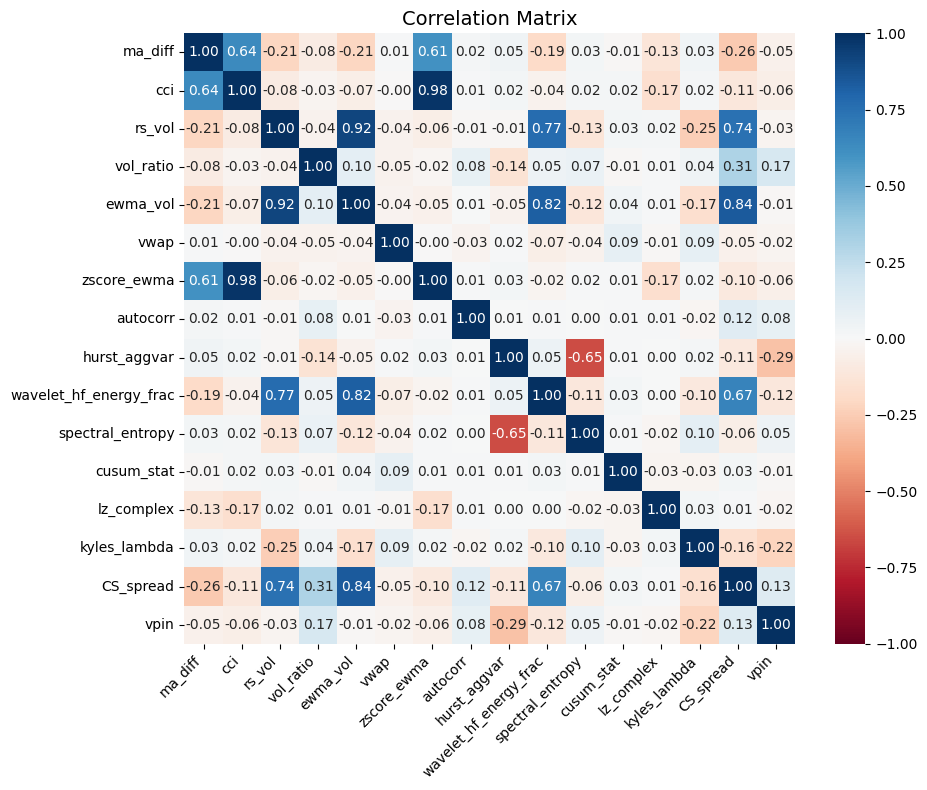

In [81]:
# Drop non-feature columns
feature_enhanced = enhanced_events_v2.drop(
    columns=['ret','type','trgt','weights','t1','price','bin'], 
    errors='ignore'
).copy()

# Compute the correlation matrix for the reduced feature set
corr_matrix = feature_enhanced.corr()

# Set up the figure
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Generate a heatmap visualization
sns.heatmap(
    corr_matrix,
    annot=True,       # Show correlation coefficients in each cell
    fmt=".2f",        # Format to two decimals
    cmap="RdBu",      # Color map from red (positive) to blue (negative)
    center=0,         # Zero is centered in the color range
    vmax=1, vmin=-1,  # Correlation values span -1 to 1
    square=True
)

# Rotate the x-ticks for improved readability
plt.xticks(rotation=45, ha='right')
# Keep y-ticks horizontal
plt.yticks(rotation=0)

plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

In [82]:
feature_enhanced.tail()

,ma_diff,cci,rs_vol,vol_ratio,ewma_vol,vwap,zscore_ewma,autocorr,hurst_aggvar,wavelet_hf_energy_frac,spectral_entropy,cusum_stat,lz_complex,kyles_lambda,CS_spread,vpin
timestamp,,,,,,,,,,,,,,,,
2025-04-10 06:10:00,99.7995,156.230824,0.000478,0.711579,0.000706,82176.202885,1.319167,-0.504639,1.020669,3.386113e-08,2.028472,-20634.644611,0.67,0.000016,0.000946,0.099890
2025-04-10 07:33:00,-311.5060,-170.864948,0.000451,1.370272,0.000691,81821.886785,-1.163832,0.004753,0.959287,4.007587e-08,2.093276,-20581.771242,0.68,0.000016,0.001066,0.015381
2025-04-10 12:30:00,197.4410,398.441817,0.000985,1.474067,0.001362,82018.484687,3.206644,0.409950,0.968360,1.695595e-07,2.582347,-20459.241946,0.68,0.000010,0.006717,0.363976
2025-04-10 12:50:00,-246.1860,-183.213959,0.001399,0.767767,0.001183,81959.770111,-1.491519,-0.158640,0.965067,1.275624e-07,2.745511,-20449.529043,0.67,0.000011,0.002737,0.020139
2025-04-10 13:37:00,-304.4385,-226.038935,0.001103,1.535551,0.002198,81417.528530,-2.571250,-0.606528,0.894324,3.976792e-07,3.419557,-20436.401750,0.69,0.000022,0.007636,0.260964


In [83]:
# Define a cutoff date to split the dataset into training and testing subsets. 
# In this case, observations up to and including December 31, 2024, are used 
# for training, and all later observations are reserved for testing. 
cutoff_date = pd.Timestamp("2024-12-31 23:59:59")

# Construct boolean masks identifying which rows belong to the training set 
# and which belong to the test set based on their timestamps relative to the cutoff.
train_mask = X.index <= cutoff_date
test_mask  = X.index >  cutoff_date

# Extract the training features and corresponding labels, ensuring both 
# share consistent timestamps.
X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

# Align the label-end times (t1) with the training index, so that 
# only valid entries are retained for model building.
t1_train = t1.loc[t1.index.intersection(X_train.index)]

# If sample weights have been computed, split them analogously; otherwise, 
# the model proceeds without weighting.
if weights is not None:
    weights_train = weights.loc[train_mask]
else:
    weights_train = None

# Slice out the test features and labels for all observations 
# occurring after the cutoff.
X_test = X.loc[test_mask]
y_test = y.loc[test_mask]


In [84]:
# Instantiate a RandomForestClassifier with 100 trees and a fixed random state 
# for repeatable performance analysis.
clf = RandomForestClassifier(n_estimators=100, random_state=0)

# Run the custom cross-validation procedure on the training set. We provide:
# - X_train, y_train: Our training features and labels
# - sample_weight=weights_train: Optional weighting to handle overlapping events
# - trade_only_accuracy_score: Focuses on nonzero label accuracy
# - t1=t1_train for PurgedKFold to avoid look-ahead bias in financial data
# - cv=15 for a 15-fold split 
# - pctEmbargo=0.01 to remove additional data near test periods
scores_custom = cvScoreCustom(
    clf=clf,
    X=X_train,          
    y=y_train,
    sample_weight=weights_train,
    scoring_func=trade_only_accuracy_score,  
    t1=t1_train,
    cv=15,             
    pctEmbargo=0.01
)

# Display the trade-only accuracy scores from each fold. If any folds were 
# valid, show their mean and standard deviation as well.
print("Trade-only scores per fold:", scores_custom)
if len(scores_custom) > 0:
    print("Mean CV score:", scores_custom.mean(), "Std CV score:", scores_custom.std())
else:
    print("No valid folds had training data. (e.g., you had too few events.)")


[cvScoreCustom] Fold 0: #train=0, #test=243 => Skipping fold: no train data
[cvScoreCustom] Fold 1: #train=243, #test=243
[cvScoreCustom] Fold 2: #train=486, #test=243
[cvScoreCustom] Fold 3: #train=729, #test=243
[cvScoreCustom] Fold 4: #train=972, #test=243
[cvScoreCustom] Fold 5: #train=1215, #test=243
[cvScoreCustom] Fold 6: #train=1457, #test=243
[cvScoreCustom] Fold 7: #train=1701, #test=243
[cvScoreCustom] Fold 8: #train=1943, #test=243
[cvScoreCustom] Fold 9: #train=2186, #test=243
[cvScoreCustom] Fold 10: #train=2430, #test=243
[cvScoreCustom] Fold 11: #train=2673, #test=243
[cvScoreCustom] Fold 12: #train=2916, #test=243
[cvScoreCustom] Fold 13: #train=3159, #test=242
[cvScoreCustom] Fold 14: #train=3401, #test=242
Trade-only scores per fold: [0.44753346 0.49763672 0.5777974  0.51656776 0.43797834 0.5029223
 0.47221881 0.48422678 0.52450347 0.49880324 0.48094863 0.45290801
 0.49026276 0.46221561]
Mean CV score: 0.4890373776909684 Std CV score: 0.0348296797442108


In [85]:
# Fit the RandomForestClassifier on the training set using optional sample weights
clf.fit(X_train, y_train, sample_weight=weights_train)

# Predict labels on the out-of-sample test set
y_pred_test = clf.predict(X_test)

# Evaluate the performance strictly on non-zero (trade) labels
final_test_score = trade_only_accuracy_score(y_test.values, y_pred_test)
print("Out-of-sample (post-2024) trade-only score:", final_test_score)


Out-of-sample (post-2024) trade-only score: 0.5034220532319391


In [86]:
def get_oof_predictions_primary(
    X, y, t1=None, sample_weight=None, cv=5, pctEmbargo=0.0, random_state=42
):
    """
    Train a 'primary' classifier (e.g., RandomForest) in a PurgedKFold setting
    and return out-of-fold side predictions (discrete labels +1/-1/0).
    The returned array is aligned exactly with X.index.
    
    Args:
        X : pd.DataFrame
            Features aligned with y.
        y : pd.Series
            Labels in {+1, -1, 0}, index‐aligned with X.
        t1 : pd.Series
            Label-end times for PurgedKFold (index must match X). If None, normal K-fold is used.
        sample_weight : pd.Series or None
            Optional sample weights. If None, weighting is skipped.
        cv : int or a cross-validator
            If an int, number of splits for PurgedKFold = cv. 
            If a cross-validator instance, use that directly.
        pctEmbargo : float
            Fraction embargo for PurgedKFold if cv is an int.
        random_state : int
            RNG seed for reproducible results.
            
    Returns:
        oof_preds : np.ndarray
            An array of out-of-fold predictions for each sample in X (index order).
    """
    # We’ll skip folds if #train < 10. By default, train a simple RandomForest in each fold.
    from sklearn.model_selection import KFold
    
    if isinstance(cv, int) and t1 is not None:
        # Build a PurgedKFold if user gave integer cv + t1
        cvGen = PurgedKFold(n_splits=cv, t1=t1, pctEmbargo=pctEmbargo)
    elif isinstance(cv, int):
        # Fall back to plain KFold if no t1
        cvGen = KFold(n_splits=cv, shuffle=False)
    else:
        # If cv is a cross-validator instance
        cvGen = cv

    clf_primary = RandomForestClassifier(
        n_estimators=100, random_state=random_state
    )
    oof_preds = np.full(len(X), np.nan, dtype=float)

    fold_id = 0
    for tr_idx, val_idx in cvGen.split(X):
        n_train = len(tr_idx)
        n_val = len(val_idx)
        if n_train < 10:
            print(f"[Primary OOF] Fold={fold_id} SKIPPED (#train={n_train}, #val={n_val})")
            fold_id += 1
            continue

        print(f"[Primary OOF] Fold={fold_id}, #train={n_train}, #val={n_val}")
        X_tr = X.iloc[tr_idx]
        y_tr = y.iloc[tr_idx]
        if sample_weight is not None:
            w_tr = sample_weight.iloc[tr_idx]
        else:
            w_tr = None

        # Fit a RandomForest
        clf_primary.fit(X_tr, y_tr, sample_weight=w_tr)

        # Predict discrete labels (+1/-1/0) on the validation portion
        preds_val = clf_primary.predict(X.iloc[val_idx])
        oof_preds[val_idx] = preds_val

        fold_id += 1

    return oof_preds


In [87]:
def compute_pnl_from_sides(sides, close):
    """
    Very basic PnL simulator. 
    sides: +1 / -1 / 0 for each index
    close: price series aligned with 'sides' index
    Returns a pd.Series of cumulative PnL over time,
    assuming each side(t) is held for [t, t+1) only.

    This is just a toy example:
    PnL(t+1) = side(t) * (Close(t+1) - Close(t)) / Close(t)
    Then we do a cumulative sum over time.
    """
    pnl = sides.shift(1) * (close.diff() / close.shift(1))
    # shift(1) so we “enter” at time t with side(t),
    # then realize gains from t -> t+1. 
    # This is just one simplistic approach.
    pnl_cum = pnl.cumsum().fillna(0)
    return pnl_cum

def make_meta_labels(X, y, primary_sides):
    """
    Generate meta-labels based on whether the predicted side from the primary model
    was actually correct. If the model made a side prediction (+1 or -1) and it matched
    the true label, it's a hit (1). Everything else — including 'no trade' — is a miss (0).
    """
    
    correct = (primary_sides != 0) & (primary_sides == y)
    meta_label = correct.astype(int)
    return meta_label

# Get out-of-fold predictions from the primary model.
# These side predictions are generated using Purged K-Fold CV to stay realistic 
# and avoid training/test contamination.
oof_primary_sides = get_oof_predictions_primary(
    X_train, 
    y_train, 
    t1=t1_train,        
    sample_weight=weights_train,
    cv=5,              
    pctEmbargo=0.01, 
    random_state=42
)
oof_primary_sides_series = pd.Series(oof_primary_sides, index=X_train.index, name='side')

# Now we check how often the model's side prediction was actually right.
# Meta-label is 1 if it nailed the direction, 0 if it didn’t (or didn’t predict).
meta_y_train = make_meta_labels(X_train, y_train, oof_primary_sides_series)
print("Counts of meta‐labels:\n", meta_y_train.value_counts())

# Let’s also look at how much PnL the model's side predictions would've made,
# based on actual price movement — gives a sense of trading performance.
pnl_primary_oof = compute_pnl_from_sides(oof_primary_sides_series, close=tick['Close'])
print("\nPnL from primary model OOF sides (cumulative) at last train date =",
      pnl_primary_oof.loc[X_train.index].iloc[-1])


[Primary OOF] Fold=0 SKIPPED (#train=5, #val=729)
[Primary OOF] Fold=1, #train=733, #val=729
[Primary OOF] Fold=2, #train=1460, #val=729
[Primary OOF] Fold=3, #train=2191, #val=728
[Primary OOF] Fold=4, #train=2915, #val=728
Counts of meta‐labels:
 0    2202
1    1441
Name: count, dtype: int64

PnL from primary model OOF sides (cumulative) at last train date = -0.015098054188150503


In [98]:
def get_oof_predictions_primary_with_proba(
    X, y, t1=None, sample_weight=None, cv=5, pctEmbargo=0.0, random_state=42
):
    """
    Similar to your original 'get_oof_predictions_primary', 
    but also returns predicted probabilities for side=+1.
    
    Returns
    -------
    oof_sides : np.ndarray
        Out-of-fold class predictions {+1, -1, 0}.
    oof_proba : np.ndarray
        Out-of-fold probabilities for side=+1 (range [0, 1]).
    """
    from sklearn.model_selection import KFold

    # Decide on cross-validator
    if isinstance(cv, int) and (t1 is not None):
        cvGen = PurgedKFold(n_splits=cv, t1=t1, pctEmbargo=pctEmbargo)
    elif isinstance(cv, int):
        cvGen = KFold(n_splits=cv, shuffle=False)
    else:
        cvGen = cv

    clf_primary = RandomForestClassifier(n_estimators=100, random_state=random_state)

    oof_sides = np.full(len(X), np.nan, dtype=float)
    oof_proba = np.full(len(X), np.nan, dtype=float)

    fold_id = 0
    for tr_idx, val_idx in cvGen.split(X):
        n_train = len(tr_idx)
        n_val   = len(val_idx)
        if n_train < 10:
            print(f"[Primary OOF+Proba] Fold={fold_id} SKIPPED (#train={n_train}, #val={n_val})")
            fold_id += 1
            continue

        print(f"[Primary OOF+Proba] Fold={fold_id}, #train={n_train}, #val={n_val}")
        X_tr = X.iloc[tr_idx]
        y_tr = y.iloc[tr_idx]
        if sample_weight is not None:
            w_tr = sample_weight.iloc[tr_idx]
        else:
            w_tr = None

        # Fit the random forest
        clf_primary.fit(X_tr, y_tr, sample_weight=w_tr)

        preds_val_sides = clf_primary.predict(X.iloc[val_idx])
        oof_sides[val_idx] = preds_val_sides

        # Probabilities (for side=+1)
        preds_val_proba = clf_primary.predict_proba(X.iloc[val_idx])
        classes_ = clf_primary.classes_
        if +1 in classes_:
            idx_plus = np.where(classes_ == +1)[0][0]
            proba_plus_one = preds_val_proba[:, idx_plus]
        else:
            proba_plus_one = np.zeros(len(val_idx))
        oof_proba[val_idx] = proba_plus_one

        fold_id += 1

    return oof_sides, oof_proba


def cvScoreCustom_withPnl(
    clf, X, y, close_prices, 
    sample_weight=None, scoring_func=None, t1=None, cv=None, pctEmbargo=0.0
):
    """
    A variation of cvScoreCustom that *also* collects each fold's PnL 
    by simulating trades on the validation set.
    """
    if scoring_func is None:
        raise ValueError("Provide scoring_func=... e.g., trade_only_accuracy_score")

    from sklearn.model_selection import KFold

    if cv is None:
        cv = 3

    if isinstance(cv, int) and t1 is not None:
        cvGen = PurgedKFold(n_splits=cv, t1=t1, pctEmbargo=pctEmbargo)
    elif isinstance(cv, int):
        cvGen = KFold(n_splits=cv, shuffle=False)
    else:
        cvGen = cv

    scores = []
    fold_pnls = []

    for fold_id, (train_idx, test_idx) in enumerate(cvGen.split(X=X)):
        print(f"[Meta CV w/PnL] Fold {fold_id}: #train={len(train_idx)}, #test={len(test_idx)}", end="")
        if len(train_idx) <= 10:
            print(" => Skipping fold (not enough train data)")
            continue
        print()

        # Partition the data
        X_train_fold = X.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        X_val_fold   = X.iloc[test_idx]
        y_val_fold   = y.iloc[test_idx]

        if sample_weight is not None:
            w_train_fold = sample_weight.iloc[train_idx]
            w_val_fold   = sample_weight.iloc[test_idx]
        else:
            w_train_fold = None
            w_val_fold   = None

        # Fit
        clf.fit(X_train_fold, y_train_fold, sample_weight=w_train_fold)

        # Predict
        val_preds = clf.predict(X_val_fold)
        sc = scoring_func(
            y_val_fold.values, val_preds, 
            sample_weight=None if w_val_fold is None else w_val_fold.values
        )
        scores.append(sc)

        # Compute fold-level PnL
        val_sides_series = pd.Series(val_preds, index=X_val_fold.index)
        pnl_series = compute_pnl_from_sides(val_sides_series, close_prices)
        fold_pnl = pnl_series.loc[X_val_fold.index].iloc[-1]
        fold_pnls.append(fold_pnl)

    return np.array(scores), np.array(fold_pnls)


# Primary OOF predictions (sides + proba)
oof_sides, oof_proba = get_oof_predictions_primary_with_proba(
    X_train,
    y_train,
    t1=t1_train,
    sample_weight=weights_train,
    cv=5,
    pctEmbargo=0.01,
    random_state=42
)

oof_primary_sides_series = pd.Series(oof_sides, index=X_train.index, name='side')
oof_primary_proba_series = pd.Series(oof_proba, index=X_train.index, name='side_proba')

# Build meta labels: 1 if primary side was correct, 0 otherwise
meta_y_train = make_meta_labels(X_train, y_train, oof_primary_sides_series)
print("\n[Meta labels] #1s / #0s =\n", meta_y_train.value_counts())

# Check PnL from primary OOF sides
pnl_primary_oof = compute_pnl_from_sides(oof_primary_sides_series, close=tick['Close'])
print("\nPnL from primary model OOF sides =", pnl_primary_oof.loc[X_train.index].iloc[-1])

# Prepare meta-features (no fillna or dropna!)
X_meta_train = X_train.copy()
X_meta_train['primary_side']  = oof_primary_sides_series
X_meta_train['primary_proba'] = oof_primary_proba_series

# The meta-model: Another Random Forest
meta_clf = RandomForestClassifier(n_estimators=100, random_state=123)

def meta_accuracy_score(y_true, y_pred, sample_weight=None):
    return trade_only_accuracy_score(y_true, y_pred, sample_weight=sample_weight)

# Cross-validate with fold-by-fold PnL
scores_meta, foldPnls_meta = cvScoreCustom_withPnl(
    clf=meta_clf,
    X=X_meta_train,
    y=meta_y_train,
    close_prices=tick['Close'],
    sample_weight=None,
    scoring_func=meta_accuracy_score,
    t1=t1_train,
    cv=5,
    pctEmbargo=0.01
)

print("\n[Meta CV] RandomForest scores:", scores_meta)
print("Mean meta CV accuracy:", scores_meta.mean())
print("\nFold-by-fold validation PnL:", foldPnls_meta)
print("Mean fold PnL:", foldPnls_meta.mean())

# Fit meta-model on entire training set
meta_clf.fit(X_meta_train, meta_y_train)

# Evaluate on test set
# Fit primary model on full training set
primary_full = RandomForestClassifier(n_estimators=100, random_state=42)
primary_full.fit(X_train, y_train, sample_weight=weights_train)

primary_sides_test = primary_full.predict(X_test)
primary_proba_test_all = primary_full.predict_proba(X_test)

classes_test_ = primary_full.classes_
if +1 in classes_test_:
    idx_plus_test = np.where(classes_test_ == +1)[0][0]
    primary_proba_test = primary_proba_test_all[:, idx_plus_test]
else:
    primary_proba_test = np.zeros(len(X_test))

# Build test meta-features
X_meta_test = X_test.copy()
X_meta_test['primary_side']  = primary_sides_test
X_meta_test['primary_proba'] = primary_proba_test

# Meta decides
meta_decision_test = meta_clf.predict(X_meta_test)

# Final sides
final_sides_test = primary_sides_test * meta_decision_test

# Evaluate final on test set
test_pnl = compute_pnl_from_sides(pd.Series(final_sides_test, index=X_test.index), tick['Close'])
test_trade_acc = trade_only_accuracy_score(
    y_test.values,
    final_sides_test,
    sample_weight=None
)

print("\n[Meta on test] trade-only accuracy:", test_trade_acc)
print("[Meta on test] final test PnL (cumulative at last):", test_pnl.loc[X_test.index].iloc[-1])


[Primary OOF+Proba] Fold=0 SKIPPED (#train=5, #val=729)
[Primary OOF+Proba] Fold=1, #train=733, #val=729
[Primary OOF+Proba] Fold=2, #train=1460, #val=729
[Primary OOF+Proba] Fold=3, #train=2191, #val=728
[Primary OOF+Proba] Fold=4, #train=2915, #val=728

[Meta labels] #1s / #0s =
 0    2202
1    1441
Name: count, dtype: int64

PnL from primary model OOF sides = -0.015098054188150503
[Meta CV w/PnL] Fold 0: #train=5, #test=729 => Skipping fold (not enough train data)
[Meta CV w/PnL] Fold 1: #train=733, #test=729
[Meta CV w/PnL] Fold 2: #train=1460, #test=729
[Meta CV w/PnL] Fold 3: #train=2191, #test=728
[Meta CV w/PnL] Fold 4: #train=2915, #test=728

[Meta CV] RandomForest scores: [0.00260417 0.39569536 0.3600713  0.41426404]
Mean meta CV accuracy: 0.29315871714291636

Fold-by-fold validation PnL: [ 0.00205544  0.03084141 -0.01856054  0.01773672]
Mean fold PnL: 0.00801825766038091

[Meta on test] trade-only accuracy: 0.20740169622205087
[Meta on test] final test PnL (cumulative at las

In [99]:
# Load the raw CSV without parsing datetime just yet
us30_tick = pd.read_csv("us30.csv")

# Clean up the timezone info manually:
# Remove the "GMT" string and insert a colon into the offset for proper parsing
# Example: "-0600" → "-06:00"
temp = us30_tick["Local time"].str.replace("GMT", "", regex=False)
temp = temp.str.replace(r"(-\d{2})(\d{2})$", r"\1:\2", regex=True)
# Example: "1.05.2022 00:00:00.000 -0600" => "1.05.2022 00:00:00.000 -06:00"

# Now parse the cleaned datetime strings into timezone-aware UTC timestamps
us30_tick["Local time"] = pd.to_datetime(
    temp,
    format="%d.%m.%Y %H:%M:%S.%f %z",  
    errors="coerce",
    utc=True,                        
)

# Rename the parsed datetime column to 'Date' and set it as index
us30_tick.rename(columns={"Local time": "Date"}, inplace=True)
us30_tick.set_index("Date", inplace=True)

# Drop the timezone info if you want naive timestamps (UTC assumed)
us30_tick.index = us30_tick.index.tz_localize(None)

print("Read US30 CSV data:", us30_tick.shape, "rows")
print(us30_tick.head())


Read US30 CSV data: (1027429, 5) rows
                          Open       High        Low      Close  Volume
Date                                                                   
2022-05-01 06:00:00  33080.799  33080.799  33080.799  33080.799     0.0
2022-05-01 06:01:00  33080.799  33080.799  33080.799  33080.799     0.0
2022-05-01 06:02:00  33080.799  33080.799  33080.799  33080.799     0.0
2022-05-01 06:03:00  33080.799  33080.799  33080.799  33080.799     0.0
2022-05-01 06:04:00  33080.799  33080.799  33080.799  33080.799     0.0


In [100]:
us30_tick.drop(columns=['Volume'], inplace=True)

In [101]:
us30_tick['log_price'] = np.log(us30_tick['Close'])
us30_d_df = find_optimal_d(us30_tick[['log_price']])
us30_d_df

/tmp/ipykernel_33/2122683775.py:69: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_filled = X[col].fillna(method='ffill').dropna()
/tmp/ipykernel_33/2122683775.py:69: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_filled = X[col].fillna(method='ffill').dropna()
/tmp/ipykernel_33/2122683775.py:69: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_filled = X[col].fillna(method='ffill').dropna()
/tmp/ipykernel_33/2122683775.py:69: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_filled = X[col].fillna(method='ffill').dropna()
/tmp/ipykernel_33/2122683775.py:69: FutureWarning: Series.fillna with 'method' is deprecated and

,adfStat,pVal,lags,nObs,corr
d,,,,,
0.0,-1.231079,6.600855e-01,1.0,1027427.0,1.000000
0.1,-2.595380,9.395591e-02,1.0,1023352.0,0.999722
0.2,-5.821144,4.180212e-07,1.0,1024046.0,0.998639
0.3,-12.408622,4.394634e-23,1.0,1025153.0,0.996643
0.4,-25.120076,0.000000e+00,1.0,1025970.0,0.992775
0.5,-48.308683,0.000000e+00,1.0,1026501.0,0.984016
0.6,-89.338707,0.000000e+00,1.0,1026838.0,0.962097
0.7,-159.789307,0.000000e+00,1.0,1027056.0,0.906362
0.8,-277.834888,0.000000e+00,1.0,1027200.0,0.774097


In [102]:
us30_tick['ffd_price'] = fracDiff_FFD(us30_tick['log_price'], d=0.1)
print(len(us30_tick))
us30_tick.tail()

/tmp/ipykernel_33/2122683775.py:69: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series_filled = X[col].fillna(method='ffill').dropna()


1027429


,Open,High,Low,Close,log_price,ffd_price
Date,,,,,,
2025-04-06 05:55:00,38255.575,38255.575,38255.575,38255.575,10.552045,4.295673
2025-04-06 05:56:00,38255.575,38255.575,38255.575,38255.575,10.552045,4.295677
2025-04-06 05:57:00,38255.575,38255.575,38255.575,38255.575,10.552045,4.295681
2025-04-06 05:58:00,38255.575,38255.575,38255.575,38255.575,10.552045,4.295684
2025-04-06 05:59:00,38255.575,38255.575,38255.575,38255.575,10.552045,4.295688


In [145]:
us30_events = cusum_filter(us30_tick['log_price'], 0.0075)
us30_events['ffd_price'] = us30_tick['ffd_price'].reindex(us30_events.index)
us30_events.dropna(inplace=True)
print(len(us30_events))
us30_events.tail()

1572


,close,ffd_price
timestamp,,
2025-04-04 18:36:00,10.557487,4.292617
2025-04-04 19:14:00,10.562574,4.298652
2025-04-04 19:32:00,10.566150,4.301413
2025-04-04 19:50:00,10.558740,4.294244
2025-04-04 20:03:00,10.550486,4.288821


In [146]:
us30_events.to_csv("us30_events.csv")


In [147]:
us30_trgt = pd.Series(0.01, index=us30_tick.index)  # uniform target
us30_event = getEventsDirectional(
    close=us30_tick['Close'],
    tEvents=us30_events.index,
    pt=1,
    trgt=us30_trgt,
    minRet=0,
    t1=None
)
us30_event_label = getBinsDirectional(us30_event, us30_tick['Close'])

us30_weights = get_event_weights(us30_event_label)
us30_event_label['weights'] = us30_weights
us30_event_label['ffd_price']   = us30_events['ffd_price'].reindex(us30_event_label.index)

us30_event_label.tail()

,ret,bin,t1,type,trgt,weights,ffd_price
timestamp,,,,,,,
2025-04-04 18:36:00,0.010118,1,2025-04-04 19:34:00,up,0.01,0.245833,4.292617
2025-04-04 19:14:00,-0.010307,-1,2025-04-04 19:57:00,down,0.01,0.266667,4.298652
2025-04-04 19:32:00,-0.010296,-1,2025-04-04 19:52:00,down,0.01,0.200000,4.301413
2025-04-04 19:50:00,-0.006673,0,2025-04-06 00:00:00,None,0.01,0.372917,4.294244
2025-04-04 20:03:00,0.001559,0,2025-04-06 00:00:00,None,0.01,0.500000,4.288821


In [148]:
#We were unable to get volume data for us30 so we need to edit our build features chunk to remove any featuers that depends on volume 

def build_all_features_chunk(chunkIdx, events=None, tick=None, maxWindow=256):
    """
    Constructs a subset of events with various technical and wavelet-based features,
    focusing only on a specific chunk of event indices (chunkIdx). The function
    uses a rolling window approach to ensure any required look-back data from 'tick'
    is included, while adding multiple indicators to the corresponding events in 'subEvents'.
    
    Parameters
    ----------
    chunkIdx : array-like
        A set of event indices (timestamps) that define the 'chunk' of data
        for which features will be constructed.
    events : pd.DataFrame, optional
        The full DataFrame containing event timestamps. This function extracts
        rows based on chunkIdx to form a subset for feature engineering.
    tick : pd.DataFrame, optional
        The tick-level (or bar-level) DataFrame containing price, volume, 
        and other time-series data used for computing features.
    maxWindow : int, optional
        The largest look-back window needed for feature calculations. This ensures
        we retrieve sufficient past data from 'tick' for each event in chunkIdx.
        Defaults to 256.
    
    Returns
    -------
    pd.DataFrame
        A subset of 'events' (restricted to 'chunkIdx'), augmented with the newly
        computed feature columns. If chunkIdx is empty or does not match any
        valid positions in 'tick', returns an empty DataFrame.

    Notes
    -----
    - This function must be used with caution when chunkIdx is large or when 
      computational costs of feature calculations (e.g., wavelet transforms) 
      are high.
    - Each add_* function appends a new column to 'subEvents' by computing
      the respective indicator on the subset of 'tick' data that aligns
      with the chunk’s time span.
    - The final returned DataFrame preserves the original event indices but
      now includes a variety of indicators (MA difference, CCI, volatility
      measures, wavelet transformations, etc.) which can be used for downstream
      modeling.
    """

    # If the chunk is empty, return an empty DataFrame immediately
    if len(chunkIdx) == 0:
        return events.iloc[0:0].copy()  # Return an empty slice with the same structure

    # Identify earliest and latest event timestamps in the chunk
    chunkIdxSorted = chunkIdx.sort_values()
    earliestEvent = chunkIdxSorted[0]
    latestEvent = chunkIdxSorted[-1]

    # Determine where the earliest event lands in the 'tick' index
    earliestPos = tick.index.searchsorted(earliestEvent, side='left')
    if earliestPos >= len(tick):
        # If earliest event is beyond the end of 'tick', no data available
        return events.iloc[0:0].copy()
    earliestPos = min(earliestPos, len(tick) - 1)

    # Extend backwards by up to 'maxWindow' bars to ensure sufficient history
    startPos = max(0, earliestPos - maxWindow)

    # Determine where the latest event lands in the 'tick' index
    latestPos = tick.index.searchsorted(latestEvent, side='right') - 1
    if latestPos < 0:
        # If the latest event is before the start of 'tick', no data available
        return events.iloc[0:0].copy()
    latestPos = max(0, min(latestPos, len(tick) - 1))

    # Construct the subset of 'tick' data needed for these events
    subTick = tick.iloc[startPos : latestPos+1].copy()

    # Filter 'events' down to the chunk's indices
    subEvents = events.loc[chunkIdx].copy()

    # Add various features to subEvents by referencing subTick
    subEvents = add_ma_diff(
        events=subEvents,
        close=subTick['Close'],
        short_window=5,
        long_window=20,
        colname='ma_diff'
    )
    subEvents = add_cci(
        events=subEvents,
        high=subTick['High'],
        low=subTick['Low'],
        close=subTick['Close'],
        period=20,
        colname='cci'
    )
    df_ohlc = subTick[['Open','High','Low','Close']]
    subEvents = add_rogers_satchell_vol(
        events=subEvents,
        df_ohlc=df_ohlc,
        window=20,
        colname='rs_vol'
    )
    subEvents = add_vol_ratio(
        events=subEvents,
        close=subTick['Close'],
        short_window=5,
        long_window=20,
        colname='vol_ratio'
    )
    subEvents = add_ewma_vol(
        events=subEvents,
        close=subTick['Close'],
        alpha=0.94,
        window=30,
        colname='ewma_vol'
    )
    subEvents = add_zscore_ewma_robust(
        events=subEvents,
        close=subTick['ffd_price'],
        span=20,
        colname='zscore_ewma'
    )
    subEvents = add_autocorr(
        events=subEvents,
        close=subTick['ffd_price'],
        window=20,
        lag=1,
        colname='autocorr'
    )
    subEvents = add_hurst_exponent_aggvar(
        events=subEvents,
        close=subTick['ffd_price'],
        window=200,
        colname='hurst_aggvar',
        min_lag=2,
        max_lag=20
    )
    subEvents = add_wavelet_hf_energy_frac(
        events=subEvents,
        series=subTick['ffd_price'],
        window=100,
        wavelet='db4',
        level=2,
        colname='wavelet_hf_energy_frac'
    )
    subEvents = add_spectral_entropy(
        events=subEvents,
        series=subTick['ffd_price'],
        window=256,
        colname='spectral_entropy'
    )

    return subEvents


In [149]:
us30_enhanced_events = mp_build_all_features(us30_event_label, us30_tick)
us30_enhanced_events.tail()

,ret,bin,t1,type,trgt,weights,ffd_price,ma_diff,cci,rs_vol,vol_ratio,ewma_vol,zscore_ewma,autocorr,hurst_aggvar,wavelet_hf_energy_frac,spectral_entropy
timestamp,,,,,,,,,,,,,,,,,
2025-04-04 18:36:00,0.010118,1,2025-04-04 19:34:00,up,0.01,0.245833,4.292617,-84.1354,-146.032662,0.000751,1.460658,0.000742,-0.988664,-0.312360,0.981744,2.045774e-08,2.360247
2025-04-04 19:14:00,-0.010307,-1,2025-04-04 19:57:00,down,0.01,0.266667,4.298652,85.1074,217.084770,0.000898,0.656652,0.000839,1.316843,-0.117570,1.044194,1.336354e-08,2.811752
2025-04-04 19:32:00,-0.010296,-1,2025-04-04 19:52:00,down,0.01,0.200000,4.301413,68.9130,153.740209,0.001207,0.701360,0.001146,1.050304,-0.038087,1.043928,2.085007e-08,2.537185
2025-04-04 19:50:00,-0.006673,0,2025-04-06 00:00:00,None,0.01,0.372917,4.294244,-110.8944,-258.081457,0.001166,0.823489,0.001218,-1.733547,0.172419,1.051032,2.483658e-08,2.267625
2025-04-04 20:03:00,0.001559,0,2025-04-06 00:00:00,None,0.01,0.500000,4.288821,-177.1446,-89.683655,0.000979,0.899044,0.001054,-0.788028,0.064287,0.986471,2.307900e-08,2.076442


In [150]:
#We were unable to get volume data for us30 so we need to edit our build features chunk to remove any featuers that depends on volume 
def advanced_features_chunk(chunkIdx, events=None, tick=None, maxWindow=256):
    """
    Processes a subset of events (chunkIdx) to compute advanced financial metrics
    within a localized portion of the 'tick' data. This ensures efficiency by limiting
    each calculation to the relevant time window around the specified event range.

    Parameters:
    ----------
    chunkIdx : array-like
        A chunk of event indices (timestamps) that are processed together.
    events : pd.DataFrame, optional
        A DataFrame of all events, from which this chunk is extracted. Must be indexed
        by timestamps that match 'tick'.
    tick : pd.DataFrame, optional
        Price/volume data, including fractionally differenced prices under 'ffd_price'.
        Must cover the timestamp range needed to compute all features in this chunk.
    maxWindow : int, optional
        The maximum number of bars to look back before the earliest chunk event.
        This ensures that calculations with larger historical requirements can
        be completed.

    Returns:
    -------
    pd.DataFrame
        Contains newly computed columns for each event in chunkIdx. If chunkIdx is empty,
        returns an empty DataFrame.

    Notes:
    -----
    - The function attempts to retrieve up to 'maxWindow' additional rows before the earliest
      event to accommodate feature calculations involving rolling windows or historical lookback.
    - Each step prints a brief message indicating which feature is being calculated, potentially
      useful when running in parallel or debugging performance bottlenecks.
    """
    
    # If no events in this chunk, return an empty DataFrame
    if len(chunkIdx) == 0:
        return pd.DataFrame()

    # Sort the chunk indices by time to identify earliest and latest event
    chunkIdxSorted = chunkIdx.sort_values()
    earliest = chunkIdxSorted[0]
    latest = chunkIdxSorted[-1]
    print(f"Processing chunk from {earliest} to {latest}, # of events in chunk = {len(chunkIdx)}")

    # Locate the segment in 'tick' that covers [earliest - maxWindow, latest]
    earliestPos = tick.index.searchsorted(earliest, side='left')
    earliestPos = min(earliestPos, len(tick) - 1)
    startPos = max(0, earliestPos - maxWindow)

    latestPos = tick.index.searchsorted(latest, side='right') - 1
    latestPos = max(0, min(latestPos, len(tick) - 1))

    # Extract the relevant portion of tick data for these events
    subTick = tick.iloc[startPos : latestPos + 1].copy()

    # Filter 'events' down to just this chunk
    subEvents = events.loc[chunkIdx].copy()

    # Compute Brown-Durbin-Evans CUSUM on the fractionally differenced price
    print("1) Calculating Brown-Durbin-Evans CUSUM...")
    csm = brown_durbin_evans_cusum(subTick['ffd_price'], min_size=30)
    # Attach the cumulative sum of residuals (CUSUM) to subEvents
    subEvents['cusum_stat'] = csm['cusum_stat'].reindex(subEvents.index)
    print("   -> Done CUSUM")

    # Compute Lempel-Ziv complexity, using sign of the differenced 'ffd_price'
    print("3) Calculating Lempel-Ziv complexity...")
    sign_ffd = np.sign(subTick['ffd_price'].diff()).fillna(0)
    lz_series = lempel_ziv_complexity(sign_ffd, window=100)
    subEvents['lz_complex'] = lz_series.reindex(subEvents.index)
    print("   -> Done LZ complexity")



    # Gather newly created columns for final output
    new_cols = [
        'cusum_stat',
        'lz_complex',
    ]

    # Return only the columns of interest, ensuring alignment with subEvents' index
    partial_df = subEvents.reindex(columns=new_cols)
    return partial_df


In [151]:
us30_enhanced_events_v2 = mp_add_advanced_features(us30_enhanced_events, us30_tick)
us30_enhanced_events_v2.tail()

Processing chunk from 2022-05-04 16:59:00 to 2022-05-19 13:36:00, # of events in chunk = 98
1) Calculating Brown-Durbin-Evans CUSUM...
Processing chunk from 2022-05-19 13:45:00 to 2022-06-16 05:01:00, # of events in chunk = 98
1) Calculating Brown-Durbin-Evans CUSUM...
   -> Done CUSUM
3) Calculating Lempel-Ziv complexity...
Processing chunk from 2022-06-16 06:33:00 to 2022-07-14 18:17:00, # of events in chunk = 98
1) Calculating Brown-Durbin-Evans CUSUM...
Processing chunk from 2022-07-15 16:00:00 to 2022-09-14 14:53:00, # of events in chunk = 99
1) Calculating Brown-Durbin-Evans CUSUM...
   -> Done CUSUM
3) Calculating Lempel-Ziv complexity...
Processing chunk from 2022-09-14 17:48:00 to 2022-10-10 17:46:00, # of events in chunk = 98
1) Calculating Brown-Durbin-Evans CUSUM...
   -> Done CUSUM
3) Calculating Lempel-Ziv complexity...
Processing chunk from 2022-10-11 02:03:00 to 2022-11-10 14:00:00, # of events in chunk = 98
1) Calculating Brown-Durbin-Evans CUSUM...
   -> Done CUSUM
3)

,ret,bin,t1,type,trgt,weights,ffd_price,ma_diff,cci,rs_vol,vol_ratio,ewma_vol,zscore_ewma,autocorr,hurst_aggvar,wavelet_hf_energy_frac,spectral_entropy,cusum_stat,lz_complex
timestamp,,,,,,,,,,,,,,,,,,,
2025-04-04 18:36:00,0.010118,1,2025-04-04 19:34:00,up,0.01,0.245833,4.292617,-84.1354,-146.032662,0.000751,1.460658,0.000742,-0.988664,-0.312360,0.981744,2.045774e-08,2.360247,10079.248774,0.67
2025-04-04 19:14:00,-0.010307,-1,2025-04-04 19:57:00,down,0.01,0.266667,4.298652,85.1074,217.084770,0.000898,0.656652,0.000839,1.316843,-0.117570,1.044194,1.336354e-08,2.811752,9885.907360,0.67
2025-04-04 19:32:00,-0.010296,-1,2025-04-04 19:52:00,down,0.01,0.200000,4.301413,68.9130,153.740209,0.001207,0.701360,0.001146,1.050304,-0.038087,1.043928,2.085007e-08,2.537185,9805.509559,0.66
2025-04-04 19:50:00,-0.006673,0,2025-04-06 00:00:00,None,0.01,0.372917,4.294244,-110.8944,-258.081457,0.001166,0.823489,0.001218,-1.733547,0.172419,1.051032,2.483658e-08,2.267625,9728.197379,0.67
2025-04-04 20:03:00,0.001559,0,2025-04-06 00:00:00,None,0.01,0.500000,4.288821,-177.1446,-89.683655,0.000979,0.899044,0.001054,-0.788028,0.064287,0.986471,2.307900e-08,2.076442,9657.778010,0.69


In [155]:
us30_feature_df = us30_enhanced_events_v2.drop(
    columns=['ret','type','trgt','weights','t1','ffd_price'], 
    errors='ignore'
).copy()

X_us30 = us30_feature_df.drop(columns=['bin'], errors='ignore')
y_us30 = us30_feature_df['bin']
t1_us30 = us30_enhanced_events_v2['t1']

In [156]:

#  TRAIN/TEST SPLIT

cutoff_date_us30 = pd.Timestamp("2024-12-31 23:59:59")
train_mask_us30 = X_us30.index <= cutoff_date_us30
test_mask_us30  = X_us30.index >  cutoff_date_us30

X_train_us30 = X_us30.loc[train_mask_us30]
y_train_us30 = y_us30.loc[train_mask_us30]
t1_train_us30 = t1_us30.loc[t1_us30.index.intersection(X_train_us30.index)]

if us30_weights is not None:
    wtrain_us30 = us30_weights.loc[train_mask_us30]
else:
    wtrain_us30 = None

X_test_us30 = X_us30.loc[test_mask_us30]
y_test_us30 = y_us30.loc[test_mask_us30]

# PRIMARY MODEL - OOF

print("== Primary Model: OOF predictions for US30 ==")
oof_sides_us30, oof_proba_us30 = get_oof_predictions_primary_with_proba(
    X_train_us30, 
    y_train_us30, 
    t1=t1_train_us30,
    sample_weight=wtrain_us30,
    cv=5,  
    pctEmbargo=0.01,
    random_state=42
)
oof_sides_series_us30 = pd.Series(oof_sides_us30, index=X_train_us30.index, name='side')
oof_proba_series_us30 = pd.Series(oof_proba_us30, index=X_train_us30.index, name='side_proba')

# Build meta labels: 1 if primary side was correct
meta_y_us30 = make_meta_labels(X_train_us30, y_train_us30, oof_sides_series_us30)

# Quick PnL check for primary OOF
pnl_us30_oof = compute_pnl_from_sides(oof_sides_series_us30, close=us30_tick['Close'])
print("[Primary OOF] final PnL @ last train date:", pnl_us30_oof.loc[X_train_us30.index].iloc[-1])


# PREP META-FEATURES

X_meta_train_us30 = X_train_us30.copy()
X_meta_train_us30['primary_side']  = oof_sides_series_us30
X_meta_train_us30['primary_proba'] = oof_proba_series_us30

# Align indices (this does not drop NaNs; it only ensures X and y have matching rows)
common_idx_us30   = X_meta_train_us30.index.intersection(meta_y_us30.index)
X_meta_train_us30 = X_meta_train_us30.loc[common_idx_us30]
meta_y_us30       = meta_y_us30.loc[common_idx_us30]
t1_meta_us30      = t1_train_us30.loc[t1_train_us30.index.intersection(common_idx_us30)]


# META MODEL CROSSVAL

meta_clf_us30 = RandomForestClassifier(n_estimators=100, random_state=123)

print("\n== Meta-Model CV for US30 with PnL tracking ==")
scores_meta_us30, foldPnls_meta_us30 = cvScoreCustom_withPnl(
    clf=meta_clf_us30,
    X=X_meta_train_us30,
    y=meta_y_us30,
    close_prices=us30_tick['Close'],
    sample_weight=None,
    scoring_func=trade_only_accuracy_score,
    t1=t1_meta_us30,
    cv=5,
    pctEmbargo=0.01
)
print("Meta-model scores (trade-only acc) per fold:", scores_meta_us30)
print("Mean:", scores_meta_us30.mean(), "Std:", scores_meta_us30.std())
print("Fold-by-fold PnLs:", foldPnls_meta_us30, "Mean PnL:", foldPnls_meta_us30.mean())

# FIT META MODEL (entire train)

meta_clf_us30.fit(X_meta_train_us30, meta_y_us30)


# FINAL TEST EVAL

# Fit primary on entire training
primary_full_us30 = RandomForestClassifier(n_estimators=100, random_state=42)
primary_full_us30.fit(X_train_us30, y_train_us30, sample_weight=wtrain_us30)

primary_sides_test_us30 = primary_full_us30.predict(X_test_us30)
primary_proba_test_all_us30 = primary_full_us30.predict_proba(X_test_us30)

classes_test_ = primary_full_us30.classes_
if +1 in classes_test_:
    idx_plus_test = np.where(classes_test_ == +1)[0][0]
    primary_proba_test_us30 = primary_proba_test_all_us30[:, idx_plus_test]
else:
    primary_proba_test_us30 = np.zeros(len(X_test_us30))

X_meta_test_us30 = X_test_us30.copy()
X_meta_test_us30['primary_side']  = primary_sides_test_us30
X_meta_test_us30['primary_proba'] = primary_proba_test_us30

# Meta decides
meta_decision_test_us30 = meta_clf_us30.predict(X_meta_test_us30)

# Final sides = primary side * meta decision
final_sides_test_us30 = primary_sides_test_us30 * meta_decision_test_us30

# Evaluate final on test set
test_pnl_us30 = compute_pnl_from_sides(
    pd.Series(final_sides_test_us30, index=X_test_us30.index),
    close=us30_tick['Close']
)
test_trade_acc_us30 = trade_only_accuracy_score(
    y_test_us30.values,
    final_sides_test_us30,
    sample_weight=None
)

print("\n[US30 Meta Test] trade-only accuracy:", test_trade_acc_us30)
if len(test_pnl_us30.loc[X_test_us30.index]) > 0:
    print("[US30 Meta Test] final test PnL @ last:", test_pnl_us30.loc[X_test_us30.index].iloc[-1])
else:
    print("[US30 Meta Test] No test data or PnL is empty.")


== Primary Model: OOF predictions for US30 ==
[Primary OOF+Proba] Fold=0 SKIPPED (#train=0, #val=285)
[Primary OOF+Proba] Fold=1, #train=284, #val=285
[Primary OOF+Proba] Fold=2, #train=570, #val=285
[Primary OOF+Proba] Fold=3, #train=855, #val=285
[Primary OOF+Proba] Fold=4, #train=1140, #val=284
[Primary OOF] final PnL @ last train date: -0.14142405927930207

== Meta-Model CV for US30 with PnL tracking ==
[Meta CV w/PnL] Fold 0: #train=0, #test=285 => Skipping fold (not enough train data)
[Meta CV w/PnL] Fold 1: #train=284, #test=285
[Meta CV w/PnL] Fold 2: #train=570, #test=285
[Meta CV w/PnL] Fold 3: #train=855, #test=285
[Meta CV w/PnL] Fold 4: #train=1140, #test=284
Meta-model scores (trade-only acc) per fold: [0.         0.05952381 0.04347826 0.04      ]
Mean: 0.03575051759834368 Std: 0.021914863872899124
Fold-by-fold PnLs: [ 0.         -0.00591807 -0.0002993   0.00874384] Mean PnL: 0.0006316195358612505

[US30 Meta Test] trade-only accuracy: 0.011764705882352941
[US30 Meta Test